# Proyecciones teóricas propias

Flujo autocontenido: **1. carga y maestros → 2. planos limpios → 3. estadísticas + camas piloto → 4. EDA → 5. proyección a 10 semanas**.
Se conservan los ejemplos de limpieza manual de las secciones 2 y 3 y se extienden a todos los archivos. Los Excel y CSV originales no se modifican. Los diccionarios `*_crudos` conservan la fuente; las tablas finales se construyen en memoria y no se exportan automáticamente.

Tablas principales: `df_planos_completo` (todas las versiones), `df_planos` (una versión por semana), `df_camas_piloto`, `df_estadisticas_completo` (incluye uniones fallidas), `df_estadisticas_eda` (observaciones utilizables) y `proyeccion_detalle` / `proyeccion_semanal`.
Los faltantes y ambigüedades quedan en tablas de revisión; no se convierten en producción cero. La sección 5 es un **bosquejo operativo**, pendiente de validación agronómica y retrospectiva.


## 1. Imports y archivos

Se usa `calamine`, ya instalado en `entorno_tesis`: permite leer estos libros pese a referencias de impresión inválidas que hacen fallar `openpyxl`. Excel aporta los valores guardados de sus fórmulas; aquí no se recalculan. Se conservan nombres de columnas y valores según los interpreta el lector (Pandas distingue encabezados repetidos con sufijos y representa vacíos/errores según su lectura).

In [1]:
import pandas as pd

# Configuración de visualización segura para DataFrames grandes
pd.set_option("display.max_rows", 20)       # Máximo 20 filas visibles
pd.set_option("display.max_columns", None)  # Mostrar todas las columnas
pd.set_option("display.width", None)        # Ajustar ancho automáticamente
pd.set_option("display.max_colwidth", 50)   # Limitar texto largo dentro de celdas

In [2]:
from pathlib import Path
import pandas as pd
from IPython.display import display

# Buscar la raíz del proyecto sin depender de una ruta personal fija.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "Datos").is_dir())
RUTA_PLANOS = ROOT / "Datos" / "Plano de Siembras" / "2026"
RUTA_ESTADISTICAS = ROOT / "Datos" / "Curvas por variedad" / "2026"

# Incluir todos los libros de estas carpetas; omitir sólo temporales de Excel (~$).
archivos_planos = sorted(p for p in RUTA_PLANOS.glob("*.xlsx") if not p.name.startswith("~$"))
archivos_estadisticas = sorted(p for p in RUTA_ESTADISTICAS.glob("*.xlsx") if not p.name.startswith("~$"))
assert archivos_planos and archivos_estadisticas, "Revisar las rutas de los Excel originales."

print(f"Planos: {len(archivos_planos)} archivos")
print("Estadísticas:", [p.name for p in archivos_estadisticas])

Planos: 34 archivos
Estadísticas: ['Estadisticas Clavel 2026.xlsx', 'Estadisticas Green Ball 2026.xlsx', 'Estadisticas Miniclavel 2026.xlsx', 'Estadisticas Raffine_Solomio_Otros 2026.xlsx']


### 1.1. Maestros y reglas comunes
Se usan los nombres oficiales de producto, color y variedad, incluidos registros inactivos porque hay historia antigua. Se normalizan espacios, mayúsculas y acentos **para comparar**, conservando los valores originales.
Los únicos alias de producto traducen Clavel → Carnation y Miniclavel → Minicarnation. Los colores españoles inequívocos se traducen explícitamente; no se hacen coincidencias aproximadas. Una variedad debe corresponder al producto; si hay varias candidatas, se usa el color para desambiguar. Sin producto, sólo se acepta una variedad inequívoca (o desambiguada por color). Las ambigüedades quedan sin ID.
El color oficial de una variedad identificada prevalece; las discrepancias con el color de origen se reportan. `PickObtentor` es un código: no se presenta como nombre del breeder; casa/breeder se toma de los Excel.


In [3]:
import numpy as np
import re
from datetime import date
import matplotlib.pyplot as plt

RUTA_MAESTROS = ROOT / 'Notebooks' / 'Extracción SQL' / 'Datos' / '01_maestros_y_geografia'
maestro_productos = pd.read_csv(RUTA_MAESTROS / 'TablasBasicas_Producto.csv')
maestro_colores = pd.read_csv(RUTA_MAESTROS / 'TablasBasicas_Color.csv')
maestro_variedades = pd.read_csv(RUTA_MAESTROS / 'TablasBasicas_Variedad.csv')
maestro = (maestro_variedades[['IdVariedad','IdProducto','IdColor','NomVariedad','PickObtentor']]
           .merge(maestro_productos[['IdProducto','NomProducto']], on='IdProducto', validate='many_to_one')
           .merge(maestro_colores[['IdColor','NomColor']], on='IdColor', validate='many_to_one'))

def normalizar(s):
    return (s.astype('string').str.strip().str.upper().str.normalize('NFKD')
            .str.encode('ascii', errors='ignore').str.decode('ascii')
            .str.replace(r'\s+', ' ', regex=True).replace('', pd.NA))

def vacios(d):
    return d.replace(['','NULL','null','None','NONE','N/A','n/a','NA','na'], np.nan).replace(r'^\s*$', np.nan, regex=True)

def campo(d, *nombres):
    cols = dict(zip(normalizar(pd.Series(d.columns)), d.columns))
    for nombre in normalizar(pd.Series(nombres)):
        if nombre in cols:
            return d[cols[nombre]]
    return pd.Series(pd.NA, index=d.index, dtype='object')

def fechas(s):
    # No interpretar seriales Excel como nanosegundos desde 1970.
    numero = pd.to_numeric(s, errors='coerce')
    f = pd.to_datetime(s.where(numero.isna()), errors='coerce', format='mixed', dayfirst=True)
    serial = numero.between(20000, 80000)
    f.loc[serial] = pd.to_datetime(numero.loc[serial], unit='D', origin='1899-12-30')
    return f.where(f.between('1980-01-01','2100-12-31'))

def lunes_iso(anio, semana):
    # Una semana imposible (p. ej. 53 en ciertos años) se reporta, no se desplaza silenciosamente.
    pares = pd.DataFrame({'a':pd.to_numeric(anio, errors='coerce'), 's':pd.to_numeric(semana, errors='coerce')}).fillna(-1)
    def convertir(t):
        a,s=t
        try:
            if pd.isna(a) or pd.isna(s) or a != int(a) or s != int(s) or not 1980 <= a <= 2100: return pd.NaT
            return pd.Timestamp(date.fromisocalendar(int(a), int(s), 1))
        except ValueError:
            return pd.NaT
    mapa = {t:convertir(t) for t in pares.itertuples(index=False, name=None)}
    return pd.Series([mapa[t] for t in pares.itertuples(index=False, name=None)], index=anio.index, dtype='datetime64[ns]')

ALIAS_PRODUCTOS = {'CLAVEL':'CARNATION', 'MINICLAVEL':'MINICARNATION'}
ALIAS_COLORES = {'ROJO':'RED','BLANCO':'WHITE','AMARILLO':'YELLOW','VERDE':'GREEN',
    'NARANJA':'ORANGE','CREMA':'CREAM','MORADO':'PURPLE','CEREZA':'CHERRY',
    'BICOLOR ROJO':'BICOLOR RED','BICOLOR AMARILLO':'BICOLOR YELLOW',
    'BICOLOR MORADO':'BICOLOR PURPLE','BICOLOR NARANJA':'BICOLOR ORANGE',
    'BICOLOR BLANCO':'BICOLOR WHITE','BICOLOR CEREZA':'BICOLOR CHERRY'}
# Rosado y lila no se traducen por intuición: la variedad resuelta aporta su color oficial.
maestro['_var'] = normalizar(maestro.NomVariedad)
maestro['_prod'] = normalizar(maestro.NomProducto)
maestro['_color'] = normalizar(maestro.NomColor)
por_variedad = {k:g for k,g in maestro.groupby('_var')}
def mapa_unico(d, nombre, identificador):
    t=d.assign(k=normalizar(d[nombre]))
    t=t.loc[~t.k.duplicated(keep=False) & t.k.notna()]
    return t.set_index('k')[identificador].to_dict()
ids_producto = mapa_unico(maestro_productos,'NomProducto','IdProducto')
ids_color = mapa_unico(maestro_colores,'NomColor','IdColor')
nom_producto = dict(zip(normalizar(maestro_productos.NomProducto),maestro_productos.NomProducto))
nom_color = dict(zip(normalizar(maestro_colores.NomColor),maestro_colores.NomColor))

def homologar(d):
    d=d.copy()
    for c in ['producto','color','variedad']:
        d[c+'_original']=d[c]
    claves=pd.DataFrame({'_prod':normalizar(d.producto).replace(ALIAS_PRODUCTOS),
                         '_color':normalizar(d.color).replace(ALIAS_COLORES),
                         '_var':normalizar(d.variedad)})
    res=[]
    for prod,col,var in claves.fillna('').drop_duplicates().itertuples(index=False,name=None):
        candidatas=por_variedad.get(var,maestro.iloc[:0])
        if prod: candidatas=candidatas.loc[candidatas._prod.eq(prod)]
        if len(candidatas)>1 and col: candidatas=candidatas.loc[candidatas._color.eq(col)]
        r={'_prod':prod,'_color':col,'_var':var,'estado_maestro':'sin_coincidencia' if len(candidatas)==0 else 'ambiguo',
           'IdVariedad':np.nan,'IdProducto':ids_producto.get(prod,np.nan),'IdColor':ids_color.get(col,np.nan),
           'producto':nom_producto.get(prod,prod or pd.NA),'color':nom_color.get(col,col or pd.NA),'variedad':var or pd.NA,
           'conflicto_color':False}
        if len(candidatas)==1:
            m=candidatas.iloc[0]
            r.update(IdVariedad=m.IdVariedad,IdProducto=m.IdProducto,IdColor=m.IdColor,
                     producto=m.NomProducto,color=m.NomColor,variedad=m.NomVariedad,
                     estado_maestro='unico',conflicto_color=bool(col and col!=m._color))
        res.append(r)
    m=claves.fillna('').merge(pd.DataFrame(res),on=['_prod','_color','_var'],how='left',validate='many_to_one')
    for c in ['IdVariedad','IdProducto','IdColor','producto','color','variedad','estado_maestro','conflicto_color']:
        d[c]=m[c].to_numpy()
    return d


## 2. Planos: ejemplo manual y aplicación a todos los archivos

Se conserva el ejemplo del plano 01: seleccionar columnas, convertir vacíos a nulos y retirar únicamente filas sin PLANTAS. Después se aplica esa misma regla a todos los planos, conservando archivo y fila de Excel.


In [4]:
# Diccionario: nombre del archivo -> DataFrame, sin mezclar semanas ni versiones.
planos_crudos = {}
inventario = []

for archivo in archivos_planos:
    with pd.ExcelFile(archivo, engine="calamine") as libro:
        assert "Datos" in libro.sheet_names, f"Falta la hoja Datos en {archivo.name}"
        # Encabezado comprobado en la fila 2: Pandas cuenta desde cero.
        # dtype=object evita imponer aquí una limpieza de tipos.
        df = pd.read_excel(libro, sheet_name="Datos", header=1, dtype=object, keep_default_na=False)
        # La primera fila de datos es la 3; conservar su ubicación para revisarla.
        df["fila_excel"] = range(3, len(df) + 3)
        planos_crudos[archivo.name] = df
        print("Plano cargado:", archivo.name, flush=True)
        inventario.append({
            "archivo": archivo.name, "hoja_cargada": "Datos",
            "filas": len(df), "columnas_fuente": len(df.columns) - 1,
            "hojas_del_libro": libro.sheet_names,
        })

print("Planos importados:", len(planos_crudos))
display(next(iter(planos_crudos.values())).head())

Plano cargado: Plano de Siembras Sem 01.xlsx


Plano cargado: Plano de Siembras Sem 02.xlsx


Plano cargado: Plano de Siembras Sem 03.xlsx


Plano cargado: Plano de Siembras Sem 04.xlsx


Plano cargado: Plano de Siembras Sem 05.xlsx


...

Plano cargado: Plano de Siembras Sem 32 actualizado.xlsx


Plano cargado: Plano de Siembras Sem 32.xlsx


Plano cargado: Plano de Siembras Sem 33.xlsx


Planos importados: 34


,C,COD-FINCA,FINCA,COD-INVERNADERO,INVERNADERO,SECTOR,NAVE,CAMA,NRO CAMA,PRODUCTO,COLOR,VARIEDAD,TIPO DE FLOR,PLANTAS,AREA,FECHA_SIEMBRA,SEM_SIEMBRA,AÑOSIEM,CURVA,FECHA PRODUCCION,SEM_PRODUCCION,AÑOPROD,SEM COLOCACION CORTINAS,CICLO EN DIAS,COMPROMETIDO,COD,orden siembra,SUSTRATO,TABLA,PERIODO-PROY,DENSIDAD-M2,CODSIEM,NOMSIEM,SUPERVISOR,Norma Despunte,Despunte/repaso,PROVEEDOR,EDAD,Edad Inf,ESTADO,Progibb,Calcibor,Rajado,Bajo Peso,Aplicación a cortes,Area Bruta,Tipo de Sustrato,Area Bloque,SUPERVISOR.1,VARIEDAD.1,BLOQUE,CAMA.1,FECHA DE SIEMBRA,PLANTAS.1,SUSTRATO.1,Unnamed: 55,REFERENCIA,REFERENCIA.1,REFERENCIA.2,REFERENCIA.3,PLANTAS.2,CAMA.2,SUSTRATO.2,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Area del bloque,Unnamed: 78,Unnamed: 79,Unnamed: 80,BLOQUE.1,ORDEN,Unnamed: 83,Unnamed: 84,Unnamed: 85,fila_excel
0,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,80,80,Carnation,gold,Caroline Gold,,1236,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,SELECTA,46,47,,,,,,,0,,0,,Caroline Gold,G01,80,45714,1236,Sustrato 85%,,1,9-2025,Caroline Gold,2025-02-26 00:00:00,1236*SELECTA,G01*80,Sustrato 85%,,,,A01,64,,,,Sustrato Gaitana,50-30-20,,,,,0,,,,Bloque 06,1,,,,3
1,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,90,90,Carnation,yellow,Diletta,,816,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,SELECTA,46,47,,,,,,,0,,0,,Diletta,G01,90,45714,816,Sustrato 85%,,2,9-2025,Diletta,2025-02-26 00:00:00,816*SELECTA,G01*90,Sustrato 85%,,,,A02,64,,,,Sustrato 90%,Cascarilla 90%,,,,,0,,,,Bloque 05,2,,,,4
2,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,90,90,Carnation,peach,Novia,,360,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,DUMMEN O,46,47,,,,,,,0,,0,,Novia,G01,90,45714,360,Sustrato 85%,,3,9-2025,Novia,2025-02-26 00:00:00,360*DUMMEN O,G01*90,Sustrato 85%,,,,A03,64,,,,,,,,,,0,,,,Bloque 11,3,,,,5
3,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,94,94,Carnation,peach,Novia,,696,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,DUMMEN O,46,47,,,,,,,0,,0,,Novia,G01,94,45714,696,Sustrato 85%,,4,9-2025,Novia,2025-02-26 00:00:00,696*DUMMEN O,G01*94,Sustrato 85%,,,,A04,,,,,,,,,,,0,,,,Bloque 02,4,,,,6
4,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,94,94,Carnation,light brown,Honey,,534,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,BREIER,46,47,,,,,,,0,,0,,Honey,G01,94,45714,534,Sustrato 85%,,5,9-2025,Honey,2025-02-26 00:00:00,534*BREIER,G01*94,Sustrato 85%,,,,A05,64,,,,,,,,,,0,,,,Bloque 21,5,,,,7


In [5]:
display(next(iter(planos_crudos.values())).head())

,C,COD-FINCA,FINCA,COD-INVERNADERO,INVERNADERO,SECTOR,NAVE,CAMA,NRO CAMA,PRODUCTO,COLOR,VARIEDAD,TIPO DE FLOR,PLANTAS,AREA,FECHA_SIEMBRA,SEM_SIEMBRA,AÑOSIEM,CURVA,FECHA PRODUCCION,SEM_PRODUCCION,AÑOPROD,SEM COLOCACION CORTINAS,CICLO EN DIAS,COMPROMETIDO,COD,orden siembra,SUSTRATO,TABLA,PERIODO-PROY,DENSIDAD-M2,CODSIEM,NOMSIEM,SUPERVISOR,Norma Despunte,Despunte/repaso,PROVEEDOR,EDAD,Edad Inf,ESTADO,Progibb,Calcibor,Rajado,Bajo Peso,Aplicación a cortes,Area Bruta,Tipo de Sustrato,Area Bloque,SUPERVISOR.1,VARIEDAD.1,BLOQUE,CAMA.1,FECHA DE SIEMBRA,PLANTAS.1,SUSTRATO.1,Unnamed: 55,REFERENCIA,REFERENCIA.1,REFERENCIA.2,REFERENCIA.3,PLANTAS.2,CAMA.2,SUSTRATO.2,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Area del bloque,Unnamed: 78,Unnamed: 79,Unnamed: 80,BLOQUE.1,ORDEN,Unnamed: 83,Unnamed: 84,Unnamed: 85,fila_excel
0,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,80,80,Carnation,gold,Caroline Gold,,1236,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,SELECTA,46,47,,,,,,,0,,0,,Caroline Gold,G01,80,45714,1236,Sustrato 85%,,1,9-2025,Caroline Gold,2025-02-26 00:00:00,1236*SELECTA,G01*80,Sustrato 85%,,,,A01,64,,,,Sustrato Gaitana,50-30-20,,,,,0,,,,Bloque 06,1,,,,3
1,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,90,90,Carnation,yellow,Diletta,,816,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,SELECTA,46,47,,,,,,,0,,0,,Diletta,G01,90,45714,816,Sustrato 85%,,2,9-2025,Diletta,2025-02-26 00:00:00,816*SELECTA,G01*90,Sustrato 85%,,,,A02,64,,,,Sustrato 90%,Cascarilla 90%,,,,,0,,,,Bloque 05,2,,,,4
2,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,90,90,Carnation,peach,Novia,,360,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,DUMMEN O,46,47,,,,,,,0,,0,,Novia,G01,90,45714,360,Sustrato 85%,,3,9-2025,Novia,2025-02-26 00:00:00,360*DUMMEN O,G01*90,Sustrato 85%,,,,A03,64,,,,,,,,,,0,,,,Bloque 11,3,,,,5
3,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,94,94,Carnation,peach,Novia,,696,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,DUMMEN O,46,47,,,,,,,0,,0,,Novia,G01,94,45714,696,Sustrato 85%,,4,9-2025,Novia,2025-02-26 00:00:00,696*DUMMEN O,G01*94,Sustrato 85%,,,,A04,,,,,,,,,,,0,,,,Bloque 02,4,,,,6
4,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,94,94,Carnation,light brown,Honey,,534,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,BREIER,46,47,,,,,,,0,,0,,Honey,G01,94,45714,534,Sustrato 85%,,5,9-2025,Honey,2025-02-26 00:00:00,534*BREIER,G01*94,Sustrato 85%,,,,A05,64,,,,,,,,,,0,,,,Bloque 21,5,,,,7


In [6]:
print(list(planos_crudos.keys()))

['Plano de Siembras Sem 01.xlsx', 'Plano de Siembras Sem 02.xlsx', 'Plano de Siembras Sem 03.xlsx', 'Plano de Siembras Sem 04.xlsx', 'Plano de Siembras Sem 05.xlsx', 'Plano de Siembras Sem 06.xlsx', 'Plano de Siembras Sem 07.xlsx', 'Plano de Siembras Sem 08.xlsx', 'Plano de Siembras Sem 09.xlsx', 'Plano de Siembras Sem 10.xlsx', 'Plano de Siembras Sem 11.xlsx', 'Plano de Siembras Sem 12.xlsx', 'Plano de Siembras Sem 13.xlsx', 'Plano de Siembras Sem 14.xlsx', 'Plano de Siembras Sem 15.xlsx', 'Plano de Siembras Sem 16.xlsx', 'Plano de Siembras Sem 17.xlsx', 'Plano de Siembras Sem 18.xlsx', 'Plano de Siembras Sem 19.xlsx', 'Plano de Siembras Sem 20.xlsx', 'Plano de Siembras Sem 21.xlsx', 'Plano de Siembras Sem 22.xlsx', 'Plano de Siembras Sem 23.xlsx', 'Plano de Siembras Sem 24.xlsx', 'Plano de Siembras Sem 25.xlsx', 'Plano de Siembras Sem 26.xlsx', 'Plano de Siembras Sem 27.xlsx', 'Plano de Siembras Sem 28.xlsx', 'Plano de Siembras Sem 29.xlsx', 'Plano de Siembras Sem 30.xlsx', 'Plano de

In [7]:
df = planos_crudos["Plano de Siembras Sem 01.xlsx"]

In [8]:
df.head()

,C,COD-FINCA,FINCA,COD-INVERNADERO,INVERNADERO,SECTOR,NAVE,CAMA,NRO CAMA,PRODUCTO,COLOR,VARIEDAD,TIPO DE FLOR,PLANTAS,AREA,FECHA_SIEMBRA,SEM_SIEMBRA,AÑOSIEM,CURVA,FECHA PRODUCCION,SEM_PRODUCCION,AÑOPROD,SEM COLOCACION CORTINAS,CICLO EN DIAS,COMPROMETIDO,COD,orden siembra,SUSTRATO,TABLA,PERIODO-PROY,DENSIDAD-M2,CODSIEM,NOMSIEM,SUPERVISOR,Norma Despunte,Despunte/repaso,PROVEEDOR,EDAD,Edad Inf,ESTADO,Progibb,Calcibor,Rajado,Bajo Peso,Aplicación a cortes,Area Bruta,Tipo de Sustrato,Area Bloque,SUPERVISOR.1,VARIEDAD.1,BLOQUE,CAMA.1,FECHA DE SIEMBRA,PLANTAS.1,SUSTRATO.1,Unnamed: 55,REFERENCIA,REFERENCIA.1,REFERENCIA.2,REFERENCIA.3,PLANTAS.2,CAMA.2,SUSTRATO.2,Unnamed: 63,Unnamed: 64,Unnamed: 65,Unnamed: 66,Unnamed: 67,Unnamed: 68,Unnamed: 69,Unnamed: 70,Unnamed: 71,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Area del bloque,Unnamed: 78,Unnamed: 79,Unnamed: 80,BLOQUE.1,ORDEN,Unnamed: 83,Unnamed: 84,Unnamed: 85,fila_excel
0,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,80,80,Carnation,gold,Caroline Gold,,1236,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,SELECTA,46,47,,,,,,,0,,0,,Caroline Gold,G01,80,45714,1236,Sustrato 85%,,1,9-2025,Caroline Gold,2025-02-26 00:00:00,1236*SELECTA,G01*80,Sustrato 85%,,,,A01,64,,,,Sustrato Gaitana,50-30-20,,,,,0,,,,Bloque 06,1,,,,3
1,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,90,90,Carnation,yellow,Diletta,,816,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,SELECTA,46,47,,,,,,,0,,0,,Diletta,G01,90,45714,816,Sustrato 85%,,2,9-2025,Diletta,2025-02-26 00:00:00,816*SELECTA,G01*90,Sustrato 85%,,,,A02,64,,,,Sustrato 90%,Cascarilla 90%,,,,,0,,,,Bloque 05,2,,,,4
2,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,90,90,Carnation,peach,Novia,,360,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,DUMMEN O,46,47,,,,,,,0,,0,,Novia,G01,90,45714,360,Sustrato 85%,,3,9-2025,Novia,2025-02-26 00:00:00,360*DUMMEN O,G01*90,Sustrato 85%,,,,A03,64,,,,,,,,,,0,,,,Bloque 11,3,,,,5
3,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,94,94,Carnation,peach,Novia,,696,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,DUMMEN O,46,47,,,,,,,0,,0,,Novia,G01,94,45714,696,Sustrato 85%,,4,9-2025,Novia,2025-02-26 00:00:00,696*DUMMEN O,G01*94,Sustrato 85%,,,,A04,,,,,,,,,,,0,,,,Bloque 02,4,,,,6
4,G,01,Arabella,G01,Bloque 01,Lina Villanueva,,94,94,Carnation,light brown,Honey,,534,,2025-02-26 00:00:00,9,2025,,,,,,,,,,Sustrato 85%,,,,,,,,,BREIER,46,47,,,,,,,0,,0,,Honey,G01,94,45714,534,Sustrato 85%,,5,9-2025,Honey,2025-02-26 00:00:00,534*BREIER,G01*94,Sustrato 85%,,,,A05,64,,,,,,,,,,0,,,,Bloque 21,5,,,,7


In [9]:
# df.columns

In [10]:
# Columnas seleccionadas

columnas = [
    "C",
    "COD-FINCA",
    "FINCA",
    "COD-INVERNADERO",
    "INVERNADERO",
    "SECTOR",
    "CAMA",
    "NRO CAMA",
    "PRODUCTO",
    "COLOR",
    "VARIEDAD",
    "PLANTAS",
    "FECHA_SIEMBRA",
    "SEM_SIEMBRA",
    "AÑOSIEM",
    "SUSTRATO",
    "PROVEEDOR"
]

In [11]:
df = df[columnas].copy()

1. Revisar Columnas existentes, tipos de dato y porcentaje de nulos
2. revisar graficas de nulos


In [12]:
resumen = pd.DataFrame({
    "Tipo_Dato": df.dtypes,
    "Nulos": df.isnull().sum(),
    "Porcentaje_Nulos": (df.isnull().mean() * 100).round(2)
})

resumen

,Tipo_Dato,Nulos,Porcentaje_Nulos
C,object,0,0.0
COD-FINCA,object,0,0.0
FINCA,object,0,0.0
COD-INVERNADERO,object,0,0.0
INVERNADERO,object,0,0.0
SECTOR,object,0,0.0
CAMA,object,0,0.0
NRO CAMA,object,0,0.0
PRODUCTO,object,0,0.0
COLOR,object,0,0.0


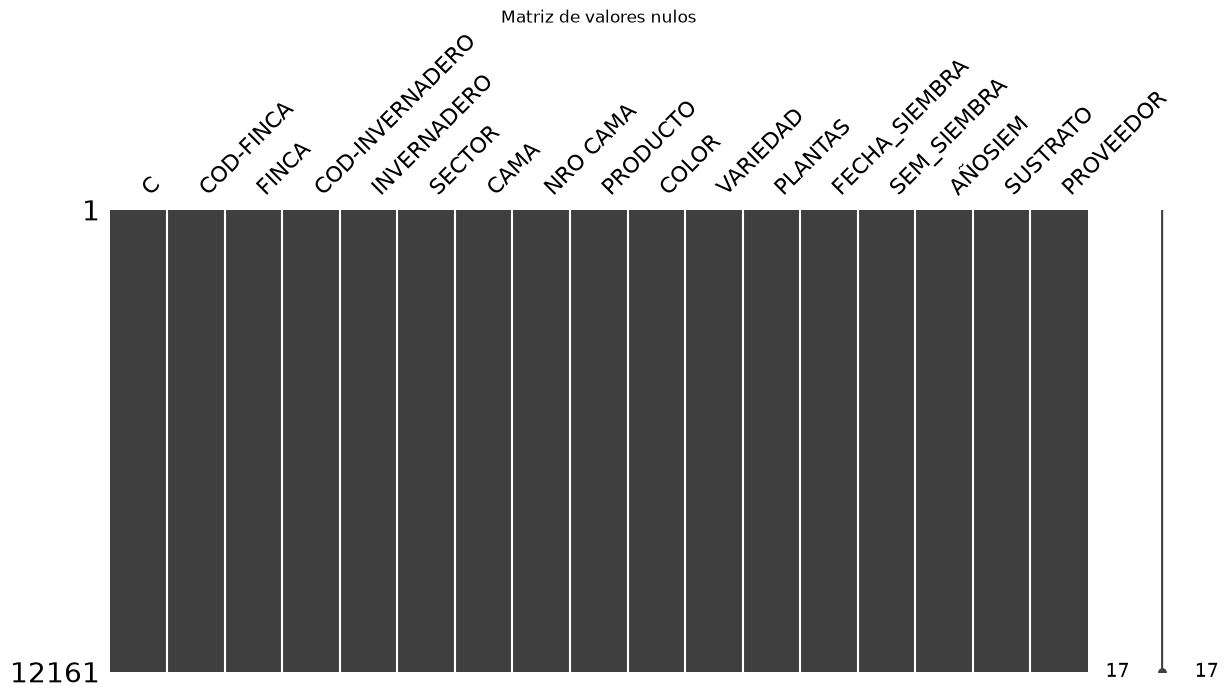

In [13]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df, figsize=(14, 6))
plt.title("Matriz de valores nulos")
plt.show()

In [14]:
df.head()

,C,COD-FINCA,FINCA,COD-INVERNADERO,INVERNADERO,SECTOR,CAMA,NRO CAMA,PRODUCTO,COLOR,VARIEDAD,PLANTAS,FECHA_SIEMBRA,SEM_SIEMBRA,AÑOSIEM,SUSTRATO,PROVEEDOR
0,G,01,Arabella,G01,Bloque 01,Lina Villanueva,80,80,Carnation,gold,Caroline Gold,1236,2025-02-26 00:00:00,9,2025,Sustrato 85%,SELECTA
1,G,01,Arabella,G01,Bloque 01,Lina Villanueva,90,90,Carnation,yellow,Diletta,816,2025-02-26 00:00:00,9,2025,Sustrato 85%,SELECTA
2,G,01,Arabella,G01,Bloque 01,Lina Villanueva,90,90,Carnation,peach,Novia,360,2025-02-26 00:00:00,9,2025,Sustrato 85%,DUMMEN O
3,G,01,Arabella,G01,Bloque 01,Lina Villanueva,94,94,Carnation,peach,Novia,696,2025-02-26 00:00:00,9,2025,Sustrato 85%,DUMMEN O
4,G,01,Arabella,G01,Bloque 01,Lina Villanueva,94,94,Carnation,light brown,Honey,534,2025-02-26 00:00:00,9,2025,Sustrato 85%,BREIER


In [15]:
df.tail()

,C,COD-FINCA,FINCA,COD-INVERNADERO,INVERNADERO,SECTOR,CAMA,NRO CAMA,PRODUCTO,COLOR,VARIEDAD,PLANTAS,FECHA_SIEMBRA,SEM_SIEMBRA,AÑOSIEM,SUSTRATO,PROVEEDOR
12156,,,,,,,,,,,,,,,,,
12157,,,,,,,,,,,,,,,,,
12158,,,,,,,,,,,,,,,,,
12159,,,,,,,,,,,,,,,,,
12160,,,,,,,,,,,,,,,,,


In [16]:
# NaN reales
print("NaN reales:", df.isna().sum().sum())

# Strings completamente vacíos
print("Strings vacíos:", (df == "").sum().sum())

# Strings que contienen solo espacios
print(
    "Solo espacios:",
    df.select_dtypes(include="object")
      .apply(lambda x: x.str.strip().eq("").sum())
      .sum()
)

NaN reales: 0
Strings vacíos: 2796
Solo espacios: 2796


In [17]:
import numpy as np

df = df.replace(r"^\s*$", np.nan, regex=True)

In [18]:
print("Total de nulos:", df.isna().sum().sum())

nulos = pd.DataFrame({
    "Nulos": df.isna().sum(),
    "Porcentaje": (df.isna().mean() * 100).round(2)
})

nulos[nulos["Nulos"] > 0].sort_values(
    "Nulos",
    ascending=False
)

Total de nulos: 2796


,Nulos,Porcentaje
PROVEEDOR,275,2.26
FECHA_SIEMBRA,185,1.52
COD-FINCA,185,1.52
INVERNADERO,185,1.52
FINCA,185,1.52
NRO CAMA,185,1.52
CAMA,185,1.52
PRODUCTO,185,1.52
SECTOR,185,1.52
AÑOSIEM,185,1.52


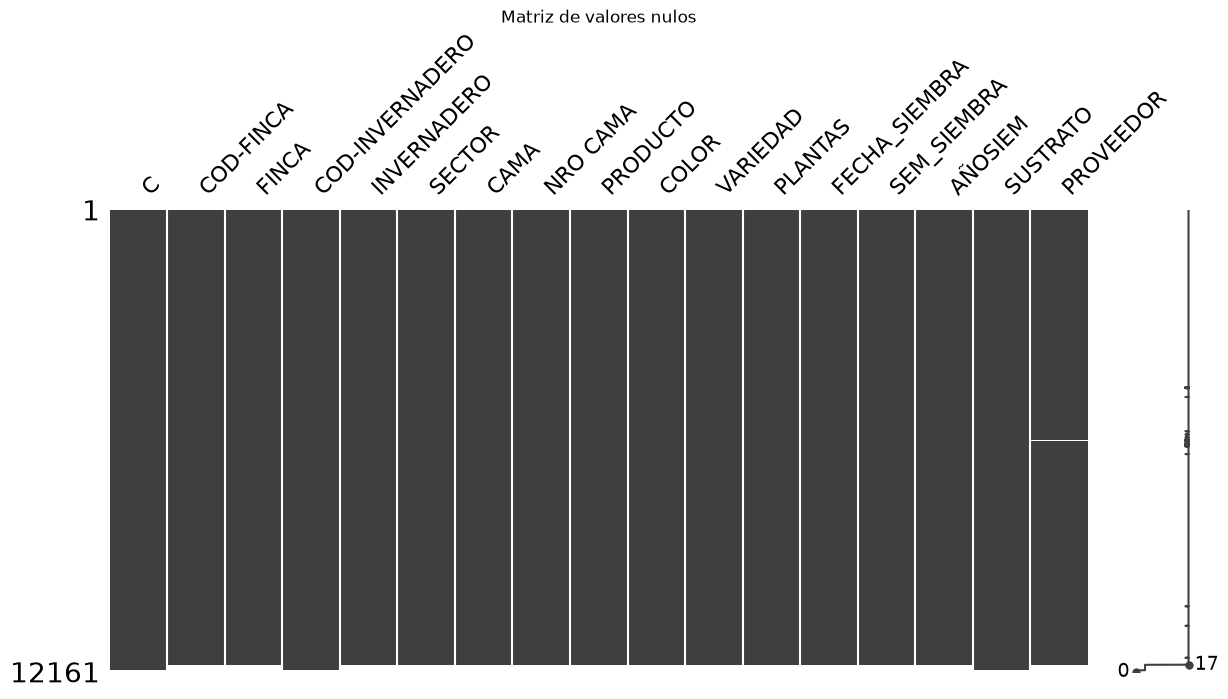

In [19]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df, figsize=(14, 6))
plt.title("Matriz de valores nulos")
plt.show()

In [20]:
# ============================================================
# ELIMINAR REGISTROS SIN INFORMACIÓN EN PLANTAS
# ============================================================

# 1. Estado antes de la limpieza
filas_antes = len(df)
nulos_antes = df["PLANTAS"].isna().sum()

print("ANTES DE LA LIMPIEZA")
print("-" * 40)
print(f"Filas totales:     {filas_antes:,}")
print(f"PLANTAS con dato:  {df['PLANTAS'].notna().sum():,}")
print(f"PLANTAS sin dato:  {nulos_antes:,}")
print(f"% sin dato:        {df['PLANTAS'].isna().mean() * 100:.2f}%")

# 2. Eliminar filas donde PLANTAS no tiene información
df = df.dropna(subset=["PLANTAS"]).reset_index(drop=True)

# 3. Estado después de la limpieza
filas_despues = len(df)
nulos_despues = df["PLANTAS"].isna().sum()

print("\nDESPUÉS DE LA LIMPIEZA")
print("-" * 40)
print(f"Filas totales:     {filas_despues:,}")
print(f"PLANTAS con dato:  {df['PLANTAS'].notna().sum():,}")
print(f"PLANTAS sin dato:  {nulos_despues:,}")
print(f"Filas eliminadas:  {filas_antes - filas_despues:,}")

# 4. Comprobaciones
assert nulos_despues == 0, "ERROR: todavía existen nulos en PLANTAS."
assert (filas_antes - filas_despues) == nulos_antes, \
    "ERROR: se eliminaron más filas de las esperadas."

print("\n✓ Limpieza correcta: solo se eliminaron registros sin PLANTAS.")

ANTES DE LA LIMPIEZA
----------------------------------------
Filas totales:     12,161
PLANTAS con dato:  11,976
PLANTAS sin dato:  185
% sin dato:        1.52%

DESPUÉS DE LA LIMPIEZA
----------------------------------------
Filas totales:     11,976
PLANTAS con dato:  11,976
PLANTAS sin dato:  0
Filas eliminadas:  185

✓ Limpieza correcta: solo se eliminaron registros sin PLANTAS.


In [21]:
df

,C,COD-FINCA,FINCA,COD-INVERNADERO,INVERNADERO,SECTOR,CAMA,NRO CAMA,PRODUCTO,COLOR,VARIEDAD,PLANTAS,FECHA_SIEMBRA,SEM_SIEMBRA,AÑOSIEM,SUSTRATO,PROVEEDOR
0,G,01,Arabella,G01,Bloque 01,Lina Villanueva,80,80,Carnation,gold,Caroline Gold,1236,2025-02-26 00:00:00,9,2025,Sustrato 85%,SELECTA
1,G,01,Arabella,G01,Bloque 01,Lina Villanueva,90,90,Carnation,yellow,Diletta,816,2025-02-26 00:00:00,9,2025,Sustrato 85%,SELECTA
2,G,01,Arabella,G01,Bloque 01,Lina Villanueva,90,90,Carnation,peach,Novia,360,2025-02-26 00:00:00,9,2025,Sustrato 85%,DUMMEN O
3,G,01,Arabella,G01,Bloque 01,Lina Villanueva,94,94,Carnation,peach,Novia,696,2025-02-26 00:00:00,9,2025,Sustrato 85%,DUMMEN O
4,G,01,Arabella,G01,Bloque 01,Lina Villanueva,94,94,Carnation,light brown,Honey,534,2025-02-26 00:00:00,9,2025,Sustrato 85%,BREIER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11971,G,33,GAITANA,G33,Bloque 33,Cristina Guzman,8,8,Raffine,bicolor burgundy,Petit Faye,800,2024-10-19 00:00:00,42,2024,Sustrato 85%,HILVERDA
11972,G,33,GAITANA,G33,Bloque 33,Cristina Guzman,9,9,Raffine,bicolor burgundy,Petit Faye,800,2024-10-19 00:00:00,42,2024,Sustrato 85%,HILVERDA
11973,G,33,GAITANA,G33,Bloque 33,Cristina Guzman,10,10,Raffine,bicolor burgundy,Petit Faye,800,2024-10-31 00:00:00,44,2024,Sustrato 85%,HILVERDA
11974,G,33,GAITANA,G33,Bloque 33,Cristina Guzman,11,11,Raffine,light pink,Thia,800,2024-10-31 00:00:00,44,2024,Sustrato 85%,HILVERDA


### 2.1. Aplicar la limpieza del plano 01 a todos los planos
Se usan exactamente las columnas de tu lista. Sólo se eliminan las filas con `PLANTAS` vacías; los valores no numéricos y negativos se conservan señalados. Se guardan las filas retiradas para que la pérdida de información de una semana no quede oculta en el EDA.
`df_planos_completo` incluye ambas ediciones de semana 32; `df_planos` elige la edición marcada actualizado. El año 2026 proviene de la carpeta y la semana del nombre. La referencia temporal usada aquí es el lunes ISO de esa semana, una **convención de análisis**, no la fecha de publicación ni la referencia AL1 de edad del Excel.


In [22]:
renombrar_planos = {'C':'c','COD-FINCA':'codigo_finca','FINCA':'finca',
    'COD-INVERNADERO':'codigo_invernadero','INVERNADERO':'invernadero','SECTOR':'sector',
    'CAMA':'cama','NRO CAMA':'numero_cama','PRODUCTO':'producto','COLOR':'color','VARIEDAD':'variedad',
    'PLANTAS':'plantas','FECHA_SIEMBRA':'fecha_siembra','SEM_SIEMBRA':'semana_siembra',
    'AÑOSIEM':'anio_siembra','SUSTRATO':'sustrato','PROVEEDOR':'proveedor'}
partes, retiradas, controles = [], [], []
for archivo, crudo in planos_crudos.items():
    assert set(columnas).issubset(crudo.columns), f'Faltan columnas en {archivo}'
    p=crudo[columnas+['fila_excel']].copy().replace(r'^\s*$', np.nan, regex=True)
    p['archivo']=archivo
    semana=int(re.search(r'Sem\s*(\d+)', archivo, re.I).group(1))
    p['semana_plano']=semana
    p['anio_plano']=2026
    p['fecha_plano']=pd.Timestamp(date.fromisocalendar(2026,semana,1))
    sin_plantas=p.PLANTAS.isna()
    retiradas.append(p.loc[sin_plantas].rename(columns=renombrar_planos))
    controles.append({'archivo':archivo,'filas_originales':len(p),'sin_plantas':int(sin_plantas.sum()),
                      'sin_plantas_con_finca':int((sin_plantas & p.FINCA.notna()).sum()),
                      'filas_conservadas':int((~sin_plantas).sum())})
    p=p.loc[~sin_plantas].rename(columns=renombrar_planos).copy()
    p['plantas_original']=p.plantas
    p['plantas']=pd.to_numeric(p.plantas,errors='coerce')
    for c in ['semana_siembra','anio_siembra']:
        p[c]=pd.to_numeric(p[c],errors='coerce')
    p['fecha_siembra_original']=p.fecha_siembra
    p['fecha_siembra']=fechas(p.fecha_siembra)
    for c in ['finca','invernadero','cama','codigo_finca','codigo_invernadero']:
        p[c]=normalizar(p[c]).str.replace(r'\.0$', '', regex=True)
    p['cantidad_invalida']=p.plantas.isna() | p.plantas.lt(0)
    lunes_siembra=p.fecha_siembra-pd.to_timedelta(p.fecha_siembra.dt.dayofweek,unit='D')
    p['edad_plano']=np.floor((p.fecha_plano-lunes_siembra).dt.days/7)
    partes.append(p)
df_planos_completo=homologar(pd.concat(partes,ignore_index=True))
planos_filas_retiradas=pd.concat(retiradas,ignore_index=True)
control_limpieza_planos=pd.DataFrame(controles)
seleccion=[]
for semana,g in df_planos_completo[['semana_plano','archivo']].drop_duplicates().groupby('semana_plano'):
    elegible=g if len(g)==1 else g.loc[g.archivo.str.contains('actualizado',case=False)]
    assert len(elegible)==1, f'Revisar versiones de semana {semana}'
    seleccion.append({'semana_plano':semana,'archivo':elegible.archivo.iloc[0],
                      'criterio':'archivo único' if len(g)==1 else 'marcado actualizado'})
seleccion_planos=pd.DataFrame(seleccion)
df_planos=df_planos_completo.loc[df_planos_completo.archivo.isin(seleccion_planos.archivo)].copy()
llave_plano=['archivo','finca','invernadero','cama','variedad','fecha_siembra']
df_planos['llave_repetida']=df_planos.duplicated(llave_plano,keep=False)
# Pueden ser segmentos válidos: se reportan sin borrarlos ni certificar que se puedan sumar.
revision_planos=df_planos.loc[df_planos.cantidad_invalida | df_planos.fecha_siembra.isna() |
    df_planos.edad_plano.lt(0) | df_planos.llave_repetida | df_planos.estado_maestro.ne('unico')].copy()
display(control_limpieza_planos)
display(seleccion_planos)
display(df_planos.head())


,archivo,filas_originales,sin_plantas,sin_plantas_con_finca,filas_conservadas
0,Plano de Siembras Sem 01.xlsx,12161,185,0,11976
1,Plano de Siembras Sem 02.xlsx,12161,249,0,11912
2,Plano de Siembras Sem 03.xlsx,12161,219,0,11942
3,Plano de Siembras Sem 04.xlsx,12161,239,0,11922
4,Plano de Siembras Sem 05.xlsx,12161,319,80,11842
...,...,...,...,...,...
29,Plano de Siembras Sem 30.xlsx,12161,479,0,11682
30,Plano de Siembras Sem 31.xlsx,12161,404,0,11757
31,Plano de Siembras Sem 32 actualizado.xlsx,12157,365,0,11792
32,Plano de Siembras Sem 32.xlsx,12161,404,0,11757


,semana_plano,archivo,criterio
0,1,Plano de Siembras Sem 01.xlsx,archivo único
1,2,Plano de Siembras Sem 02.xlsx,archivo único
2,3,Plano de Siembras Sem 03.xlsx,archivo único
3,4,Plano de Siembras Sem 04.xlsx,archivo único
4,5,Plano de Siembras Sem 05.xlsx,archivo único
...,...,...,...
28,29,Plano de Siembras Sem 29.xlsx,archivo único
29,30,Plano de Siembras Sem 30.xlsx,archivo único
30,31,Plano de Siembras Sem 31.xlsx,archivo único
31,32,Plano de Siembras Sem 32 actualizado.xlsx,marcado actualizado


,c,codigo_finca,finca,codigo_invernadero,invernadero,sector,cama,numero_cama,producto,color,variedad,plantas,fecha_siembra,semana_siembra,anio_siembra,sustrato,proveedor,fila_excel,archivo,semana_plano,anio_plano,fecha_plano,plantas_original,fecha_siembra_original,cantidad_invalida,edad_plano,producto_original,color_original,variedad_original,IdVariedad,IdProducto,IdColor,estado_maestro,conflicto_color,llave_repetida
0,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,80,80,Carnation,gold,Caroline Gold,1236,2025-02-26,9,2025,Sustrato 85%,SELECTA,3,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,1236,2025-02-26 00:00:00,False,44.0,Carnation,gold,Caroline Gold,256.0,71,21,unico,False,False
1,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,90,90,Carnation,yellow,Diletta,816,2025-02-26,9,2025,Sustrato 85%,SELECTA,4,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,816,2025-02-26 00:00:00,False,44.0,Carnation,yellow,Diletta,551.0,71,39,unico,False,False
2,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,90,90,Carnation,peach,Novia,360,2025-02-26,9,2025,Sustrato 85%,DUMMEN O,5,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,360,2025-02-26 00:00:00,False,44.0,Carnation,peach,Novia,435.0,71,33,unico,False,False
3,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,94,94,Carnation,peach,Novia,696,2025-02-26,9,2025,Sustrato 85%,DUMMEN O,6,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,696,2025-02-26 00:00:00,False,44.0,Carnation,peach,Novia,435.0,71,33,unico,False,False
4,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,94,94,Carnation,light brown,HONEY,534,2025-02-26,9,2025,Sustrato 85%,BREIER,7,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,534,2025-02-26 00:00:00,False,44.0,Carnation,light brown,Honey,NaN,71,52,ambiguo,False,False


## 3. Importar estadísticas y camas piloto de todos los productos

`estadisticas_crudas` conserva las cuatro bases de detalle sin homogeneizar sus columnas. El libro mixto conserva **todos** sus productos. `camas_piloto_crudas` mantiene el detalle de plantas separado, sin realizar joins.

En `Camas Piloto`, Clavel y Green Ball tienen encabezados en fila 1; Miniclavel y Raffine/Solomio/Otros, en fila 2. Esta diferencia se comprobó en los originales.

In [23]:
estadisticas_crudas = {}
camas_piloto_crudas = {}

for archivo in archivos_estadisticas:
    with pd.ExcelFile(archivo, engine="calamine") as libro:
        # Sólo reconocer el nombre de la hoja; no normalizar las columnas ni los datos.
        # Estas son las hojas de detalle verificadas, no los resúmenes del libro.
        hojas_base = [h for h in libro.sheet_names if h.strip().lower() in ("base de datos", "corte semanal")]
        assert len(hojas_base) == 1, f"Revisar hoja cruda en {archivo.name}: {hojas_base}"
        hoja = hojas_base[0]
        df = pd.read_excel(libro, sheet_name=hoja, header=0, dtype=object, keep_default_na=False)
        df["fila_excel"] = range(2, len(df) + 2)
        estadisticas_crudas[archivo.name] = df
        print("Estadísticas cargadas:", archivo.name, flush=True)
        inventario.append({
            "archivo": archivo.name, "hoja_cargada": hoja,
            "filas": len(df), "columnas_fuente": len(df.columns) - 1,
            "hojas_del_libro": libro.sheet_names,
        })

        # Camas Piloto se mantiene aparte: todavía NO unir por variedad ni referencia.
        # En estos dos libros hay una fila de números por encima del encabezado.
        header_pilotos = 1 if ("Miniclavel" in archivo.name or "Raffine" in archivo.name) else 0
        pilotos = pd.read_excel(libro, sheet_name="Camas Piloto", header=header_pilotos,
                                dtype=object, keep_default_na=False)
        pilotos["fila_excel"] = range(header_pilotos + 2, len(pilotos) + header_pilotos + 2)
        camas_piloto_crudas[archivo.name] = pilotos
        inventario.append({
            "archivo": archivo.name, "hoja_cargada": "Camas Piloto",
            "filas": len(pilotos), "columnas_fuente": len(pilotos.columns) - 1,
            "hojas_del_libro": libro.sheet_names,
        })

print("Libros de estadísticas importados:", len(estadisticas_crudas))
display(pd.DataFrame(inventario)[["archivo", "hoja_cargada", "filas", "columnas_fuente"]])

Estadísticas cargadas: Estadisticas Clavel 2026.xlsx


Estadísticas cargadas: Estadisticas Green Ball 2026.xlsx


Estadísticas cargadas: Estadisticas Miniclavel 2026.xlsx


Estadísticas cargadas: Estadisticas Raffine_Solomio_Otros 2026.xlsx


Libros de estadísticas importados: 4


,archivo,hoja_cargada,filas,columnas_fuente
0,Plano de Siembras Sem 01.xlsx,Datos,12161,86
1,Plano de Siembras Sem 02.xlsx,Datos,12161,86
2,Plano de Siembras Sem 03.xlsx,Datos,12161,86
3,Plano de Siembras Sem 04.xlsx,Datos,12161,86
4,Plano de Siembras Sem 05.xlsx,Datos,12161,86
...,...,...,...,...
37,Estadisticas Green Ball 2026.xlsx,Camas Piloto,956,14
38,Estadisticas Miniclavel 2026.xlsx,Base de datos,244451,34
39,Estadisticas Miniclavel 2026.xlsx,Camas Piloto,20232,19
40,Estadisticas Raffine_Solomio_Otros 2026.xlsx,corte semanal,109195,20


In [24]:
camas_piloto_crudas.keys()

dict_keys(['Estadisticas Clavel 2026.xlsx', 'Estadisticas Green Ball 2026.xlsx', 'Estadisticas Miniclavel 2026.xlsx', 'Estadisticas Raffine_Solomio_Otros 2026.xlsx'])

In [25]:
estadisticas_crudas.keys()

dict_keys(['Estadisticas Clavel 2026.xlsx', 'Estadisticas Green Ball 2026.xlsx', 'Estadisticas Miniclavel 2026.xlsx', 'Estadisticas Raffine_Solomio_Otros 2026.xlsx'])

In [26]:
df_mini_camas = camas_piloto_crudas['Estadisticas Miniclavel 2026.xlsx']

In [27]:
df_mini_estadisticas = estadisticas_crudas['Estadisticas Miniclavel 2026.xlsx']

In [28]:
# Tu selección, sin repetir Sem Siembra; se conserva Casa para el enriquecimiento.
columnas_camas = ["Referencia", "Color", "Variedad", "No. Bloque", "No. Cama",
    "Fecha de Siembra", "No. Plantas", "Sem Siembra", "Año Siembra", "#Sem", "Sustrato", "Casa"]


In [29]:
df_camas = df_mini_camas[columnas_camas]

In [30]:
# Conservar variedad y ciclo: hacen falta para verificar la unión.
columnas_estadisticas = ["CAMA PILOTO", "SEM Corte", "Año Corte", "Semana Corte", "CORTE SEMANAL",
    "Color", "Variedad", "Fecha de Siembra", "Semana de Siembra", "Año de Siembra", "Edad", "Sustrato", "CASA"]


In [31]:
df_estadisticas = df_mini_estadisticas[columnas_estadisticas]

In [32]:
df_camas

,Referencia,Color,Variedad,No. Bloque,No. Cama,Fecha de Siembra,No. Plantas,Sem Siembra,Año Siembra,#Sem,Sustrato,Casa
0,Dracula-15-185,Rojo,Dracula,15,185,,,1,1900,,,
1,Lorenzo-12-19,Cereza,Lorenzo,12,19,,,1,1900,,S90%,
2,Roxanne-1-318,Rosado,Roxanne,1,318,,,1,1900,,S90%,
3,Malibu-18-197,Lila,Malibu,18,197,,,1,1900,,S90%,
4,Number One-4-56,Bicolor Rojo,Number One,4,56,,,1,1900,,S90%,
...,...,...,...,...,...,...,...,...,...,...,...,...
20227,,,,,,,,52,1900,,S90%,
20228,,,,,,,,52,1900,,S90%,
20229,,,,,,,,52,1900,,S90%,
20230,,,,,,,,52,1900,,S90%,


In [33]:
df_estadisticas 

,CAMA PILOTO,SEM Corte,Año Corte,Semana Corte,CORTE SEMANAL,Color,Variedad,Fecha de Siembra,Semana de Siembra,Año de Siembra,Edad,Sustrato,CASA
0,PIGEON-1-6,1,2014,201401,23,Cereza,PIGEON,2013-07-04 00:00:00,27,2013,27,S90%,Breier
1,PIGEON-1-8,1,2014,201401,138,Cereza,PIGEON,2013-07-04 00:00:00,27,2013,27,S90%,Breier
2,BAGATEL-1-13,1,2014,201401,117,Blanco,BAGATEL,2012-05-09 00:00:00,20,2012,86,S90%,Selecta
3,BAGATEL-1-39,1,2014,201401,115,Blanco,BAGATEL,2012-06-29 00:00:00,27,2012,79,S90%,Selecta
4,BAGATEL-1-65,1,2014,201401,155,Blanco,BAGATEL,2012-09-13 00:00:00,38,2012,68,S90%,Selecta
...,...,...,...,...,...,...,...,...,...,...,...,...,...
244446,valentine-18-54,28,2026,202628,0,bicolor rosado,valentine,2026-02-23 00:00:00,9,2026,19,S90%,Breier
244447,Valentine-18-243,26,2026,202626,135,bicolor rosado,valentine,2026-02-02 00:00:00,6,2026,20,S90%,Breier
244448,Valentine-18-243,27,2026,202627,365,bicolor rosado,valentine,2026-02-02 00:00:00,6,2026,21,S90%,Breier
244449,Whisper-18-170,26,2026,202626,92,Blanco,whisper,2026-02-09 00:00:00,7,2026,19,S90%,Dummen Orange


In [34]:
import numpy as np
import pandas as pd

# ============================================================
# NORMALIZAR VALORES VACÍOS COMO NaN
# ============================================================

# Ver cuántos NaN reconoce actualmente Pandas
print("ANTES DE NORMALIZAR")
print("-" * 50)
print(f"NaN reales en df_camas:        {df_camas.isna().sum().sum():,}")
print(f"NaN reales en df_estadisticas: {df_estadisticas.isna().sum().sum():,}")


# ------------------------------------------------------------
# Convertir vacíos y representaciones comunes de nulos a NaN
# ------------------------------------------------------------

valores_nulos = [
    "",
    "NULL",
    "null",
    "None",
    "NONE",
    "N/A",
    "n/a",
    "NA",
    "na"
]

df_camas = df_camas.replace(valores_nulos, np.nan)
df_estadisticas = df_estadisticas.replace(valores_nulos, np.nan)


# Convertir también strings que contienen SOLO espacios
# Ejemplos: " ", "   ", etc.
df_camas = df_camas.replace(r"^\s*$", np.nan, regex=True)
df_estadisticas = df_estadisticas.replace(r"^\s*$", np.nan, regex=True)


# ------------------------------------------------------------
# Comprobación
# ------------------------------------------------------------

print("\nDESPUÉS DE NORMALIZAR")
print("-" * 50)
print(f"NaN en df_camas:        {df_camas.isna().sum().sum():,}")
print(f"NaN en df_estadisticas: {df_estadisticas.isna().sum().sum():,}")

ANTES DE NORMALIZAR
--------------------------------------------------
NaN reales en df_camas:        0


NaN reales en df_estadisticas: 0



DESPUÉS DE NORMALIZAR
--------------------------------------------------
NaN en df_camas:        21,259
NaN en df_estadisticas: 45,658


DF_CAMAS
--------------------------------------------------
Filas: 20,232
Columnas: 12


Total nulos: 21,259


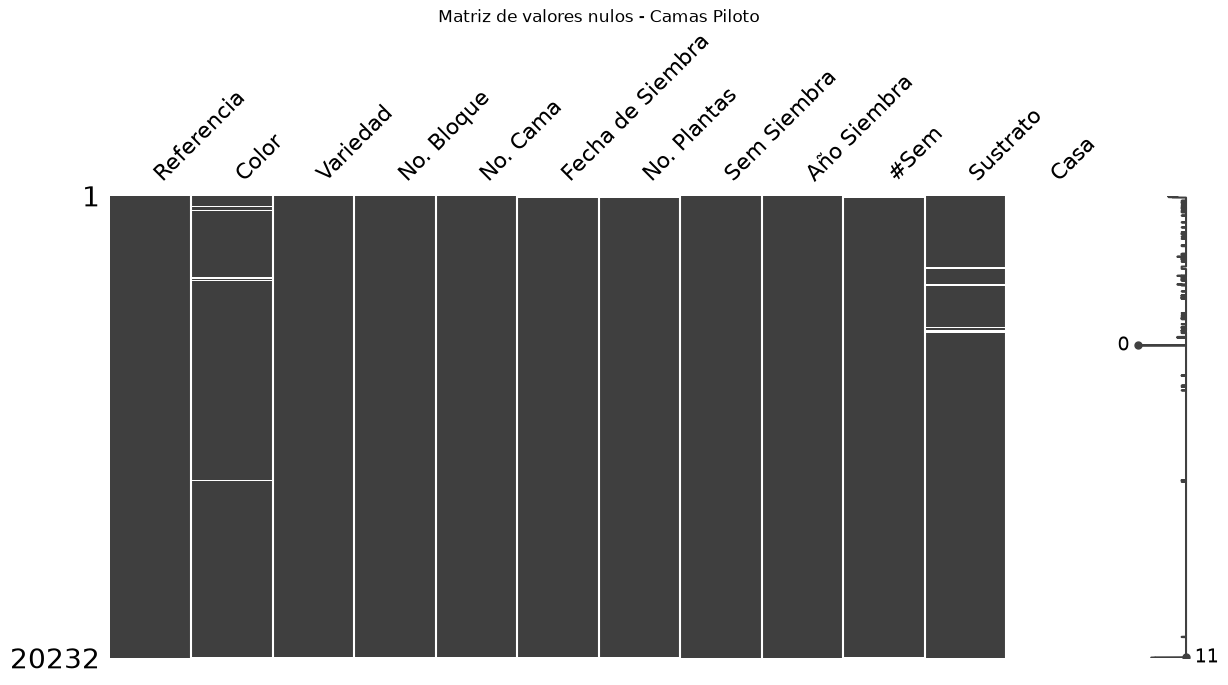

DF_ESTADISTICAS
--------------------------------------------------
Filas: 244,451
Columnas: 13
Total nulos: 45,658


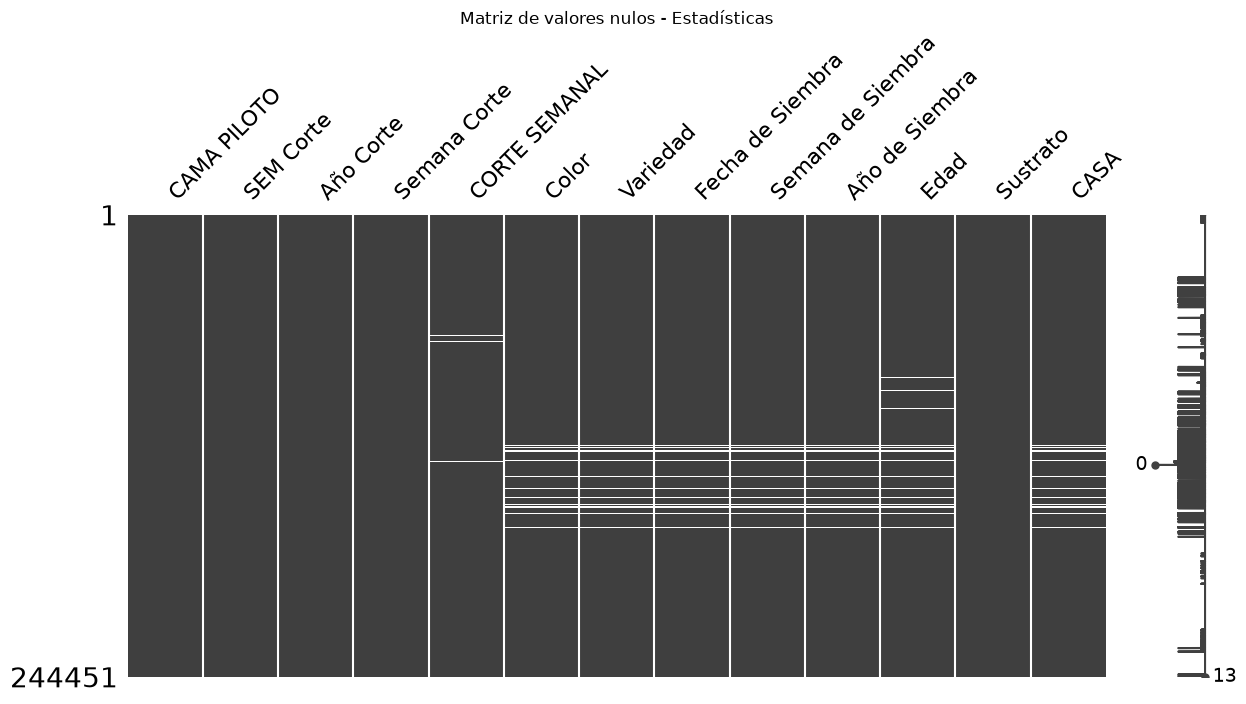

In [35]:
import missingno as msno
import matplotlib.pyplot as plt


# ============================================================
# 1. NULOS - DF_CAMAS
# ============================================================

print("DF_CAMAS")
print("-" * 50)
print(f"Filas: {len(df_camas):,}")
print(f"Columnas: {df_camas.shape[1]}")
print(f"Total nulos: {df_camas.isna().sum().sum():,}")

msno.matrix(df_camas, figsize=(14, 6))
plt.title("Matriz de valores nulos - Camas Piloto")
plt.show()


# ============================================================
# 2. NULOS - DF_ESTADISTICAS
# ============================================================

print("DF_ESTADISTICAS")
print("-" * 50)
print(f"Filas: {len(df_estadisticas):,}")
print(f"Columnas: {df_estadisticas.shape[1]}")
print(f"Total nulos: {df_estadisticas.isna().sum().sum():,}")

msno.matrix(df_estadisticas, figsize=(14, 6))
plt.title("Matriz de valores nulos - Estadísticas")
plt.show()

In [36]:
# ============================================================
# NULOS POR COLUMNA - CAMAS
# ============================================================

nulos_camas = pd.DataFrame({
    "Nulos": df_camas.isna().sum(),
    "Porcentaje": (df_camas.isna().mean() * 100).round(2)
})

display(
    nulos_camas
    .sort_values("Nulos", ascending=False)
)

,Nulos,Porcentaje
Casa,20232,100.00
Sustrato,335,1.66
Color,288,1.42
#Sem,124,0.61
No. Plantas,99,0.49
Fecha de Siembra,99,0.49
No. Cama,26,0.13
Variedad,19,0.09
No. Bloque,19,0.09
Referencia,16,0.08


In [37]:
# ============================================================
# NULOS POR COLUMNA - ESTADÍSTICAS
# ============================================================

nulos_estadisticas = pd.DataFrame({
    "Nulos": df_estadisticas.isna().sum(),
    "Porcentaje": (df_estadisticas.isna().mean() * 100).round(2)
})

display(
    nulos_estadisticas
    .sort_values("Nulos", ascending=False)
)

,Nulos,Porcentaje
Edad,8157,3.34
CASA,6321,2.59
Color,6181,2.53
Variedad,6177,2.53
Semana de Siembra,6177,2.53
Año de Siembra,6177,2.53
Fecha de Siembra,6177,2.53
CORTE SEMANAL,286,0.12
CAMA PILOTO,1,0.00
Semana Corte,1,0.00


### 3.1. Homogeneizar los cuatro libros después de la limpieza de vacíos
Se aplica la misma normalización de vacíos a todos los productos. Para Miniclavel se parte de `df_camas` y `df_estadisticas`, es decir, de las tablas que acabas de limpiar arriba; para los demás se aplican las mismas reglas a sus fuentes. Se retiran únicamente filas de plantilla sin referencia, variedad ni corte/plantas, y se cuentan. Un registro identificado se conserva aunque le falten plantas o fechas.
El libro mixto conserva sus productos; en sus camas piloto el producto se obtiene de una variedad inequívoca en el maestro. No se asigna todo el libro a Raffine. Se preservan los campos originales de año/semana, incluso cuando discrepan de la fecha.


In [38]:
def producto_libro(archivo):
    if 'Miniclavel' in archivo: return 'MINICARNATION'
    if 'Clavel' in archivo: return 'CARNATION'
    if 'Green Ball' in archivo: return 'GREEN BALL'
    return pd.NA

def preparar_pilotos(d, archivo):
    d=vacios(d)
    return pd.DataFrame({'archivo':archivo,'fila_excel':d.fila_excel,
        'referencia':campo(d,'Referencia'),'producto':producto_libro(archivo),
        'color':campo(d,'Color'),'variedad':campo(d,'Variedad'),
        'bloque':campo(d,'No. Bloque'),'cama':campo(d,'No. Cama'),
        'fecha_siembra':fechas(campo(d,'Fecha de Siembra')),
        'semana_siembra':pd.to_numeric(campo(d,'Sem Siembra'),errors='coerce'),
        'anio_siembra':pd.to_numeric(campo(d,'Año Siembra'),errors='coerce'),
        'plantas':pd.to_numeric(campo(d,'No. Plantas'),errors='coerce'),
        'plantas_original':campo(d,'No. Plantas'),
        'sustrato':campo(d,'Sustrato','Tipo de sustrato'),'casa_breeder':campo(d,'Casa','Breeder')})

def preparar_estadisticas(d, archivo):
    d=vacios(d)
    producto=campo(d,'PRODUCTO').fillna(producto_libro(archivo)) if not pd.isna(producto_libro(archivo)) else campo(d,'PRODUCTO')
    return pd.DataFrame({'archivo':archivo,'fila_excel':d.fila_excel,
        'referencia':campo(d,'CAMA PILOTO','CODIGO'),'producto':producto,
        'color':campo(d,'Color'),'variedad':campo(d,'Variedad'),
        'anio_corte':pd.to_numeric(campo(d,'Año Corte'),errors='coerce'),
        'semana_corte':pd.to_numeric(campo(d,'SEM Corte','Semana'),errors='coerce'),
        'corte':pd.to_numeric(campo(d,'CORTE SEMANAL'),errors='coerce'),
        'corte_original':campo(d,'CORTE SEMANAL'),
        'edad_original':pd.to_numeric(campo(d,'Edad'),errors='coerce'),
        'fecha_siembra':fechas(campo(d,'Fecha de Siembra')),
        'semana_siembra':pd.to_numeric(campo(d,'Semana de Siembra','SEMANA SIEMBRA'),errors='coerce'),
        'anio_siembra':pd.to_numeric(campo(d,'Año de Siembra','AÑO SIEMBRA'),errors='coerce'),
        'sustrato':campo(d,'Sustrato'),'casa_breeder':campo(d,'CASA','Breeder')})

pilotos, estadisticas, estructura=[] , [], []
for archivo in estadisticas_crudas:
    if 'Miniclavel' in archivo:
        # Alinear fila_excel por índice preserva la trazabilidad de tu limpieza manual.
        cp=df_camas.assign(fila_excel=camas_piloto_crudas[archivo].fila_excel)
        es=df_estadisticas.assign(fila_excel=estadisticas_crudas[archivo].fila_excel)
    else:
        cp=camas_piloto_crudas[archivo]
        es=estadisticas_crudas[archivo]
    for familia,d,lista in [('pilotos',preparar_pilotos(cp,archivo),pilotos),
                            ('estadisticas',preparar_estadisticas(es,archivo),estadisticas)]:
        cantidad='plantas_original' if familia=='pilotos' else 'corte_original'
        plantilla=d[['referencia','variedad',cantidad]].isna().all(axis=1)
        estructura.append({'archivo':archivo,'familia':familia,'filas':len(d),'plantilla':int(plantilla.sum())})
        lista.append(d.loc[~plantilla].copy())
df_camas_piloto=homologar(pd.concat(pilotos,ignore_index=True))
df_estadisticas_base=homologar(pd.concat(estadisticas,ignore_index=True))
for d in [df_camas_piloto,df_estadisticas_base]:
    d['variedad_llave']=normalizar(d.variedad)
    # Se conserva la referencia completa: no unir sólo por número de cama.
    d['referencia_llave']=normalizar(d.referencia).str.replace(r'\s*-\s*','-',regex=True)
    d['semana_siembra']=d.semana_siembra.where(d.semana_siembra.lt(100),d.semana_siembra.mod(100))
    d['fecha_semana_siembra']=lunes_iso(d.anio_siembra,d.semana_siembra)
df_camas_piloto['id_piloto']=np.arange(len(df_camas_piloto))
df_estadisticas_base['id_estadistica']=np.arange(len(df_estadisticas_base))
df_estadisticas_base['fecha_corte']=lunes_iso(df_estadisticas_base.anio_corte,df_estadisticas_base.semana_corte)
display(pd.DataFrame(estructura))


,archivo,familia,filas,plantilla
0,Estadisticas Clavel 2026.xlsx,pilotos,7513,17
1,Estadisticas Clavel 2026.xlsx,estadisticas,170141,1
2,Estadisticas Green Ball 2026.xlsx,pilotos,956,1
3,Estadisticas Green Ball 2026.xlsx,estadisticas,6465,0
4,Estadisticas Miniclavel 2026.xlsx,pilotos,20232,11
5,Estadisticas Miniclavel 2026.xlsx,estadisticas,244451,1
6,Estadisticas Raffine_Solomio_Otros 2026.xlsx,pilotos,4033,486
7,Estadisticas Raffine_Solomio_Otros 2026.xlsx,estadisticas,109195,0


### 3.2. Unión sin multiplicar cortes ni mezclar ciclos
Llave inicial: **archivo + variedad homologada + referencia completa de cama piloto**. Se usa además la fecha de siembra cuando la estadística la tiene; en su ausencia, año/semana de siembra. Si ambos faltan, sólo se permite una única candidata y que la siembra no sea posterior a la semana de corte. No se escoge arbitrariamente el primer registro.
Una fecha conocida que no coincida queda como conflicto de ciclo; no se relaja la llave para forzar la unión. Se conservan también duplicados de pilotos: si impiden identificar una única fila, el caso es ambiguo. Los campos de camas tienen prioridad cuando existe una unión única; las diferencias con estadísticas quedan señaladas. Edad = semanas completas entre el lunes de la semana de siembra y el lunes de corte (edad 0 en la semana de siembra). Flores por planta = corte / plantas, sólo con plantas positivas.


**Calendario:** se interpreta año/semana como ISO. Las diferencias con `edad_original` se muestran en el EDA; hay que confirmar esta convención con el calendario operativo antes de usar la proyección en producción. Las semanas ISO imposibles quedan sin fecha y se reportan, sin desplazarlas automáticamente.


In [39]:
llaves=['archivo','variedad_llave','referencia_llave']
e=df_estadisticas_base
p=df_camas_piloto
completa=e[llaves].notna().all(axis=1)
pderecha=p.loc[p[llaves].notna().all(axis=1)]
campos_ciclo=['fecha_siembra','anio_siembra','semana_siembra']
candidatas=e.loc[completa,['id_estadistica','fecha_corte']+llaves+campos_ciclo].merge(
    pderecha[llaves+campos_ciclo+['id_piloto']],on=llaves,how='inner',suffixes=('_est','_pil'))
cantidad_inicial=candidatas.groupby('id_estadistica').size()
tiene_fecha=candidatas.fecha_siembra_est.notna()
tiene_semana=(candidatas.anio_siembra_est.between(1980,2100) & candidatas.semana_siembra_est.between(1,53))
compatible_fecha=candidatas.fecha_siembra_est.eq(candidatas.fecha_siembra_pil)
compatible_semana=(candidatas.anio_siembra_est.eq(candidatas.anio_siembra_pil) &
                    candidatas.semana_siembra_est.eq(candidatas.semana_siembra_pil))
# No aceptar una siembra posterior a la semana del corte; permite días dentro de esa semana.
temporal=candidatas.fecha_siembra_pil.isna() | candidatas.fecha_corte.isna() | (
    candidatas.fecha_siembra_pil.le(candidatas.fecha_corte+pd.Timedelta(days=6)))
compatible=np.where(tiene_fecha,compatible_fecha,np.where(tiene_semana,compatible_semana,True)) & temporal
candidatas_validas=candidatas.loc[compatible].copy()
n=candidatas_validas.groupby('id_estadistica').size()
unicas=candidatas_validas.loc[candidatas_validas.id_estadistica.map(n).eq(1),['id_estadistica','id_piloto']]
resultado=e.merge(unicas,on='id_estadistica',how='left',validate='one_to_one')
resultado['candidatas_iniciales']=resultado.id_estadistica.map(cantidad_inicial).fillna(0).astype(int)
resultado['candidatas_compatibles']=resultado.id_estadistica.map(n).fillna(0).astype(int)
resultado['estado_union']=np.select([
    ~completa.to_numpy(),resultado.candidatas_iniciales.eq(0),resultado.candidatas_compatibles.eq(0),
    resultado.candidatas_compatibles.gt(1)],
    ['llave_incompleta','sin_pareja','conflicto_ciclo','ambigua'],default='unica')
atributos=['id_piloto','fila_excel','plantas','fecha_siembra','anio_siembra','semana_siembra','sustrato','casa_breeder']
resultado=resultado.merge(p[atributos],on='id_piloto',how='left',suffixes=('_est','_pil'),validate='many_to_one')
for c in ['fecha_siembra','anio_siembra','semana_siembra','sustrato','casa_breeder']:
    resultado['conflicto_'+c]=(resultado[c+'_est'].notna() & resultado[c+'_pil'].notna() &
                              normalizar(resultado[c+'_est']).ne(normalizar(resultado[c+'_pil'])).fillna(False))
    resultado[c]=resultado[c+'_pil'].combine_first(resultado[c+'_est'])
    resultado['origen_'+c]=np.select([resultado[c+'_pil'].notna(),resultado[c+'_est'].notna()],['piloto','estadistica'],default='faltante')
resultado['fecha_semana_siembra']=resultado.fecha_siembra-pd.to_timedelta(resultado.fecha_siembra.dt.dayofweek,unit='D')
resultado['fecha_semana_siembra']=resultado.fecha_semana_siembra.fillna(lunes_iso(resultado.anio_siembra,resultado.semana_siembra))
resultado['edad']=((resultado.fecha_corte-resultado.fecha_semana_siembra).dt.days//7).astype('Int64')
resultado['flores_x_planta']=resultado.corte.div(resultado.plantas.where(resultado.plantas.gt(0)))
resultado['diferencia_edad']=resultado.edad-resultado.edad_original
llave_corte=['archivo','referencia_llave','variedad_llave','fecha_semana_siembra','fecha_corte']
resultado['corte_repetido']=resultado.duplicated(llave_corte,keep=False)
df_estadisticas_completo=resultado
assert len(resultado)==len(e) and resultado.id_estadistica.is_unique
reporte_uniones=resultado.groupby(['archivo','estado_union']).agg(filas=('id_estadistica','size'),
    corte_reportado=('corte',lambda s:s.sum(min_count=1))).reset_index()
reporte_uniones['porcentaje_filas']=100*reporte_uniones.filas/reporte_uniones.groupby('archivo').filas.transform('sum')
uniones_pendientes=resultado.loc[resultado.estado_union.ne('unica')].copy()
pilotos_llave_repetida=p.loc[p.duplicated(llaves,keep=False)].sort_values(llaves)
display(reporte_uniones.round(2))
display(uniones_pendientes[['archivo','fila_excel_est','referencia','variedad','estado_union','candidatas_iniciales']].head(20))
print('No se eliminan uniones fallidas: revisar uniones_pendientes antes de decidir descartes.')


,archivo,estado_union,filas,corte_reportado,porcentaje_filas
0,Estadisticas Clavel 2026.xlsx,ambigua,14956,3176011.60,8.79
1,Estadisticas Clavel 2026.xlsx,conflicto_ciclo,530,123006.00,0.31
2,Estadisticas Clavel 2026.xlsx,llave_incompleta,3635,636425.00,2.14
3,Estadisticas Clavel 2026.xlsx,sin_pareja,227,80936.00,0.13
4,Estadisticas Clavel 2026.xlsx,unica,150792,30963475.84,88.63
5,Estadisticas Green Ball 2026.xlsx,ambigua,213,56615.00,3.29
6,Estadisticas Green Ball 2026.xlsx,conflicto_ciclo,377,135222.00,5.83
7,Estadisticas Green Ball 2026.xlsx,llave_incompleta,260,78690.00,4.02
8,Estadisticas Green Ball 2026.xlsx,sin_pareja,6,2740.00,0.09
9,Estadisticas Green Ball 2026.xlsx,unica,5609,1653355.00,86.76


,archivo,fila_excel_est,referencia,variedad,estado_union,candidatas_iniciales
4,Estadisticas Clavel 2026.xlsx,6,LED-9-100,LED,ambigua,2
6,Estadisticas Clavel 2026.xlsx,8,LION KING-9-157,Lion King,ambigua,2
8,Estadisticas Clavel 2026.xlsx,10,BARCELONA-9-188,BARCELONA,ambigua,2
31,Estadisticas Clavel 2026.xlsx,33,ISOLA-13-71,Isola,ambigua,2
39,Estadisticas Clavel 2026.xlsx,41,CHEERIO-13-201,Cheerio,ambigua,2
40,Estadisticas Clavel 2026.xlsx,42,YELLOW VIANA-13-211,Yellow Viana,ambigua,2
42,Estadisticas Clavel 2026.xlsx,44,DARK TEMPEST-13-223,Dark Tempest,ambigua,2
48,Estadisticas Clavel 2026.xlsx,50,PIET-14-40,Piet,ambigua,2
49,Estadisticas Clavel 2026.xlsx,51,PIET-14-52,Piet,ambigua,2
55,Estadisticas Clavel 2026.xlsx,57,CREOLA-14-218,Creola,ambigua,2


No se eliminan uniones fallidas: revisar uniones_pendientes antes de decidir descartes.


## 4. EDA de las nuevas bases
### 4.1. Cobertura y calidad antes de interpretar
Se muestran nombres sin resolver, conflictos de color, fechas, duplicados y cobertura de unión. El porcentaje de uniones fallidas se calcula por libro y también por año: un porcentaje global pequeño puede ocultar faltantes recientes.
`df_estadisticas_completo` conserva todos los registros. Para el EDA de rendimientos y las curvas se usa una vista con unión única, variedad identificada, edad no negativa, plantas positivas, corte no negativo y sin repeticiones cama/ciclo/semana. No se eliminan atípicos por su magnitud; se muestran los mayores rendimientos para revisar. **Los cortes cero se conservan; una semana ausente no se inventa como cero.**


In [40]:
columnas_revision=['archivo','fila_excel','producto_original','color_original','variedad_original',
    'producto','color','variedad','estado_maestro','conflicto_color']
revision_maestros=pd.concat([d[columnas_revision].assign(fuente=nombre) for nombre,d in [
    ('planos',df_planos),('pilotos',df_camas_piloto),('estadisticas',df_estadisticas_base)]],ignore_index=True)
display(revision_maestros.groupby(['fuente','estado_maestro']).size().rename('filas').reset_index())
revision_maestros=revision_maestros.loc[revision_maestros.estado_maestro.ne('unico') | revision_maestros.conflicto_color,
    ['fuente','archivo','fila_excel','producto_original','color_original','variedad_original',
     'producto','color','variedad','estado_maestro','conflicto_color']]
display(revision_maestros.head(20))
r=df_estadisticas_completo
motivos_eda=pd.DataFrame({
    'union_no_unica':r.estado_union.ne('unica'),'variedad_sin_id':r.IdVariedad.isna(),
    'plantas_invalidas':~r.plantas.gt(0),'corte_invalido':~r.corte.ge(0),
    'fecha_corte_invalida':r.fecha_corte.isna(),'edad_invalida':r.edad.isna() | r.edad.lt(0),
    'corte_repetido':r.corte_repetido}).fillna(True)
control_eda_estadisticas=motivos_eda.sum().rename('filas_afectadas').to_frame()
control_eda_estadisticas['porcentaje']=100*control_eda_estadisticas.filas_afectadas/len(r)
df_estadisticas_eda=r.loc[~motivos_eda.any(axis=1)].copy()
display(control_eda_estadisticas.round(2))
print('Motivos superpuestos, no sumar. Filas utilizables:',len(df_estadisticas_eda),'de',len(r))
cobertura_union_anual=r.assign(unida=r.estado_union.eq('unica')).groupby(['archivo','anio_corte']).agg(
    filas=('id_estadistica','size'),porcentaje_union=('unida',lambda s:100*s.mean())).reset_index()
display(cobertura_union_anual)
display(cobertura_union_anual.pivot(index='anio_corte',columns='archivo',values='porcentaje_union').round(2))
display(r[['plantas','corte','edad','flores_x_planta','diferencia_edad']].describe(percentiles=[.01,.5,.95,.99]))
display(r[['plantas','fecha_siembra','semana_siembra','anio_siembra','sustrato','casa_breeder']].isna().mean().mul(100).rename('% faltante'))
display(df_estadisticas_eda.nlargest(15,'flores_x_planta')[['archivo','fila_excel_est','referencia','fecha_corte','edad','corte','plantas','flores_x_planta']])


,fuente,estado_maestro,filas
0,estadisticas,ambiguo,6149
1,estadisticas,sin_coincidencia,55477
2,estadisticas,unico,468624
3,pilotos,ambiguo,635
4,pilotos,sin_coincidencia,3174
5,pilotos,unico,28410
6,planos,ambiguo,32420
7,planos,sin_coincidencia,1571
8,planos,unico,354273


,fuente,archivo,fila_excel,producto_original,color_original,variedad_original,producto,color,variedad,estado_maestro,conflicto_color
4,planos,Plano de Siembras Sem 01.xlsx,7,Carnation,light brown,Honey,Carnation,light brown,HONEY,ambiguo,False
7,planos,Plano de Siembras Sem 01.xlsx,10,Carnation,light brown,Honey,Carnation,light brown,HONEY,ambiguo,False
9,planos,Plano de Siembras Sem 01.xlsx,12,Carnation,light brown,Honey,Carnation,light brown,HONEY,ambiguo,False
12,planos,Plano de Siembras Sem 01.xlsx,15,Carnation,light brown,Honey,Carnation,light brown,HONEY,ambiguo,False
20,planos,Plano de Siembras Sem 01.xlsx,23,Carnation,peach,Brut,Carnation,peach,BRUT,ambiguo,False
29,planos,Plano de Siembras Sem 01.xlsx,32,Carnation,red,Don Luis,Carnation,red,DON LUIS,ambiguo,False
34,planos,Plano de Siembras Sem 01.xlsx,37,Carnation,peach,Brut,Carnation,peach,BRUT,ambiguo,False
35,planos,Plano de Siembras Sem 01.xlsx,38,Carnation,peach,Brut,Carnation,peach,BRUT,ambiguo,False
41,planos,Plano de Siembras Sem 01.xlsx,44,Carnation,peach,Brut,Carnation,peach,BRUT,ambiguo,False
43,planos,Plano de Siembras Sem 01.xlsx,46,Carnation,peach,Brut,Carnation,peach,BRUT,ambiguo,False


,filas_afectadas,porcentaje
union_no_unica,106877,20.16
variedad_sin_id,61626,11.62
plantas_invalidas,108781,20.52
corte_invalido,328,0.06
fecha_corte_invalida,1,0.0
edad_invalida,17383,3.28
corte_repetido,17771,3.35


Motivos superpuestos, no sumar. Filas utilizables: 370172 de 530250


,archivo,anio_corte,filas,porcentaje_union
0,Estadisticas Clavel 2026.xlsx,2013.0,13966,90.791923
1,Estadisticas Clavel 2026.xlsx,2014.0,6968,97.488519
2,Estadisticas Clavel 2026.xlsx,2015.0,7659,78.913696
3,Estadisticas Clavel 2026.xlsx,2016.0,7951,94.000755
4,Estadisticas Clavel 2026.xlsx,2017.0,7092,88.127468
...,...,...,...,...
45,Estadisticas Raffine_Solomio_Otros 2026.xlsx,2022.0,17000,79.917647
46,Estadisticas Raffine_Solomio_Otros 2026.xlsx,2023.0,20503,76.305906
47,Estadisticas Raffine_Solomio_Otros 2026.xlsx,2024.0,22431,88.573849
48,Estadisticas Raffine_Solomio_Otros 2026.xlsx,2025.0,16206,96.988770


archivo,Estadisticas Clavel 2026.xlsx,Estadisticas Green Ball 2026.xlsx,Estadisticas Miniclavel 2026.xlsx,Estadisticas Raffine_Solomio_Otros 2026.xlsx
anio_corte,,,,
2013.0,90.79,NaN,NaN,NaN
2014.0,97.49,47.37,82.37,NaN
2015.0,78.91,96.45,81.94,NaN
2016.0,94.00,82.85,88.59,NaN
2017.0,88.13,95.05,87.16,79.79
2018.0,93.92,80.97,81.39,35.43
2019.0,89.55,77.10,59.01,62.39
2020.0,77.46,74.76,88.48,80.52
2021.0,63.99,90.43,84.03,95.14


,plantas,corte,edad,flores_x_planta,diferencia_edad
count,421469.000000,529922.000000,516069.0,421154.000000,514962.0
mean,1150.749372,220.657765,47.960631,0.198290,-0.528045
std,475.389644,281.199072,32.921134,0.272036,1.873473
min,50.000000,0.000000,-188.0,0.000000,-253.0
1%,529.000000,0.000000,7.0,0.000000,-3.0
50%,1176.000000,127.000000,44.0,0.113095,0.0
95%,1368.000000,811.000000,87.0,0.724219,0.0
99%,1842.000000,1285.000000,158.0,1.167539,1.0
max,41513.000000,11220.000000,683.0,11.220000,98.0


plantas           20.515040
fecha_siembra      2.786610
semana_siembra     2.129750
anio_siembra       2.129750
sustrato           0.528807
casa_breeder      23.840453
Name: % faltante, dtype: float64

,archivo,fila_excel_est,referencia,fecha_corte,edad,corte,plantas,flores_x_planta
509167,Estadisticas Raffine_Solomio_Otros 2026.xlsx,88114,ard-29-350,2025-05-05,23,11220.0,1000.0,11.220000
473677,Estadisticas Raffine_Solomio_Otros 2026.xlsx,52624,ARD-24-66,2023-09-11,27,1005.0,100.0,10.050000
462492,Estadisticas Raffine_Solomio_Otros 2026.xlsx,41439,CRIS-29-242,2023-02-13,25,976.0,100.0,9.760000
487239,Estadisticas Raffine_Solomio_Otros 2026.xlsx,66186,lucia pink-12-29,2024-04-01,18,1105.0,129.0,8.565891
487231,Estadisticas Raffine_Solomio_Otros 2026.xlsx,66178,lucia pink-12-31,2024-03-25,17,510.0,60.0,8.500000
487238,Estadisticas Raffine_Solomio_Otros 2026.xlsx,66185,lucia pink-12-27,2024-04-01,18,1320.0,156.0,8.461538
487237,Estadisticas Raffine_Solomio_Otros 2026.xlsx,66184,lucia pink-12-25,2024-04-01,18,1190.0,154.0,7.727273
488481,Estadisticas Raffine_Solomio_Otros 2026.xlsx,67428,lucia pink-12-29,2024-04-08,19,995.0,129.0,7.713178
194849,Estadisticas Miniclavel 2026.xlsx,18246,temple-20-104,2016-01-25,24,7100.0,958.0,7.411273
517349,Estadisticas Raffine_Solomio_Otros 2026.xlsx,96296,Tico Pink-8-113,2025-11-24,19,1110.0,150.0,7.400000


### 4.2. Planos: existencias semanales y cambios de siembra observados
Los planos son fotografías: nunca se suman existencias de semanas diferentes como si fueran nuevas siembras. Se mantiene el EDA por finca/producto/variedad, comparando sólo semanas consecutivas. Se invalida una comparación si la finca tiene plantas ilegibles/negativas o filas identificadas retiradas por falta de plantas. La ausencia de una variedad no se rellena automáticamente con cero.
Para las camas se compara finca + invernadero + cama y el conjunto de producto/variedad/fecha de siembra: detecta apariciones, desapariciones, cambios de composición y posibles renovaciones. Son **cambios reportados**, no evidencia definitiva de siembras o erradicaciones; los segmentos de una misma cama se agrupan.


In [41]:
siembra_eda=df_planos.copy()
siembra_eda['semana']=siembra_eda.semana_plano
siembra_eda['id_cama']=(siembra_eda.invernadero+' | '+siembra_eda.cama).where(
    siembra_eda.invernadero.notna() & siembra_eda.cama.notna() & siembra_eda.plantas.gt(0))
ret=planos_filas_retiradas.loc[planos_filas_retiradas.archivo.isin(seleccion_planos.archivo)].copy()
ret['finca']=normalizar(ret.finca)
faltantes_finca=ret.loc[ret.finca.notna()].groupby(['archivo','finca']).size()
siembra_eda['retiradas_finca']=[faltantes_finca.get((a,f),0) for a,f in zip(siembra_eda.archivo,siembra_eda.finca)]
siembra_eda['cantidad_ausente']=siembra_eda.plantas.isna()
siembra_eda['cantidad_negativa']=siembra_eda.plantas.lt(0)
agregaciones={'plantas_reportadas':('plantas',lambda s:s.sum(min_count=1)),
    'camas_con_plantas':('id_cama','nunique'),'cantidades_ausentes':('cantidad_ausente','sum'),
    'cantidades_negativas':('cantidad_negativa','sum'),'retiradas_finca':('retiradas_finca','max')}
paneles=[]
for dims in [['finca'],['finca','producto'],['finca','producto','variedad']]:
    panel=siembra_eda.groupby(dims+['semana'],dropna=False,as_index=False).agg(**agregaciones).sort_values(dims+['semana'])
    panel['cantidad_comparable']=panel.cantidades_ausentes.eq(0) & panel.cantidades_negativas.eq(0) & panel.retiradas_finca.eq(0)
    grupos=panel.groupby(dims,dropna=False)
    comparable=grupos.semana.diff().eq(1) & panel.cantidad_comparable & grupos.cantidad_comparable.shift().eq(True)
    anterior=grupos.plantas_reportadas.shift()
    panel['cambio_plantas']=(panel.plantas_reportadas-anterior).where(comparable)
    panel['cambio_porcentual']=100*panel.cambio_plantas/anterior.where(anterior.gt(0))
    paneles.append(panel)
siembra_finca,siembra_producto,siembra_variedad=paneles
display(siembra_finca)


,finca,semana,plantas_reportadas,camas_con_plantas,cantidades_ausentes,cantidades_negativas,retiradas_finca,cantidad_comparable,cambio_plantas,cambio_porcentual
0,ARABELLA,1,3708394,3418,0,0,0,True,NaN,NaN
1,ARABELLA,2,3685427,3403,0,0,0,True,-22967.0,-0.619325
2,ARABELLA,3,3733481,3444,0,0,0,True,48054.0,1.303892
3,ARABELLA,4,3618417,3348,0,0,0,True,-115064.0,-3.081950
4,ARABELLA,5,3581873,3317,0,0,0,True,-36544.0,-1.009944
...,...,...,...,...,...,...,...,...,...,...
61,GAITANA,29,8963931,7588,0,0,0,True,-40726.0,-0.452277
62,GAITANA,30,8954145,7580,0,0,0,True,-9786.0,-0.109171
63,GAITANA,31,9023125,7642,0,0,0,True,68980.0,0.770369
64,GAITANA,32,9027963,7648,0,0,0,True,4838.0,0.053618


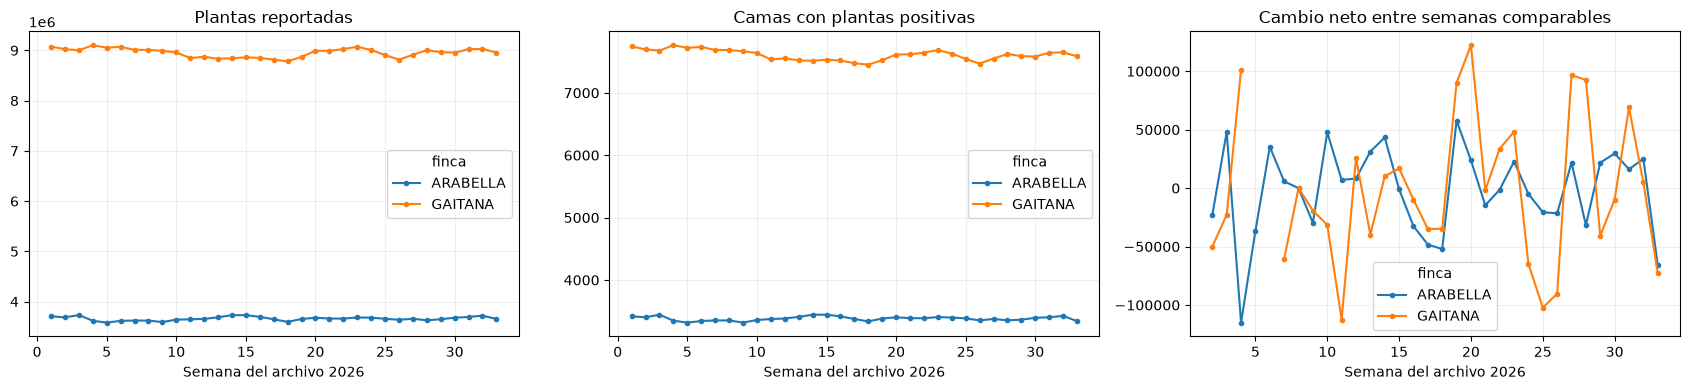

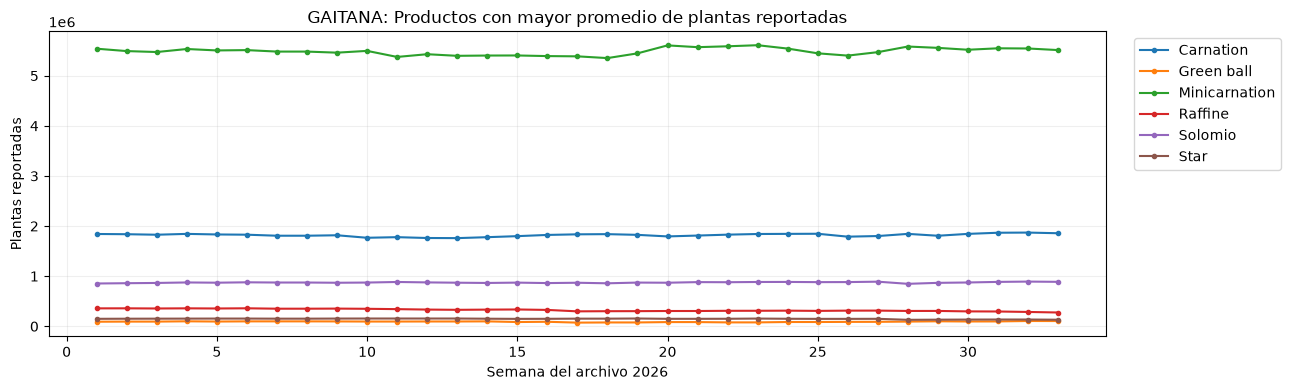

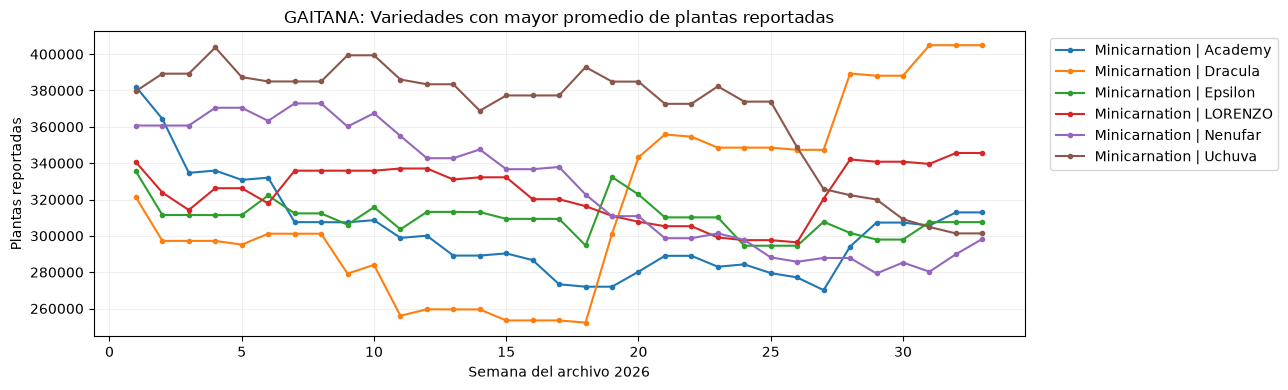

Mayores cambios por producto y variedad: revisar las semanas/archivos señalados.


,finca,producto,variedad,semana,plantas_reportadas,camas_con_plantas,cantidades_ausentes,cantidades_negativas,retiradas_finca,cantidad_comparable,cambio_plantas,cambio_porcentual,magnitud_cambio
5502,GAITANA,Minicarnation,Aragon,27,323449,266,0,0,0,True,50400.0,18.458225,50400.0
6080,GAITANA,Minicarnation,Dracula,19,301198,245,0,0,0,True,48960.0,19.410240,48960.0
328,ARABELLA,Carnation,DON LUIS,26,161072,149,0,0,0,True,46346.0,40.397120,46346.0
6081,GAITANA,Minicarnation,Dracula,20,343210,279,0,0,0,True,42012.0,13.948300,42012.0
6089,GAITANA,Minicarnation,Dracula,28,389320,317,0,0,0,True,41970.0,12.082913,41970.0
6146,GAITANA,Minicarnation,Epsilon,19,332356,271,0,0,0,True,37650.0,12.775444,37650.0
7439,GAITANA,Minicarnation,Whisper,23,177998,141,0,0,0,True,36924.0,26.173498,36924.0
5824,GAITANA,Minicarnation,Chateau,19,199888,164,0,0,0,True,36540.0,22.369420,36540.0
6659,GAITANA,Minicarnation,Nimbus,20,178492,149,0,0,0,True,33600.0,23.189686,33600.0
553,ARABELLA,Carnation,Grandsole,20,201446,195,0,0,0,True,33134.0,19.686059,33134.0


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, variable, titulo in zip(axes,
        ["plantas_reportadas","camas_con_plantas","cambio_plantas"],
        ["Plantas reportadas", "Camas con plantas positivas", "Cambio neto entre semanas comparables"]):
    siembra_finca.pivot(index="semana", columns="finca", values=variable).plot(ax=ax, marker=".", title=titulo)
    ax.set_xlabel("Semana del archivo 2026")
    ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

FINCA_DETALLE = "GAITANA"
assert FINCA_DETALLE in siembra_finca.finca.values, "Elegir una finca presente en siembra_finca."
for panel, columnas, titulo in [
    (siembra_producto, ["producto"], "Productos"),
    (siembra_variedad, ["producto","variedad"], "Variedades"),
]:
    d = panel.loc[panel.finca.eq(FINCA_DETALLE)].copy()
    d["serie"] = d[columnas].agg(" | ".join, axis=1)
    mayores = d.groupby("serie").plantas_reportadas.mean().nlargest(6).index
    grafico = d.loc[d.serie.isin(mayores)].pivot(index="semana", columns="serie", values="plantas_reportadas")
    grafico.plot(figsize=(13, 4), marker=".", title=f"{FINCA_DETALLE}: {titulo} con mayor promedio de plantas reportadas")
    plt.ylabel("Plantas reportadas")
    plt.xlabel("Semana del archivo 2026")
    plt.grid(alpha=.2)
    plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()

print("Mayores cambios por producto y variedad: revisar las semanas/archivos señalados.")
cambios_mayores = siembra_variedad.loc[siembra_variedad.cambio_plantas.notna()].copy()
cambios_mayores["magnitud_cambio"] = cambios_mayores.cambio_plantas.abs()
display(cambios_mayores.sort_values("magnitud_cambio", ascending=False).head(20))

tipo_cambio,aparece,cambia_composicion,cambia_fecha_siembra,deja_de_verse,no_comparable,sin_cambio
finca,,,,,,
ARABELLA,1134,266,37,1212,0,106742
GAITANA,2640,546,117,2771,15567,224536


,finca,invernadero,cama,composicion_anterior,ciclos_anterior,plantas_anterior,archivo_anterior,composicion_actual,ciclos_actual,plantas_actual,archivo_actual,_merge,comparacion_valida,tipo_cambio,semana_anterior,semana_actual
915,ARABELLA,BLOQUE 08,137,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-09,)",380.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
916,ARABELLA,BLOQUE 08,138,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-09,)",744.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
917,ARABELLA,BLOQUE 08,139,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-05,)",644.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
919,ARABELLA,BLOQUE 08,140,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-09,)",744.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
920,ARABELLA,BLOQUE 08,141,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-05,)",644.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
921,ARABELLA,BLOQUE 08,142,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-05,)",747.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
922,ARABELLA,BLOQUE 08,143,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-05,)",644.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
923,ARABELLA,BLOQUE 08,144,NaN,NaN,NaN,NaN,"(Carnation | Lege Pink,)","(Carnation | Lege Pink | 2026-01-05,)",744.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
924,ARABELLA,BLOQUE 08,145,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-05,)",644.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2
925,ARABELLA,BLOQUE 08,146,NaN,NaN,NaN,NaN,"(Carnation | Apple Tea,)","(Carnation | Apple Tea | 2026-01-09,)",744.0,Plano de Siembras Sem 02.xlsx,right_only,True,aparece,1,2


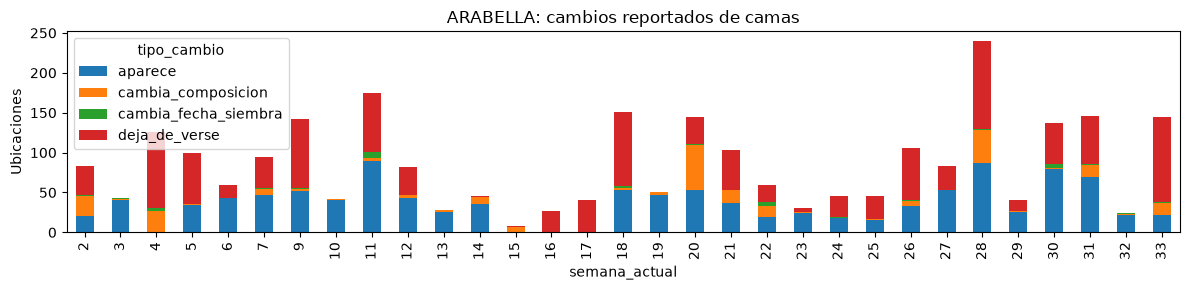

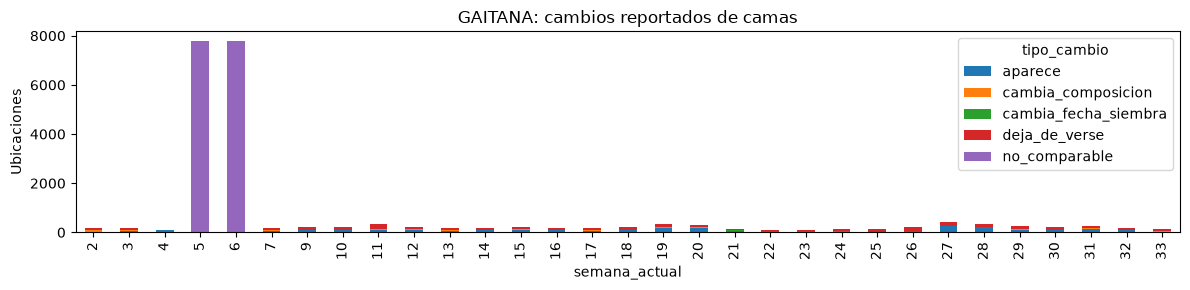

In [43]:
ocupadas=siembra_eda.loc[siembra_eda.id_cama.notna() & siembra_eda.finca.notna()].copy()
ocupadas['composicion']=(ocupadas.producto.fillna('?')+' | '+ocupadas.variedad.fillna('?'))
ocupadas['ciclo']=ocupadas.composicion+' | '+ocupadas.fecha_siembra.astype('string').fillna('?')
ubicacion=['finca','invernadero','cama']
estado_camas=ocupadas.groupby(['semana']+ubicacion,as_index=False).agg(
    composicion=('composicion',lambda s:tuple(sorted(set(s)))),
    ciclos=('ciclo',lambda s:tuple(sorted(set(s)))),plantas=('plantas','sum'),archivo=('archivo','first'))
movimientos=[]
for anterior,actual in zip(sorted(estado_camas.semana.unique())[:-1],sorted(estado_camas.semana.unique())[1:]):
    if actual-anterior!=1: continue
    a=estado_camas.loc[estado_camas.semana.eq(anterior)].drop(columns='semana')
    b=estado_camas.loc[estado_camas.semana.eq(actual)].drop(columns='semana')
    m=a.merge(b,on=ubicacion,how='outer',suffixes=('_anterior','_actual'),indicator=True,validate='one_to_one')
    control=siembra_finca.loc[siembra_finca.semana.isin([anterior,actual])].groupby('finca').cantidad_comparable.agg(['all','size'])
    validas=control.index[control['all'] & control['size'].eq(2)]
    m['comparacion_valida']=m.finca.isin(validas)
    m['tipo_cambio']=np.select([~m.comparacion_valida,m._merge.eq('left_only'),m._merge.eq('right_only'),
        m.composicion_anterior.ne(m.composicion_actual),m.ciclos_anterior.ne(m.ciclos_actual)],
        ['no_comparable','deja_de_verse','aparece','cambia_composicion','cambia_fecha_siembra'],default='sin_cambio')
    m['semana_anterior'],m['semana_actual']=anterior,actual
    movimientos.append(m)
cambios_camas_detalle=pd.concat(movimientos,ignore_index=True)
cambios_camas_resumen=cambios_camas_detalle.groupby(['finca','semana_actual','tipo_cambio']).size().rename('camas').reset_index()
display(cambios_camas_resumen.groupby(['finca','tipo_cambio']).camas.sum().unstack(fill_value=0))
display(cambios_camas_detalle.loc[cambios_camas_detalle.tipo_cambio.ne('sin_cambio')].head(20))
for finca,g in cambios_camas_resumen.groupby('finca'):
    t=g.loc[g.tipo_cambio.ne('sin_cambio')].pivot(index='semana_actual',columns='tipo_cambio',values='camas').fillna(0)
    if not t.empty:
        t.plot(kind='bar',stacked=True,figsize=(12,3),title=f'{finca}: cambios reportados de camas')
        plt.ylabel('Ubicaciones'); plt.tight_layout(); plt.show()


### 4.3. Estadísticas: cobertura temporal, rendimiento y curvas por edad
El corte semanal de pilotos no representa la producción total de la finca. El rendimiento agregado es **suma de cortes / suma de plantas observadas**, ponderado por plantas; el denominador contiene exposiciones planta-semana, no plantas únicas. Se muestran cobertura por producto, años, pilotos y variedades, además de sustrato/casa. Estas comparaciones son descriptivas y pueden estar confundidas por variedad, edad y época.
Las curvas históricas de esta sección sirven para explorar. La sección 5 recalcula curvas con historia reciente anterior a cada plano para evitar utilizar cortes futuros.


,producto,observaciones,pilotos,variedades,desde,hasta,corte,plantas_semana,flores_x_planta_semana
0,Achillea,518,13,4,2023-07-10,2026-04-13,1.317100e+04,39278.0,0.335328
1,Barbatus,2975,339,19,2021-08-02,2026-06-29,7.314030e+05,2832170.0,0.258248
2,Carnation,134283,3644,253,2012-12-31,2026-07-13,2.773971e+07,160919999.0,0.172382
3,Green ball,5397,524,9,2014-09-29,2026-07-13,1.603956e+06,6537848.0,0.245334
4,Lepidium,19,12,1,2023-04-03,2023-07-31,1.662400e+04,21333.0,0.779262
5,Marigold,3,1,1,2022-10-31,2022-11-14,1.401000e+03,5100.0,0.274706
6,Minicarnation,156883,3917,134,2013-12-30,2026-07-13,3.628577e+07,190072408.0,0.190905
7,Raffine,21848,517,15,2017-05-01,2026-07-06,4.963633e+06,21818280.0,0.227499
8,Solomio,41227,1089,33,2017-12-11,2026-06-29,9.186484e+06,41474846.0,0.221495
9,Star,3269,71,1,2021-04-05,2026-06-29,6.515940e+05,3269000.0,0.199325


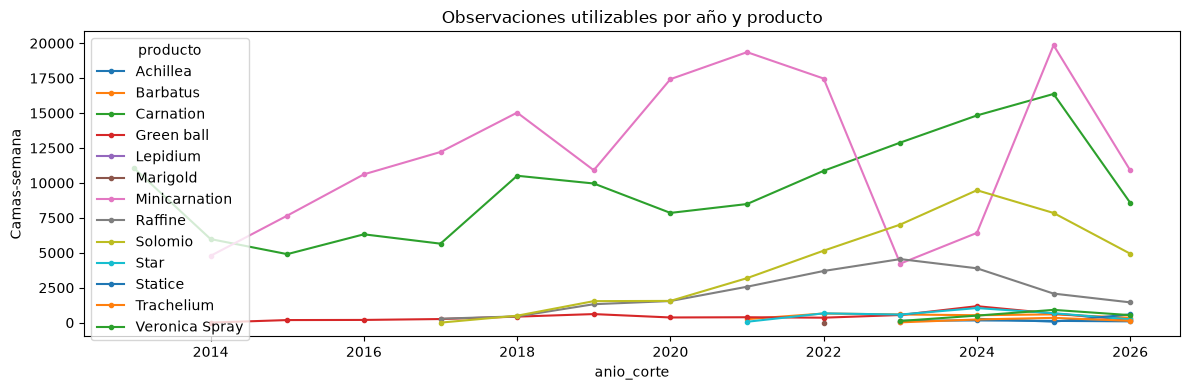

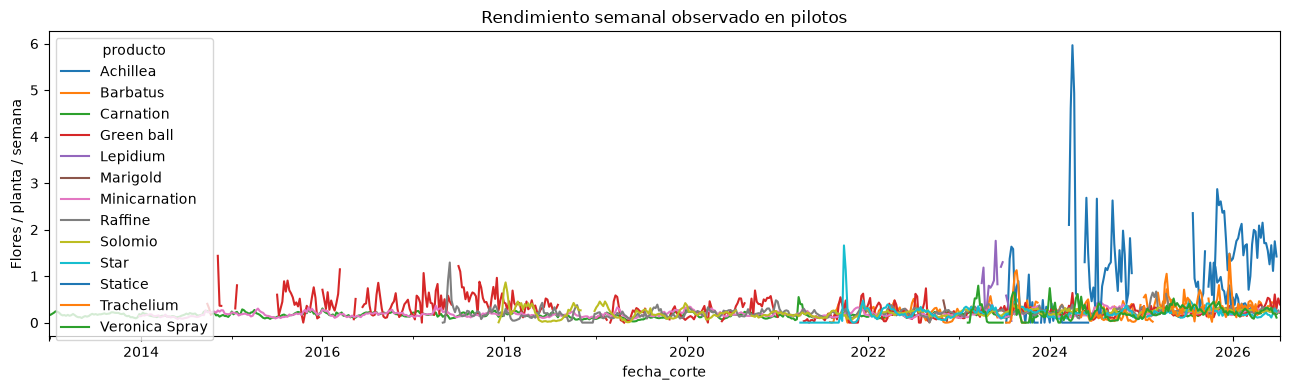

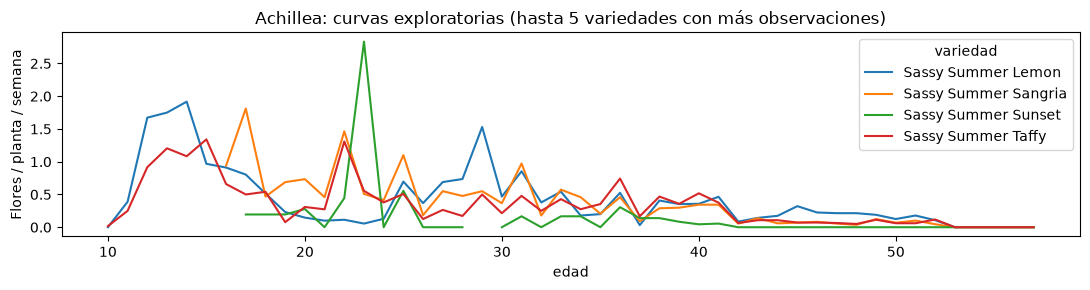

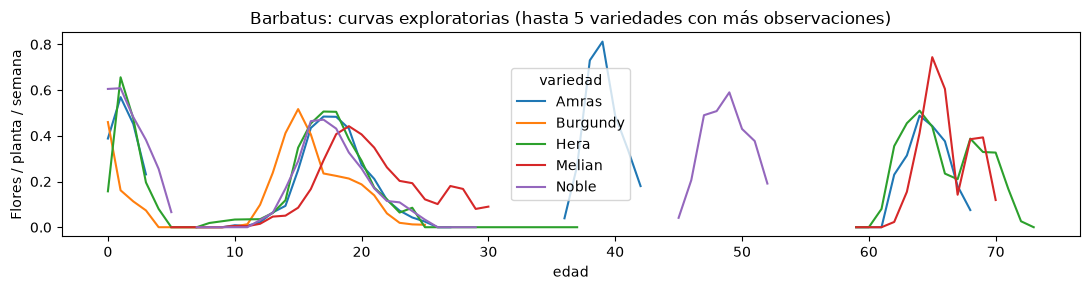

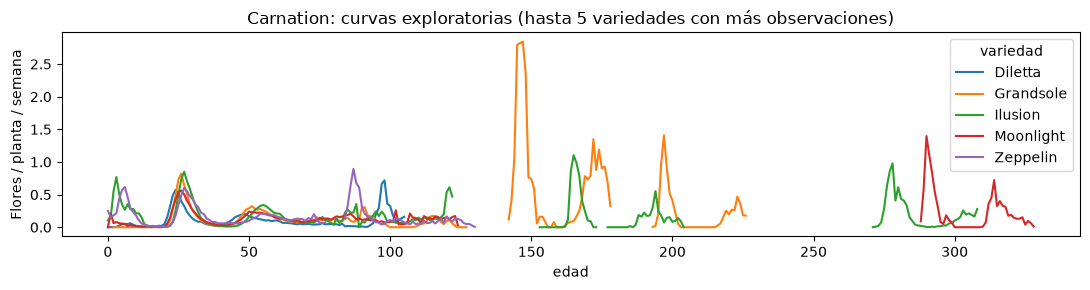

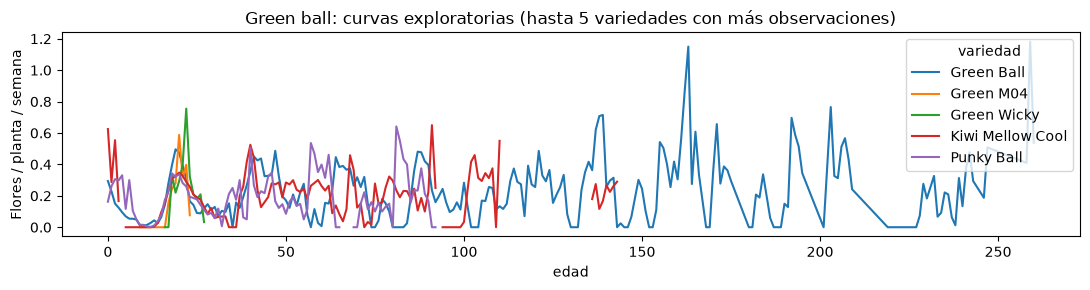

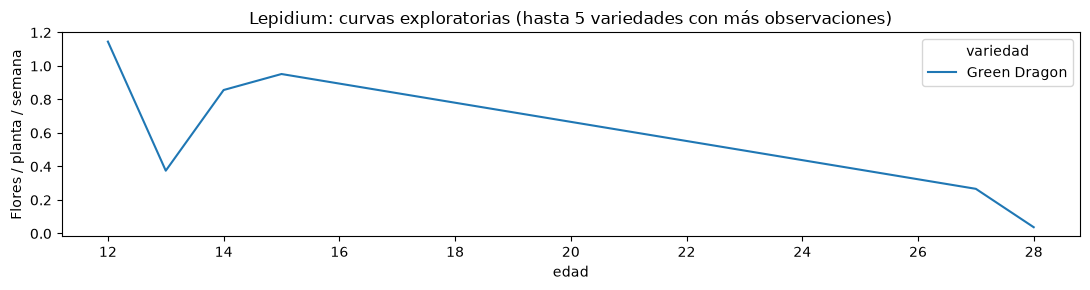

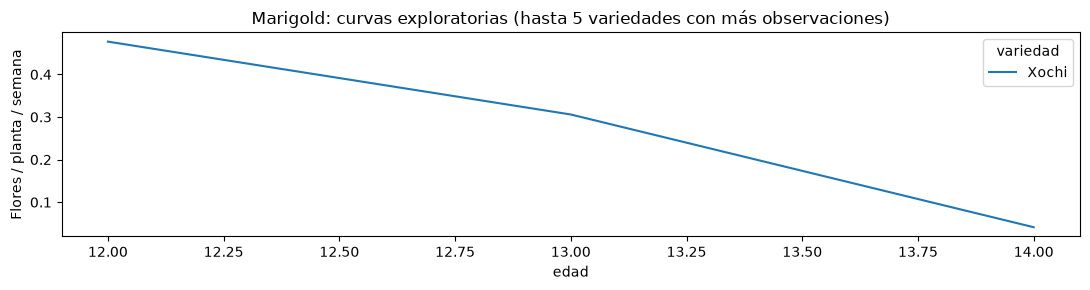

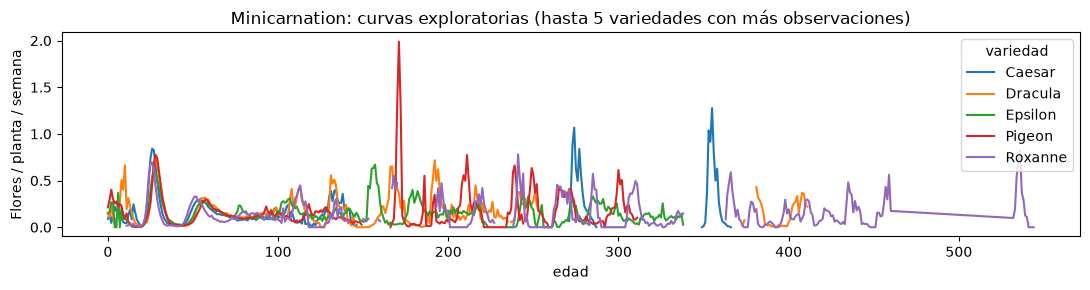

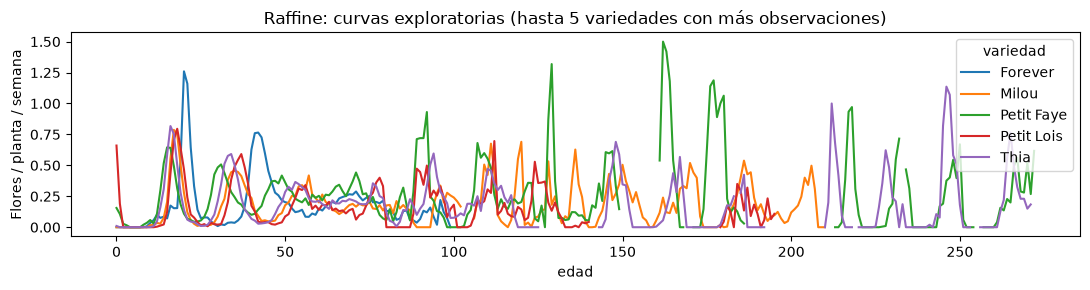

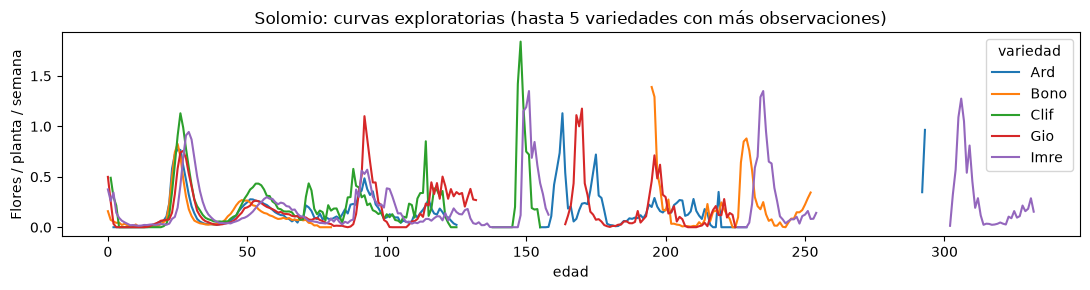

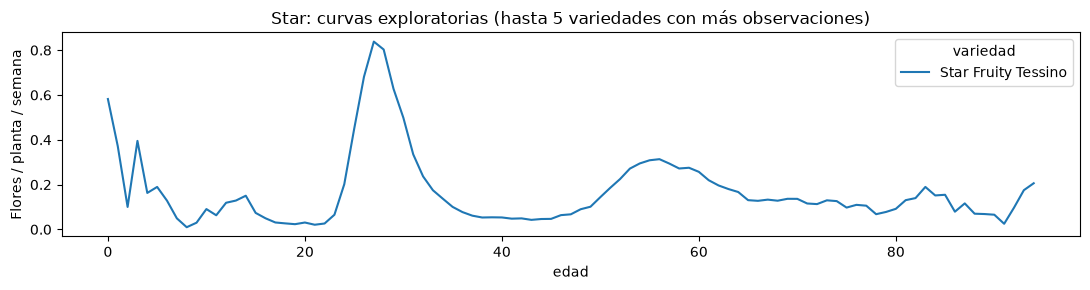

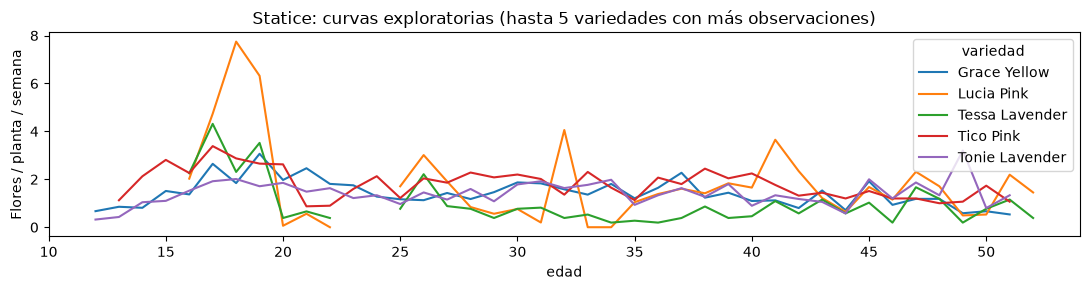

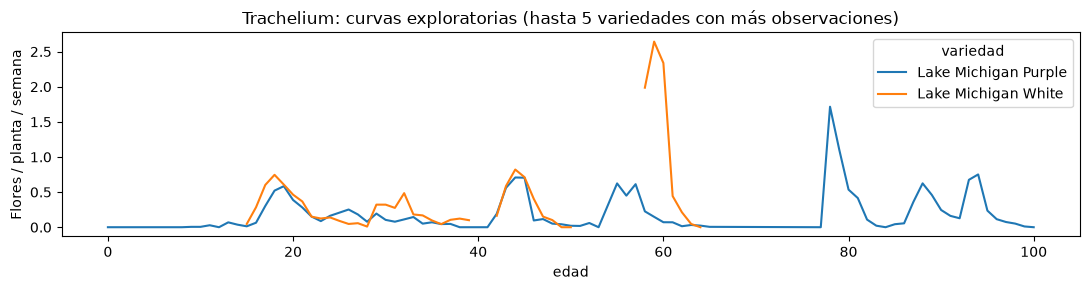

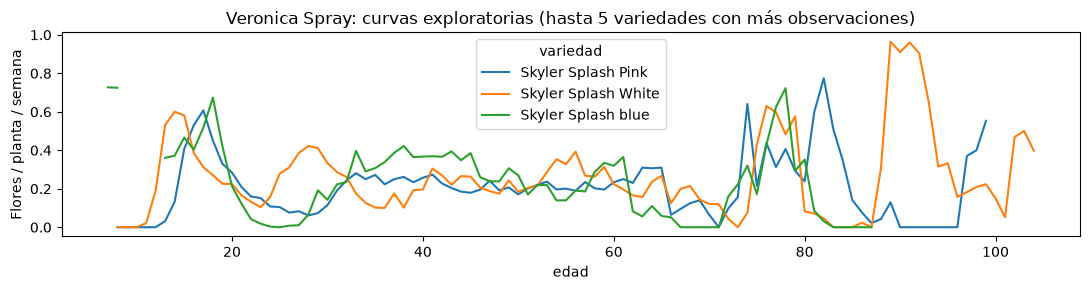

,producto,sustrato,observaciones,pilotos,corte,plantas_semana,flores_x_planta_semana
20,Minicarnation,S90%,130810,3350,3.088959e+07,160615664.0,0.192320
4,Carnation,S90%,94093,2431,1.863024e+07,112035218.0,0.166289
33,Solomio,0.9,41189,1088,9.182295e+06,41436846.0,0.221597
31,Raffine,0.9,21789,516,4.950149e+06,21749604.0,0.227597
21,Minicarnation,SG,15719,332,3.082182e+06,17545718.0,0.175666
3,Carnation,S85%,12387,510,3.446783e+06,14606524.0,0.235976
5,Carnation,SG,11028,270,2.074164e+06,14375458.0,0.144285
8,Carnation,SG1,7923,201,1.747351e+06,9346265.0,0.186957
16,Minicarnation,0,7545,184,1.677450e+06,8752666.0,0.191650
11,Green ball,S90%,4359,396,1.110316e+06,5253020.0,0.211367


,producto,casa_breeder,observaciones,pilotos,corte,plantas_semana,flores_x_planta_semana
32,Solomio,NaN,41227,1089,9186483.970,41474846.0,0.221495
12,Carnation,Selecta,34754,990,7064491.000,43231756.0,0.163410
26,Minicarnation,Sb Talee,34707,892,8093017.000,41467769.0,0.195164
19,Minicarnation,Breier,29615,719,7101667.000,36941002.0,0.192243
11,Carnation,Sb Talee,27118,768,5709972.000,32250205.0,0.177052
27,Minicarnation,Selecta,26724,659,5819196.500,32499887.0,0.179053
5,Carnation,Dummen Orange,23322,633,4868051.339,27927132.0,0.174313
31,Raffine,NaN,21848,517,4963633.000,21818280.0,0.227499
22,Minicarnation,Hilverda Florist,20182,568,5009286.000,24757342.0,0.202335
21,Minicarnation,Dummen Orange,14958,363,3231108.000,17602462.0,0.183560


In [44]:
d=df_estadisticas_eda
resumen_pilotos=d.groupby('producto').agg(observaciones=('id_estadistica','size'),pilotos=('id_piloto','nunique'),
    variedades=('IdVariedad','nunique'),desde=('fecha_corte','min'),hasta=('fecha_corte','max'),
    corte=('corte','sum'),plantas_semana=('plantas','sum')).reset_index()
resumen_pilotos['flores_x_planta_semana']=resumen_pilotos.corte/resumen_pilotos.plantas_semana
display(resumen_pilotos)
cobertura_temporal=d.groupby(['anio_corte','producto']).size().unstack()
cobertura_temporal.plot(figsize=(12,4),marker='.',title='Observaciones utilizables por año y producto')
plt.ylabel('Camas-semana'); plt.tight_layout(); plt.show()
rendimiento_semanal=d.groupby(['fecha_corte','producto']).agg(corte=('corte','sum'),plantas=('plantas','sum')).reset_index()
rendimiento_semanal['flores_x_planta']=rendimiento_semanal.corte/rendimiento_semanal.plantas
rendimiento_semanal.pivot(index='fecha_corte',columns='producto',values='flores_x_planta').plot(figsize=(13,4),title='Rendimiento semanal observado en pilotos')
plt.ylabel('Flores / planta / semana'); plt.tight_layout(); plt.show()
curvas_eda=d.groupby(['producto','variedad','IdVariedad','edad']).agg(corte=('corte','sum'),
    plantas=('plantas','sum'),observaciones=('id_estadistica','size'),pilotos=('id_piloto','nunique')).reset_index()
curvas_eda['flores_x_planta']=curvas_eda.corte/curvas_eda.plantas
for producto,g in curvas_eda.groupby('producto'):
    top=d.loc[d.producto.eq(producto)].groupby('variedad').size().nlargest(5).index
    g.loc[g.variedad.isin(top)].pivot(index='edad',columns='variedad',values='flores_x_planta').plot(
        figsize=(11,3),title=f'{producto}: curvas exploratorias (hasta 5 variedades con más observaciones)')
    plt.ylabel('Flores / planta / semana'); plt.tight_layout(); plt.show()
for dimension in ['sustrato','casa_breeder']:
    t=d.groupby(['producto',dimension],dropna=False).agg(observaciones=('id_estadistica','size'),
        pilotos=('id_piloto','nunique'),corte=('corte','sum'),plantas_semana=('plantas','sum')).reset_index()
    t['flores_x_planta_semana']=t.corte/t.plantas_semana
    display(t.sort_values('observaciones',ascending=False).head(20))


### 4.4. Lectura de los resultados guardados y decisiones pendientes

Esta lectura corresponde a los archivos de la ejecución guardada; si cambian las fuentes, revisar nuevamente las tablas anteriores.

- Los 34 archivos de planos producen **33 fotografías semanales seleccionadas**, con **388.264 registros**. La otra edición de semana 32 permanece en `df_planos_completo`.
- Se conservan **530.250 registros de estadísticas** identificados o con corte. **423.373 (79,84%)** tienen una unión única; los **106.877 restantes (20,16%)** quedan en `uniones_pendientes`. La mayoría de las dificultades son ambigüedades históricas; no corresponde descartar todo ese bloque como si fuera un faltante pequeño.
- En **2026**, la unión única alcanza **98,83% en Clavel, 98,54% en Green Ball, 96,65% en Miniclavel y 99,32% en Raffine/Solomio/Otros**. Conviene revisar esos faltantes recientes primero y separar la decisión sobre historia antigua.
- La vista de rendimientos contiene **370.172 observaciones**, incluidos **74.265 cortes cero**. La diferencia respecto a las uniones únicas también incluye controles de maestros, fechas, cantidades y cortes repetidos; el desglose está en `control_eda_estadisticas`.

**Decisión aplicada:** conservar las bases completas y analizar sólo una vista utilizable. **Decisión pendiente:** revisar duplicados de camas piloto (incluidos registros que parecen idénticos), conflictos de ciclo y nombres no resueltos antes de autorizar descartes o equivalencias adicionales. No se ha aplicado eliminación por porcentaje de unión fallida.


## 4.5 Estrucutra de salidas finales


### Limpieza y revisión de planos 

In [45]:
df_planos.head()

,c,codigo_finca,finca,codigo_invernadero,invernadero,sector,cama,numero_cama,producto,color,variedad,plantas,fecha_siembra,semana_siembra,anio_siembra,sustrato,proveedor,fila_excel,archivo,semana_plano,anio_plano,fecha_plano,plantas_original,fecha_siembra_original,cantidad_invalida,edad_plano,producto_original,color_original,variedad_original,IdVariedad,IdProducto,IdColor,estado_maestro,conflicto_color,llave_repetida
0,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,80,80,Carnation,gold,Caroline Gold,1236,2025-02-26,9,2025,Sustrato 85%,SELECTA,3,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,1236,2025-02-26 00:00:00,False,44.0,Carnation,gold,Caroline Gold,256.0,71,21,unico,False,False
1,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,90,90,Carnation,yellow,Diletta,816,2025-02-26,9,2025,Sustrato 85%,SELECTA,4,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,816,2025-02-26 00:00:00,False,44.0,Carnation,yellow,Diletta,551.0,71,39,unico,False,False
2,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,90,90,Carnation,peach,Novia,360,2025-02-26,9,2025,Sustrato 85%,DUMMEN O,5,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,360,2025-02-26 00:00:00,False,44.0,Carnation,peach,Novia,435.0,71,33,unico,False,False
3,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,94,94,Carnation,peach,Novia,696,2025-02-26,9,2025,Sustrato 85%,DUMMEN O,6,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,696,2025-02-26 00:00:00,False,44.0,Carnation,peach,Novia,435.0,71,33,unico,False,False
4,G,01,ARABELLA,G01,BLOQUE 01,Lina Villanueva,94,94,Carnation,light brown,HONEY,534,2025-02-26,9,2025,Sustrato 85%,BREIER,7,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,534,2025-02-26 00:00:00,False,44.0,Carnation,light brown,Honey,NaN,71,52,ambiguo,False,False


In [46]:
df_planos.tail()

,c,codigo_finca,finca,codigo_invernadero,invernadero,sector,cama,numero_cama,producto,color,variedad,plantas,fecha_siembra,semana_siembra,anio_siembra,sustrato,proveedor,fila_excel,archivo,semana_plano,anio_plano,fecha_plano,plantas_original,fecha_siembra_original,cantidad_invalida,edad_plano,producto_original,color_original,variedad_original,IdVariedad,IdProducto,IdColor,estado_maestro,conflicto_color,llave_repetida
400016,NaN,NaN,GAITANA,NaN,BLOQUE 33,Cristina Guzman,9,9,Solomio,yellow,Blondfly,400,2026-04-02,14,2026,NaN,SELECTA,11632,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,400,2026-04-02 00:00:00,False,19.0,Solomio,yellow,Blondfly,7853.0,70,39,unico,False,False
400017,NaN,NaN,GAITANA,NaN,BLOQUE 33,Cristina Guzman,10,10,Solomio,green,Bern,1000,2026-03-27,13,2026,NaN,HILVERDA,11633,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,1000,2026-03-27 00:00:00,False,20.0,Solomio,green,Bern,4249.0,70,22,unico,False,False
400018,NaN,NaN,GAITANA,NaN,BLOQUE 33,Cristina Guzman,11,11,Solomio,orange,Clif,1000,2026-03-27,13,2026,NaN,HILVERDA,11634,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,1000,2026-03-27 00:00:00,False,20.0,Solomio,orange,Clif,4154.0,70,32,unico,False,False
400019,NaN,NaN,GAITANA,NaN,BLOQUE 33,Cristina Guzman,12,12,Solomio,orange,Clif,1000,2026-03-27,13,2026,NaN,HILVERDA,11635,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,1000,2026-03-27 00:00:00,False,20.0,Solomio,orange,Clif,4154.0,70,32,unico,False,False
400020,NaN,NaN,GAITANA,NaN,BLOQUE 33,Cristina Guzman,33,33,Lepidium,green,Green Dragon,1000,2026-07-10,28,2026,NaN,DANZIGER,11636,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,1000,2026-07-10 00:00:00,False,5.0,Lepidium,green,Green Dragon,6705.0,2106,22,unico,False,False


In [47]:
columnas = [
    "finca",
    "invernadero",
    "numero_cama",
    "producto",
    "color",
    "variedad",
    "plantas",
    "fecha_siembra",
    "semana_siembra",
    "anio_siembra",
    "proveedor",
    "archivo",
    "semana_plano",
    "anio_plano",
    "fecha_plano",
    "plantas_original",
    "fecha_siembra_original",
    "edad_plano",
    "producto_original",
    "color_original",
    "variedad_original"
]

In [48]:
planos =df_planos[columnas].copy()

In [49]:
planos

,finca,invernadero,numero_cama,producto,color,variedad,plantas,fecha_siembra,semana_siembra,anio_siembra,proveedor,archivo,semana_plano,anio_plano,fecha_plano,plantas_original,fecha_siembra_original,edad_plano,producto_original,color_original,variedad_original
0,ARABELLA,BLOQUE 01,80,Carnation,gold,Caroline Gold,1236,2025-02-26,9,2025,SELECTA,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,1236,2025-02-26 00:00:00,44.0,Carnation,gold,Caroline Gold
1,ARABELLA,BLOQUE 01,90,Carnation,yellow,Diletta,816,2025-02-26,9,2025,SELECTA,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,816,2025-02-26 00:00:00,44.0,Carnation,yellow,Diletta
2,ARABELLA,BLOQUE 01,90,Carnation,peach,Novia,360,2025-02-26,9,2025,DUMMEN O,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,360,2025-02-26 00:00:00,44.0,Carnation,peach,Novia
3,ARABELLA,BLOQUE 01,94,Carnation,peach,Novia,696,2025-02-26,9,2025,DUMMEN O,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,696,2025-02-26 00:00:00,44.0,Carnation,peach,Novia
4,ARABELLA,BLOQUE 01,94,Carnation,light brown,HONEY,534,2025-02-26,9,2025,BREIER,Plano de Siembras Sem 01.xlsx,1,2026,2025-12-29,534,2025-02-26 00:00:00,44.0,Carnation,light brown,Honey
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400016,GAITANA,BLOQUE 33,9,Solomio,yellow,Blondfly,400,2026-04-02,14,2026,SELECTA,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,400,2026-04-02 00:00:00,19.0,Solomio,yellow,Blondfly
400017,GAITANA,BLOQUE 33,10,Solomio,green,Bern,1000,2026-03-27,13,2026,HILVERDA,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,1000,2026-03-27 00:00:00,20.0,Solomio,green,Bern
400018,GAITANA,BLOQUE 33,11,Solomio,orange,Clif,1000,2026-03-27,13,2026,HILVERDA,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,1000,2026-03-27 00:00:00,20.0,Solomio,orange,Clif
400019,GAITANA,BLOQUE 33,12,Solomio,orange,Clif,1000,2026-03-27,13,2026,HILVERDA,Plano de Siembras Sem 33.xlsx,33,2026,2026-08-10,1000,2026-03-27 00:00:00,20.0,Solomio,orange,Clif


### Limpieza y revisión de Estadísitcas

In [50]:
df_estadisticas_eda

,archivo,fila_excel_est,referencia,producto,color,variedad,anio_corte,semana_corte,corte,corte_original,edad_original,fecha_siembra_est,semana_siembra_est,anio_siembra_est,sustrato_est,casa_breeder_est,producto_original,color_original,variedad_original,IdVariedad,IdProducto,IdColor,estado_maestro,conflicto_color,variedad_llave,referencia_llave,fecha_semana_siembra,id_estadistica,fecha_corte,id_piloto,candidatas_iniciales,candidatas_compatibles,estado_union,fila_excel_pil,plantas,fecha_siembra_pil,anio_siembra_pil,semana_siembra_pil,sustrato_pil,casa_breeder_pil,conflicto_fecha_siembra,fecha_siembra,origen_fecha_siembra,conflicto_anio_siembra,anio_siembra,origen_anio_siembra,conflicto_semana_siembra,semana_siembra,origen_semana_siembra,conflicto_sustrato,sustrato,origen_sustrato,conflicto_casa_breeder,casa_breeder,origen_casa_breeder,edad,flores_x_planta,diferencia_edad,corte_repetido
0,Estadisticas Clavel 2026.xlsx,2,POMODORO-6-64,Carnation,red,Pomodoro,2013.0,1.0,115.0,115,79.0,2011-07-13,28.0,2011.0,S90%,Sb Talee,CARNATION,Rojo,POMODORO,504.0,71.0,35.0,unico,False,POMODORO,POMODORO-6-64,2011-07-11,0,2012-12-31,870.0,1,1,unica,872.0,1400.0,2011-07-13,2011.0,28.0,S90%,<NA>,False,2011-07-13,piloto,False,2011.0,piloto,False,28.0,piloto,False,S90%,piloto,False,Sb Talee,estadistica,77,0.082143,-2.0,False
1,Estadisticas Clavel 2026.xlsx,3,POMODORO-6-66,Carnation,red,Pomodoro,2013.0,1.0,204.0,204,59.0,2011-11-30,48.0,2011.0,S90%,Sb Talee,CARNATION,Rojo,POMODORO,504.0,71.0,35.0,unico,False,POMODORO,POMODORO-6-66,2011-11-28,1,2012-12-31,871.0,1,1,unica,873.0,1028.0,2011-11-30,2011.0,48.0,S90%,<NA>,False,2011-11-30,piloto,False,2011.0,piloto,False,48.0,piloto,False,S90%,piloto,False,Sb Talee,estadistica,57,0.198444,-2.0,False
2,Estadisticas Clavel 2026.xlsx,4,CARIBE-6-211,Carnation,red,Caribe,2013.0,1.0,106.0,106,36.0,2012-05-12,18.0,2012.0,S90%,NaN,CARNATION,Rojo,CARIBE,471.0,71.0,35.0,unico,False,CARIBE,CARIBE-6-211,2012-05-07,2,2012-12-31,1539.0,1,1,unica,1541.0,1020.0,2012-05-12,2012.0,18.0,S90%,<NA>,False,2012-05-12,piloto,False,2012.0,piloto,False,18.0,piloto,False,S90%,piloto,False,NaN,faltante,34,0.103922,-2.0,False
3,Estadisticas Clavel 2026.xlsx,5,LION KING-9-74,Carnation,orange,Lion King,2013.0,1.0,670.0,670,30.0,2012-06-19,24.0,2012.0,S90%,Hilverda Kooij,CARNATION,Naranja,LION KING,404.0,71.0,32.0,unico,False,LION KING,LION KING-9-74,2012-06-18,3,2012-12-31,1823.0,1,1,unica,1825.0,1024.0,2012-06-19,2012.0,24.0,S90%,<NA>,False,2012-06-19,piloto,False,2012.0,piloto,False,24.0,piloto,False,S90%,piloto,False,Hilverda Kooij,estadistica,28,0.654297,-2.0,False
5,Estadisticas Clavel 2026.xlsx,7,LION KING-9-132,Carnation,orange,Lion King,2013.0,1.0,185.0,185,89.0,2011-05-04,18.0,2011.0,S90%,Hilverda Kooij,CARNATION,Naranja,LION KING,404.0,71.0,32.0,unico,False,LION KING,LION KING-9-132,2011-05-02,5,2012-12-31,1038.0,1,1,unica,1040.0,1000.0,2011-05-04,2011.0,18.0,S90%,<NA>,False,2011-05-04,piloto,False,2011.0,piloto,False,18.0,piloto,False,S90%,piloto,False,Hilverda Kooij,estadistica,87,0.185000,-2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529862,Estadisticas Raffine_Solomio_Otros 2026.xlsx,108809,petit faye-27-157,Raffine,bicolor burgundy,Petit Faye,2026.0,28.0,194.0,194,73.0,2025-02-14,7.0,2025.0,0.9,<NA>,RAFFINE,Bicolor Burgundy,petit faye,1047.0,73.0,4.0,unico,False,PETIT FAYE,PETIT FAYE-27-157,2025-02-10,529862,2026-07-06,31652.0,1,1,unica,2983.0,1000.0,2025-02-14,2025.0,7.0,0.9,<NA>,False,2025-02-14,piloto,False,2025.0,piloto,False,7.0,piloto,False,0.9,piloto,False,<NA>,faltante,73,0.194000,0.0,False
529863,Estadisticas Raffine_Solomio_Otros 2026.xlsx,108810,forever-27-159,Raffine,bicolor purple,Forever,2026.0,28.0,212.0,212,71.0,2025-02-28,9.0,2025.0,0.9,<NA>,RAFFINE,BICOLOR MORADO,forever,6498.0,73.0,12.0,unico,False,FOREVE

In [51]:
df_estadisticas_eda.info()

<class 'pandas.DataFrame'>
Index: 370172 entries, 0 to 529866
Data columns (total 59 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   archivo                   370172 non-null  str           
 1   fila_excel_est            370172 non-null  int64         
 2   referencia                370172 non-null  object        
 3   producto                  370172 non-null  str           
 4   color                     370172 non-null  str           
 5   variedad                  370172 non-null  str           
 6   anio_corte                370172 non-null  float64       
 7   semana_corte              370172 non-null  float64       
 8   corte                     370172 non-null  float64       
 9   corte_original            370172 non-null  object        
 10  edad_original             369487 non-null  float64       
 11  fecha_siembra_est         364775 non-null  datetime64[us]
 12  semana_siembra_est

In [52]:
columnas = [
    "archivo",
    "referencia",
    "producto",
    "color",
    "variedad",
    "anio_corte",
    "semana_corte",
    "corte",
    "fecha_siembra_est",
    "semana_siembra_est",
    "anio_siembra_est",
    "producto_original",
    "color_original",
    "variedad_original",
    "IdVariedad",
    "IdProducto",
    "IdColor",
    "fecha_corte",
    "plantas",
    "fecha_siembra",
    "anio_siembra",
    "edad",
    "flores_x_planta",
    "diferencia_edad",
    "corte_repetido"
]





In [53]:
df_estadisticas = df_estadisticas_eda[columnas]

In [54]:
df_estadisticas

,archivo,referencia,producto,color,variedad,anio_corte,semana_corte,corte,fecha_siembra_est,semana_siembra_est,anio_siembra_est,producto_original,color_original,variedad_original,IdVariedad,IdProducto,IdColor,fecha_corte,plantas,fecha_siembra,anio_siembra,edad,flores_x_planta,diferencia_edad,corte_repetido
0,Estadisticas Clavel 2026.xlsx,POMODORO-6-64,Carnation,red,Pomodoro,2013.0,1.0,115.0,2011-07-13,28.0,2011.0,CARNATION,Rojo,POMODORO,504.0,71.0,35.0,2012-12-31,1400.0,2011-07-13,2011.0,77,0.082143,-2.0,False
1,Estadisticas Clavel 2026.xlsx,POMODORO-6-66,Carnation,red,Pomodoro,2013.0,1.0,204.0,2011-11-30,48.0,2011.0,CARNATION,Rojo,POMODORO,504.0,71.0,35.0,2012-12-31,1028.0,2011-11-30,2011.0,57,0.198444,-2.0,False
2,Estadisticas Clavel 2026.xlsx,CARIBE-6-211,Carnation,red,Caribe,2013.0,1.0,106.0,2012-05-12,18.0,2012.0,CARNATION,Rojo,CARIBE,471.0,71.0,35.0,2012-12-31,1020.0,2012-05-12,2012.0,34,0.103922,-2.0,False
3,Estadisticas Clavel 2026.xlsx,LION KING-9-74,Carnation,orange,Lion King,2013.0,1.0,670.0,2012-06-19,24.0,2012.0,CARNATION,Naranja,LION KING,404.0,71.0,32.0,2012-12-31,1024.0,2012-06-19,2012.0,28,0.654297,-2.0,False
5,Estadisticas Clavel 2026.xlsx,LION KING-9-132,Carnation,orange,Lion King,2013.0,1.0,185.0,2011-05-04,18.0,2011.0,CARNATION,Naranja,LION KING,404.0,71.0,32.0,2012-12-31,1000.0,2011-05-04,2011.0,87,0.185000,-2.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
529862,Estadisticas Raffine_Solomio_Otros 2026.xlsx,petit faye-27-157,Raffine,bicolor burgundy,Petit Faye,2026.0,28.0,194.0,2025-02-14,7.0,2025.0,RAFFINE,Bicolor Burgundy,petit faye,1047.0,73.0,4.0,2026-07-06,1000.0,2025-02-14,2025.0,73,0.194000,0.0,False
529863,Estadisticas Raffine_Solomio_Otros 2026.xlsx,forever-27-159,Raffine,bicolor purple,Forever,2026.0,28.0,212.0,2025-02-28,9.0,2025.0,RAFFINE,BICOLOR MORADO,forever,6498.0,73.0,12.0,2026-07-06,1000.0,2025-02-28,2025.0,71,0.212000,0.0,False
529864,Estadisticas Raffine_Solomio_Otros 2026.xlsx,forever-27-172,Raffine,bicolor purple,Forever,2026.0,28.0,250.0,2025-03-15,11.0,2025.0,RAFFINE,BICOLOR MORADO,forever,6498.0,73.0,12.0,2026-07-06,1000.0,2025-03-15,2025.0,69,0.250000,0.0,False
529865,Estadisticas Raffine_Solomio_Otros 2026.xlsx,thia-27-182,Raffine,light pink,Thia,2026.0,28.0,345.0,2025-03-27,13.0,2025.0,RAFFINE,Bicolor rosado,THIA,1057.0,73.0,25.0,2026-07-06,1000.0,2025-03-27,2025.0,67,0.345000,0.0,False


## 5. Proyección teórica y estabilidad entre planos

**No se recortan las tablas completas ni se modifica 4.5.** En pantalla se muestran pocas columnas para facilitar la lectura; las demás siguen disponibles. El EDA trabaja directamente sobre los resultados existentes, sin crear otro conjunto de DataFrames permanentes.

**Para orientarte:**

1. **5.1–5.2:** elegir la historia reciente y construir las curvas.
2. **5.3:** calcular `plantas × curva` para las diez semanas siguientes.
3. **5.4–5.5:** ver cobertura y comprobar el cálculo.
4. **5.6:** leer el resumen semanal sin tantas columnas.
5. **5.7:** comparar **la misma semana de producción** entre planos consecutivos y ver qué variedades cambian.

Entradas: `planos` y `df_estadisticas` de 4.5. Las estadísticas ya tienen la información de camas piloto incorporada; no se repite esa unión. Se une cada siembra del plano con la curva de su variedad a su edad futura.

**Ejemplo ficticio:** 1.000 plantas × 0,20 flores/planta/semana a edad 30 = **200 flores en esa semana**. Para la siguiente semana se usa edad 31, que puede tener otro rendimiento. No se divide nuevamente por siete ni por diez.

### 5.1. Qué fechas y edades usamos para construir la curva

| Regla | Por qué |
|---|---|
| **104 semanas antes del plano**, usando sólo cortes anteriores a su lunes | Combinar historia reciente y suficientes observaciones, sin usar información futura. |
| Ampliar a **156 semanas por variedad** sólo si la cobertura base es menor al 80% y mejora al menos **10 puntos porcentuales** | No ampliar toda la historia para resolver el faltante de unas pocas variedades. |
| Cada edad necesita **3 observaciones, 3 camas/ciclos y el 20% del máximo de ciclos por edad** de esa variedad en la ventana | No dejar que unas pocas camas muy viejas determinen el extremo de la curva. |
| Cada edad necesita algún corte en las **52 semanas anteriores** al plano | Evitar usar un tramo observado únicamente hace años. |
| Sin soporte, no hay curva; no se interpolan huecos ni se extrapolan edades | No inventar producción. Una curva larga puede conservarse si está respaldada por suficientes observaciones recientes. |

Se filtra por **fecha del corte**, no por fecha de siembra. La curva de cada variedad y edad es `suma(corte) / suma(plantas)` dentro de la ventana elegida. La fecha del corte y la edad de la planta son dos cosas distintas: limitar fechas no significa eliminar todas las plantas viejas.

Es un criterio inicial explícito, no un óptimo ya validado. `seleccion_ventanas` conserva fechas exactas, cobertura y motivo de elección; `auditoria_curvas` conserva el soporte de cada edad.


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

HORIZONTE = 10
VENTANA_BASE = 104
VENTANA_AMPLIADA = 156
COBERTURA_OBJETIVO = 0.80
MEJORA_MINIMA = 0.10             # puntos de cobertura en escala 0–1
VIGENCIA_SEMANAS = 52
MIN_OBSERVACIONES = 3
MIN_CICLOS = 3
FRACCION_SOPORTE_EDAD = 0.20

requeridas_planos = ['archivo','fecha_plano','finca','invernadero','numero_cama',
    'producto','color','variedad','plantas','fecha_siembra','edad_plano']
requeridas_est = ['archivo','referencia','producto','color','variedad','IdVariedad',
    'fecha_corte','fecha_siembra','edad','plantas','corte','corte_repetido']
assert set(requeridas_planos).issubset(planos.columns), 'Revisar estructura planos de 4.5'
assert set(requeridas_est).issubset(df_estadisticas.columns), 'Revisar df_estadisticas de 4.5'

# Sólo estas dos estructuras alimentan los cálculos siguientes.
base_planos = planos[requeridas_planos].copy().reset_index(names='indice_estructura_45')
base_estadisticas = df_estadisticas[requeridas_est].copy().reset_index(names='indice_estructura_45')
base_planos['id_fila_plano'] = np.arange(len(base_planos))
for d, columnas_fecha in [(base_planos,['fecha_plano','fecha_siembra']),
                          (base_estadisticas,['fecha_corte','fecha_siembra'])]:
    for c in columnas_fecha:
        d[c] = pd.to_datetime(d[c], errors='coerce')
    d['plantas'] = pd.to_numeric(d.plantas, errors='coerce')
for c in ['corte','edad','IdVariedad']:
    base_estadisticas[c] = pd.to_numeric(base_estadisticas[c], errors='coerce')
assert base_planos.fecha_plano.notna().all(), 'Cada plano debe tener fecha de referencia'
assert base_planos.groupby('archivo').fecha_plano.nunique().eq(1).all()
assert base_planos.fecha_plano.dt.dayofweek.eq(0).all(), 'Se espera el lunes ISO de cada plano'

def clave_nombre(s):
    return (s.astype('string').str.strip().str.upper().str.normalize('NFKD')
            .str.encode('ascii', errors='ignore').str.decode('ascii')
            .str.replace(r'\s+', ' ', regex=True).replace('', pd.NA))

llave_nombre = ['producto_union','color_union','variedad_union']
for d in [base_planos,base_estadisticas]:
    for c in ['producto','color','variedad']:
        d[c+'_union'] = clave_nombre(d[c])

# 4.5 no incluye IdVariedad en planos: recuperarlo sólo de una correspondencia inequívoca.
catalogo = base_estadisticas[llave_nombre+['IdVariedad']].dropna().drop_duplicates()
catalogo['ids_por_nombre'] = catalogo.groupby(llave_nombre).IdVariedad.transform('nunique')
catalogo_ambiguo = catalogo.loc[catalogo.ids_por_nombre.gt(1)].copy()
catalogo_unico = catalogo.loc[catalogo.ids_por_nombre.eq(1),llave_nombre+['IdVariedad']]
base_planos = base_planos.merge(catalogo_unico,on=llave_nombre,how='left',validate='many_to_one')
# No se hace fuzzy matching ni se asigna una variedad sólo por su nombre sin producto/color.
nombres_planos_sin_union = base_planos.loc[base_planos.IdVariedad.isna(),
    ['archivo','producto','color','variedad','plantas']].groupby(
    ['producto','color','variedad'],dropna=False).agg(filas=('archivo','size')).reset_index()

llave_cama = ['archivo','finca','invernadero','numero_cama']+llave_nombre+['fecha_siembra']
base_planos['cama_ciclo_repetido'] = base_planos.duplicated(llave_cama,keep=False)
# Los posibles segmentos repetidos se conservan y se dejan fuera de la fórmula hasta revisarlos.
base_estadisticas['referencia_ciclo'] = clave_nombre(base_estadisticas.referencia).str.replace(r'\s*-\s*','-',regex=True)
ciclo = ['archivo','referencia_ciclo','fecha_siembra']
base_estadisticas['id_ciclo'] = base_estadisticas.groupby(ciclo,dropna=False).ngroup()
repetida = base_estadisticas.duplicated(['id_ciclo','IdVariedad','fecha_corte'],keep=False)
motivos_estadisticas = pd.DataFrame({
    'identidad_incompleta':base_estadisticas[ciclo+['IdVariedad']].isna().any(axis=1),
    'fecha_corte_invalida':base_estadisticas.fecha_corte.isna(),
    'edad_invalida':~base_estadisticas.edad.ge(0) | base_estadisticas.edad.mod(1).ne(0),
    'plantas_invalidas':~base_estadisticas.plantas.gt(0),
    'corte_invalido':~base_estadisticas.corte.ge(0),
    'repeticion':repetida | base_estadisticas.corte_repetido.fillna(True).astype(bool)
})
estadisticas_para_curvas = base_estadisticas.loc[~motivos_estadisticas.any(axis=1)].copy()
estadisticas_para_curvas['edad'] = estadisticas_para_curvas.edad.astype(int)
control_entradas_5 = motivos_estadisticas.sum().rename('filas_afectadas').to_frame()
display(control_entradas_5)
display(nombres_planos_sin_union)
print('Planos:',base_planos.archivo.nunique(),'| filas:',len(base_planos),
      '| observaciones válidas para curvas:',len(estadisticas_para_curvas))

,filas_afectadas
identidad_incompleta,0
fecha_corte_invalida,0
edad_invalida,0
plantas_invalidas,0
corte_invalido,0
repeticion,0


,producto,color,variedad,filas
0,Amazon,purple,NEON PURPLE,491
1,Barbatus,dark pink,Tsar,63
2,Barbatus,hot pink,Neon Cherry,5
3,Barbatus,white,DTJ-23-8856,6
4,Carnation,Vintage,MERLETTO PURPLE,26
...,...,...,...,...
111,Veronica,lavender,Skyler Splash Lavender,21
112,Veronica,light pink,Skyler Pink,673
113,Veronica,purple,Skyler Blue,566
114,Veronica,white,Skyler Duo Crystal,21


Planos: 33 | filas: 388264 | observaciones válidas para curvas: 370172


### 5.2. Construir la curva y unirla con las semanas futuras

El código hace lo siguiente, en ese orden:

1. Toma un plano y crea sus **10 semanas futuras**.
2. Calcula la edad de cada siembra en cada semana futura, usando lunes ISO.
3. Construye el promedio de corte por planta a cada edad con la historia admitida.
4. Evalúa 104 y 156 semanas por variedad y aplica la regla de 5.1.
5. Une por **`IdVariedad + edad_objetivo`**, conservando todas las filas del plano aunque no encuentren curva.

La cobertura usada para elegir ventana es la proporción de plantas-semana con curva entre las requeridas. Una variedad puede quedar con una ventana elegida y cobertura insuficiente; eso se reporta, no se corrige inventando ceros.

**Para revisar una elección:** `seleccion_ventanas` contiene fechas, cobertura de ambas opciones y el motivo. **Para investigar una edad excluida:** `auditoria_curvas` conserva los puntos candidatos y sus controles. La tabla mostrada debajo es una selección corta de columnas; las demás siguen guardadas.


In [56]:
def construir_curva(estadisticas, fecha_plano, ventana):
    desde = fecha_plano - pd.Timedelta(weeks=ventana)
    h = estadisticas.loc[estadisticas.fecha_corte.ge(desde) & estadisticas.fecha_corte.lt(fecha_plano)]
    c = h.groupby(['IdVariedad','edad'],as_index=False).agg(
        corte_acumulado=('corte','sum'),plantas_observadas=('plantas','sum'),
        observaciones=('corte','size'),ciclos=('id_ciclo','nunique'),
        primera_observacion=('fecha_corte','min'),ultima_observacion=('fecha_corte','max'))
    c['max_ciclos_por_edad'] = c.groupby('IdVariedad').ciclos.transform('max')
    c['ciclos_minimos_exigidos'] = np.maximum(MIN_CICLOS,np.ceil(FRACCION_SOPORTE_EDAD*c.max_ciclos_por_edad)).astype(int)
    c['soporte_suficiente'] = c.observaciones.ge(MIN_OBSERVACIONES) & c.ciclos.ge(c.ciclos_minimos_exigidos)
    c['vigente'] = c.ultima_observacion.ge(fecha_plano-pd.Timedelta(weeks=VIGENCIA_SEMANAS))
    c['utilizable'] = c.soporte_suficiente & c.vigente
    c['motivo_curva'] = np.select([~c.soporte_suficiente,~c.vigente],['soporte_insuficiente','sin_observacion_reciente'],default='utilizable')
    c['flores_x_planta_curva'] = (c.corte_acumulado/c.plantas_observadas).where(c.utilizable)
    c['ventana_semanas'] = ventana
    c['desde_inclusive'] = desde
    c['hasta_exclusive'] = fecha_plano
    return c

proyecciones, selecciones, evaluaciones, auditorias = [], [], [], []
for archivo, plano in base_planos.groupby('archivo',sort=True):
    fecha = plano.fecha_plano.iloc[0]
    columnas_objetivo = ['id_fila_plano','indice_estructura_45','archivo','fecha_plano',
        'finca','invernadero','numero_cama','producto','color','variedad','IdVariedad',
        'plantas','fecha_siembra','edad_plano','cama_ciclo_repetido']
    objetivo = plano[columnas_objetivo].merge(pd.DataFrame({'horizonte':range(1,HORIZONTE+1)}),how='cross')
    objetivo['fecha_objetivo'] = fecha + pd.to_timedelta(objetivo.horizonte*7,unit='D')
    lunes_siembra = objetivo.fecha_siembra-pd.to_timedelta(objetivo.fecha_siembra.dt.dayofweek,unit='D')
    objetivo['edad_objetivo'] = ((objetivo.fecha_objetivo-lunes_siembra).dt.days//7).astype('Int64')
    objetivo['diferencia_edad_plano'] = ((fecha-lunes_siembra).dt.days//7)-pd.to_numeric(objetivo.edad_plano,errors='coerce')
    identificada = objetivo[['finca','invernadero','numero_cama']].notna().all(axis=1)
    objetivo['entrada_valida'] = (objetivo.plantas.ge(0) & objetivo.IdVariedad.notna() &
        objetivo.edad_objetivo.notna() & identificada & ~objetivo.cama_ciclo_repetido)
    requiere = objetivo.edad_objetivo.isna() | objetivo.edad_objetivo.ge(0).fillna(False)
    objetivo['plantas_semana_requeridas'] = objetivo.plantas.clip(lower=0).where(requiere,0)
    curvas_archivo, coberturas = [], []
    for ventana in [VENTANA_BASE,VENTANA_AMPLIADA]:
        curva = construir_curva(estadisticas_para_curvas,fecha,ventana).assign(archivo_plano=archivo)
        curvas_archivo.append(curva)
        auditorias.append(curva)
        prueba = objetivo.merge(curva[['IdVariedad','edad','flores_x_planta_curva']],
            left_on=['IdVariedad','edad_objetivo'],right_on=['IdVariedad','edad'],how='left',validate='many_to_one')
        cubierta = prueba.entrada_valida & prueba.edad_objetivo.ge(0).fillna(False) & prueba.flores_x_planta_curva.notna()
        prueba['plantas_semana_cubiertas'] = prueba.plantas.where(cubierta,0)
        cobertura = prueba.groupby('IdVariedad',as_index=False).agg(
            plantas_semana_requeridas=('plantas_semana_requeridas','sum'),
            plantas_semana_cubiertas=('plantas_semana_cubiertas','sum'))
        cobertura['cobertura'] = cobertura.plantas_semana_cubiertas/cobertura.plantas_semana_requeridas.where(cobertura.plantas_semana_requeridas.gt(0))
        cobertura['ventana_semanas'] = ventana
        cobertura['archivo'] = archivo
        evaluaciones.append(cobertura)
        coberturas.append(cobertura)
    decision = pd.concat(coberturas).pivot(index='IdVariedad',columns='ventana_semanas',values='cobertura').reset_index()
    decision = decision.rename(columns={VENTANA_BASE:'cobertura_base',VENTANA_AMPLIADA:'cobertura_ampliada'})
    decision['ganancia_cobertura'] = decision.cobertura_ampliada-decision.cobertura_base
    ampliar = decision.cobertura_base.lt(COBERTURA_OBJETIVO) & decision.ganancia_cobertura.ge(MEJORA_MINIMA)
    decision['ventana_semanas'] = np.where(ampliar,VENTANA_AMPLIADA,VENTANA_BASE)
    decision['motivo_ventana'] = np.select([ampliar,decision.cobertura_base.ge(COBERTURA_OBJETIVO),decision.cobertura_base.isna()],
        ['ampliacion_mejora_cobertura','base_alcanza_objetivo','sin_demanda_positiva'],default='base_sin_mejora_suficiente_al_ampliar')
    decision['cobertura_elegida'] = decision.cobertura_base.where(~ampliar,decision.cobertura_ampliada)
    decision['desde_inclusive'] = fecha-pd.to_timedelta(decision.ventana_semanas*7,unit='D')
    decision['hasta_exclusive'] = fecha
    decision['ultimo_lunes_admisible'] = fecha-pd.Timedelta(weeks=1)
    decision['archivo'] = archivo
    decision = decision.merge(plano[['IdVariedad','producto','variedad']].dropna(subset=['IdVariedad']).drop_duplicates('IdVariedad'),
        on='IdVariedad',how='left',validate='one_to_one')
    curva_elegida = pd.concat(curvas_archivo,ignore_index=True).merge(decision[['IdVariedad','ventana_semanas']],
        on=['IdVariedad','ventana_semanas'],how='inner',validate='many_to_one')
    limites = curva_elegida.loc[curva_elegida.utilizable].groupby('IdVariedad',as_index=False).agg(
        edad_minima_admitida=('edad','min'),edad_maxima_admitida=('edad','max'),edades_con_soporte=('edad','nunique'),
        primer_corte_utilizado=('primera_observacion','min'),ultimo_corte_utilizado=('ultima_observacion','max'))
    selecciones.append(decision.merge(limites,on='IdVariedad',how='left',validate='one_to_one'))
    # La unión final se mantiene izquierda: conservar todas las filas y horizontes del plano.
    pred = objetivo.merge(decision[['IdVariedad','ventana_semanas']],on='IdVariedad',how='left',validate='many_to_one')
    pred = pred.merge(curva_elegida[['IdVariedad','edad','flores_x_planta_curva','observaciones','ciclos','motivo_curva','ultima_observacion']],
        left_on=['IdVariedad','edad_objetivo'],right_on=['IdVariedad','edad'],how='left',validate='many_to_one').drop(columns='edad')
    pred['estado_proyeccion'] = np.select([
        ~pred.plantas.ge(0),pred.IdVariedad.isna(),~identificada.to_numpy(),pred.edad_objetivo.isna(),
        pred.cama_ciclo_repetido,pred.edad_objetivo.lt(0).fillna(False),
        pred.motivo_curva.eq('soporte_insuficiente'),pred.motivo_curva.eq('sin_observacion_reciente'),pred.flores_x_planta_curva.isna()],
        ['plantas_invalidas','nombre_sin_union','ubicacion_incompleta','fecha_siembra_invalida',
         'cama_ciclo_repetido','aun_no_sembrada','soporte_insuficiente','curva_no_vigente','edad_sin_curva'],default='proyectada')
    pred['flores_teoricas'] = (pred.plantas*pred.flores_x_planta_curva).where(pred.estado_proyeccion.eq('proyectada'))
    pred.loc[pred.estado_proyeccion.eq('aun_no_sembrada'),'flores_teoricas'] = 0.0
    proyecciones.append(pred.drop(columns='plantas_semana_requeridas'))
    print('Proyectado:',archivo,flush=True)

auditoria_curvas = pd.concat(auditorias,ignore_index=True)
evaluacion_ventanas = pd.concat(evaluaciones,ignore_index=True)
seleccion_ventanas = pd.concat(selecciones,ignore_index=True)
proyeccion_detalle = pd.concat(proyecciones,ignore_index=True)
curvas_proyeccion = auditoria_curvas.merge(seleccion_ventanas[['archivo','IdVariedad','ventana_semanas']],
    left_on=['archivo_plano','IdVariedad','ventana_semanas'],right_on=['archivo','IdVariedad','ventana_semanas'],
    how='inner',validate='many_to_one')
display(seleccion_ventanas[['archivo','producto','variedad','ventana_semanas','desde_inclusive',
    'hasta_exclusive','cobertura_elegida']].head(20))
display(seleccion_ventanas.groupby(['ventana_semanas','motivo_ventana']).size().rename('planos_variedad'))

Proyectado: Plano de Siembras Sem 01.xlsx


Proyectado: Plano de Siembras Sem 02.xlsx


Proyectado: Plano de Siembras Sem 03.xlsx


Proyectado: Plano de Siembras Sem 04.xlsx


Proyectado: Plano de Siembras Sem 05.xlsx


...

Proyectado: Plano de Siembras Sem 31.xlsx


Proyectado: Plano de Siembras Sem 32 actualizado.xlsx


Proyectado: Plano de Siembras Sem 33.xlsx


,archivo,producto,variedad,ventana_semanas,desde_inclusive,hasta_exclusive,cobertura_elegida
0,Plano de Siembras Sem 01.xlsx,Barbatus,Amras,104,2024-01-01,2025-12-29,0.512500
1,Plano de Siembras Sem 01.xlsx,Carnation,Damascus,104,2024-01-01,2025-12-29,0.624430
2,Plano de Siembras Sem 01.xlsx,Carnation,Lege Marrone,104,2024-01-01,2025-12-29,0.000000
3,Plano de Siembras Sem 01.xlsx,Carnation,Lege Pink,104,2024-01-01,2025-12-29,0.343281
4,Plano de Siembras Sem 01.xlsx,Carnation,Kino,104,2024-01-01,2025-12-29,0.724160
5,Plano de Siembras Sem 01.xlsx,Carnation,Sorriso,104,2024-01-01,2025-12-29,0.812252
6,Plano de Siembras Sem 01.xlsx,Carnation,Zurigo,104,2024-01-01,2025-12-29,0.781026
7,Plano de Siembras Sem 01.xlsx,Carnation,Spritz,104,2024-01-01,2025-12-29,0.833269
8,Plano de Siembras Sem 01.xlsx,Carnation,Zenit,104,2024-01-01,2025-12-29,0.707246
9,Plano de Siembras Sem 01.xlsx,Carnation,Polimnia,104,2024-01-01,2025-12-29,0.653874


ventana_semanas  motivo_ventana                       
104              base_alcanza_objetivo                     876
                 base_sin_mejora_suficiente_al_ampliar    3692
156              ampliacion_mejora_cobertura                28
Name: planos_variedad, dtype: int64

### 5.3. Multiplicar y sumar: del detalle de cama al total semanal

**Flores teóricas de una fila = plantas × flores/planta/semana de la curva a su edad futura.** No hay que dividir otra vez por siete ni por diez. El resultado es flores para **esa semana**, no flores acumuladas de toda la vida de la planta.

La primera tabla mostrada sigue una misma fila de plano durante diez semanas: permite ver cómo cambian edad, curva y flores. Después se suman los resultados dentro del mismo plano y semana.

| Tabla completa — se conserva | Qué contiene |
|---|---|
| `proyeccion_detalle` | Cada fila del plano × cada semana futura, con cama, fechas, edad, plantas, curva, soporte y estado |
| `proyeccion_variedad` | Resumen por plano, semana, finca, producto, color y variedad |
| `proyeccion_semanal` | Resumen por plano, semana y finca, con todos sus controles |
| `proyeccion_total_plano` | Resumen por plano y semana, sumando fincas |
| `proyeccion_pendientes` | Filas-horizonte que no se pudieron proyectar |

**Cómo leer los faltantes:** `flores_cubiertas` es un subtotal con datos disponibles. `flores_estructura_completa` sólo se informa cuando todas las filas recibidas desde 4.5 tienen resultado. Una curva ausente no equivale a cero. Antes de una siembra futura explícita se asigna cero; después, se necesita su curva. Los cortes cero realmente observados sí se conservan.

**Supuestos:** se mantienen las plantas del plano durante las diez semanas; no se incorporan mortalidad, erradicaciones o nuevas siembras que no figuren allí. Se transfieren curvas de pilotos a ambas fincas porque 4.5 no identifica la finca del piloto. Esa transferencia necesita validación. La cobertura sólo usa cantidades conocidas no negativas; los controles completos conservan también el conteo de cantidades desconocidas.

No sumar resultados de planos sucesivos: proyectan semanas que se superponen. Una proyección más nueva actualiza una anterior; no agrega producción adicional.


In [57]:
def resumir_proyeccion(detalle, dimensiones):
    d = detalle[dimensiones+['plantas','flores_teoricas']].copy()
    d['fila_cubierta'] = d.flores_teoricas.notna()
    d['plantas_conocidas'] = d.plantas.where(d.plantas.ge(0))
    d['plantas_cubiertas'] = d.plantas_conocidas.where(d.fila_cubierta,0)
    d['cantidad_desconocida'] = d.plantas_conocidas.isna()
    r = d.groupby(dimensiones,dropna=False,as_index=False).agg(
        flores_cubiertas=('flores_teoricas',lambda s:s.sum(min_count=1)),
        filas=('fila_cubierta','size'),filas_cubiertas=('fila_cubierta','sum'),
        plantas_conocidas=('plantas_conocidas',lambda s:s.sum(min_count=1)),
        plantas_cubiertas=('plantas_cubiertas','sum'),cantidades_desconocidas=('cantidad_desconocida','sum'))
    r['cobertura_filas'] = r.filas_cubiertas/r.filas
    r['cobertura_plantas'] = r.plantas_cubiertas/r.plantas_conocidas.where(r.plantas_conocidas.gt(0))
    r['flores_estructura_completa'] = r.flores_cubiertas.where(r.filas.eq(r.filas_cubiertas))
    return r

dimensiones_tiempo = ['archivo','fecha_plano','horizonte','fecha_objetivo']
proyeccion_variedad = resumir_proyeccion(proyeccion_detalle,dimensiones_tiempo+['finca','producto','color','variedad'])
proyeccion_semanal = resumir_proyeccion(proyeccion_detalle,dimensiones_tiempo+['finca'])
proyeccion_total_plano = resumir_proyeccion(proyeccion_detalle,dimensiones_tiempo)
proyeccion_pendientes = proyeccion_detalle.loc[proyeccion_detalle.flores_teoricas.isna()].copy()
reporte_proyeccion = proyeccion_detalle.groupby(['archivo','estado_proyeccion']).size().rename('filas_horizonte').reset_index()
reporte_proyeccion['porcentaje_filas'] = 100*reporte_proyeccion.filas_horizonte/reporte_proyeccion.groupby('archivo').filas_horizonte.transform('sum')

ultimo_plano = proyeccion_detalle.fecha_plano.max()
ejemplo = proyeccion_detalle.loc[proyeccion_detalle.fecha_plano.eq(ultimo_plano) & proyeccion_detalle.estado_proyeccion.eq('proyectada')]
if not ejemplo.empty:
    id_ejemplo = ejemplo.id_fila_plano.iloc[0]
    display(proyeccion_detalle.loc[proyeccion_detalle.id_fila_plano.eq(id_ejemplo),
        ['archivo','finca','numero_cama','variedad','fecha_siembra','horizonte','fecha_objetivo',
         'edad_objetivo','plantas','flores_x_planta_curva','flores_teoricas','estado_proyeccion']])
display(proyeccion_total_plano.loc[proyeccion_total_plano.fecha_plano.eq(ultimo_plano),
    ['fecha_plano','fecha_objetivo','flores_cubiertas','cobertura_plantas']])
display(reporte_proyeccion.groupby('estado_proyeccion').filas_horizonte.sum())
display(proyeccion_pendientes.groupby(['producto','variedad','estado_proyeccion'],dropna=False).size().rename('filas_horizonte').nlargest(20))

,archivo,finca,numero_cama,variedad,fecha_siembra,horizonte,fecha_objetivo,edad_objetivo,plantas,flores_x_planta_curva,flores_teoricas,estado_proyeccion
3766310,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,1,2026-08-17,14,1236,NaN,NaN,edad_sin_curva
3766311,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,2,2026-08-24,15,1236,NaN,NaN,edad_sin_curva
3766312,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,3,2026-08-31,16,1236,NaN,NaN,soporte_insuficiente
3766313,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,4,2026-09-07,17,1236,NaN,NaN,soporte_insuficiente
3766314,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,5,2026-09-14,18,1236,NaN,NaN,soporte_insuficiente
3766315,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,6,2026-09-21,19,1236,NaN,NaN,soporte_insuficiente
3766316,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,7,2026-09-28,20,1236,NaN,NaN,soporte_insuficiente
3766317,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,8,2026-10-05,21,1236,0.044654,55.192453,proyectada
3766318,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,9,2026-10-12,22,1236,0.057718,71.339737,proyectada
3766319,Plano de Siembras Sem 33.xlsx,ARABELLA,75,Grandsole,2026-05-13,10,2026-10-19,23,1236,0.153444,189.656690,proyectada


,fecha_plano,fecha_objetivo,flores_cubiertas,cobertura_plantas
320,2026-08-10,2026-08-17,1.593308e+06,0.603817
321,2026-08-10,2026-08-24,1.611972e+06,0.609510
322,2026-08-10,2026-08-31,1.628329e+06,0.618257
323,2026-08-10,2026-09-07,1.617447e+06,0.620253
324,2026-08-10,2026-09-14,1.627493e+06,0.618409
325,2026-08-10,2026-09-21,1.628659e+06,0.619932
326,2026-08-10,2026-09-28,1.618610e+06,0.622222
327,2026-08-10,2026-10-05,1.624919e+06,0.631839
328,2026-08-10,2026-10-12,1.634688e+06,0.647297
329,2026-08-10,2026-10-19,1.664102e+06,0.646751


estado_proyeccion
cama_ciclo_repetido       12860
curva_no_vigente          35486
edad_sin_curva           463367
nombre_sin_union         440530
proyectada              2429817
soporte_insuficiente     500580
Name: filas_horizonte, dtype: int64

producto       variedad             estado_proyeccion   
Minicarnation  LORENZO              nombre_sin_union        88980
Carnation      BRUT                 nombre_sin_union        50650
               DON LUIS             nombre_sin_union        50610
               HONEY                nombre_sin_union        41610
Minicarnation  VALENTINE            nombre_sin_union        37120
Carnation      Lege Pink            soporte_insuficiente    33407
               Antigua              nombre_sin_union        32560
Star           STAR CHERRY TESSINO  nombre_sin_union        27470
Solomio        CAS                  nombre_sin_union        20790
Minicarnation  Xue                  nombre_sin_union        20720
Carnation      Apple Tea            soporte_insuficiente    19269
Minicarnation  Epsilon              edad_sin_curva          18599
Carnation      Grandsole            edad_sin_curva          18248
Minicarnation  Caesar               soporte_insuficiente    17517
               Tupa

### 5.4. Ver el nivel proyectado y entender qué parte de la curva se usó

El primer gráfico muestra el último plano: a la izquierda, las flores calculables; a la derecha, qué porcentaje de plantas tiene resultado. Si la cobertura es 60%, **no estamos mostrando la producción total de todas las plantas**.

El segundo gráfico explica el recorte de la curva con una variedad de ejemplo: compara toda la historia anterior al plano, la ventana reciente elegida y los puntos admitidos. Debajo muestra cuántas camas/ciclos sostienen cada edad. Los tramos históricos usados sólo para comparar no alimentan automáticamente la proyección.

Estos gráficos explican el cálculo. **La comparación entre diferentes planos está en 5.7.**


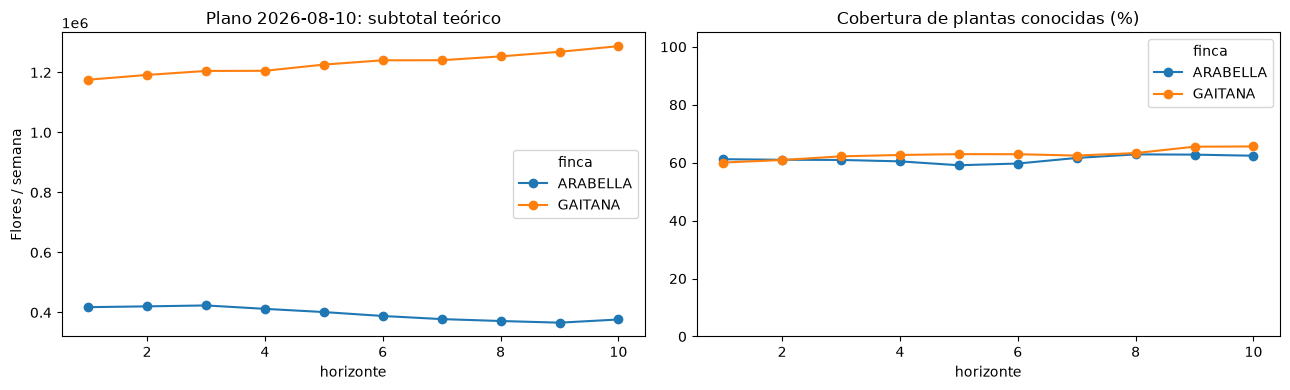

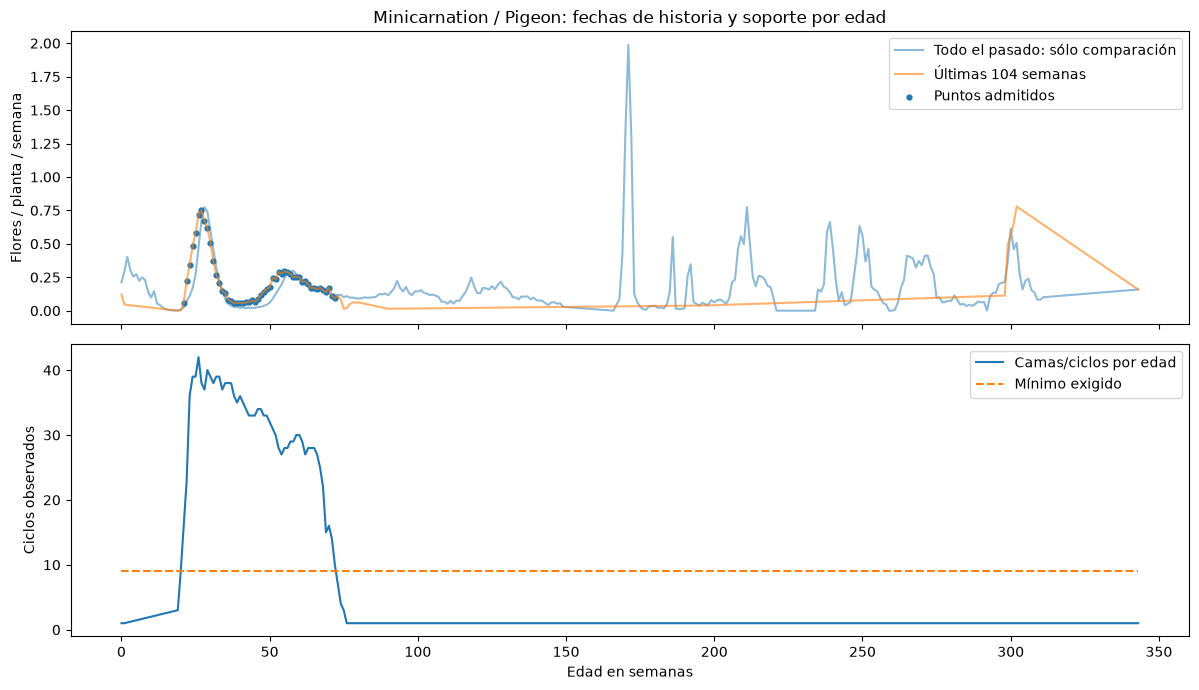

,producto,variedad,ventana_semanas,desde_inclusive,hasta_exclusive,primer_corte_utilizado,ultimo_corte_utilizado,edad_minima_admitida,edad_maxima_admitida,cobertura_elegida
4470,Barbatus,Amras,104,2024-08-12,2026-08-10,2024-08-26,2026-06-29,13.0,24.0,0.510000
4471,Carnation,Damascus,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,20.0,66.0,0.774774
4472,Carnation,Lege Pink,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,21.0,37.0,0.307412
4473,Carnation,Kino,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,20.0,65.0,0.749438
4474,Carnation,Sorriso,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,21.0,70.0,0.587312
4475,Carnation,Zurigo,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,22.0,69.0,0.734062
4476,Carnation,Spritz,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,20.0,65.0,0.764969
4477,Carnation,Zenit,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,21.0,65.0,0.764573
4478,Carnation,Polimnia,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,21.0,66.0,0.856297
4479,Carnation,Caroline Gold,104,2024-08-12,2026-08-10,2024-08-12,2026-07-13,19.0,64.0,0.765656


In [58]:
g = proyeccion_semanal.loc[proyeccion_semanal.fecha_plano.eq(ultimo_plano)]
fig,axes = plt.subplots(1,2,figsize=(13,4))
g.pivot(index='horizonte',columns='finca',values='flores_cubiertas').plot(ax=axes[0],marker='o',title=f'Plano {ultimo_plano.date()}: subtotal teórico')
g.pivot(index='horizonte',columns='finca',values='cobertura_plantas').mul(100).plot(ax=axes[1],marker='o',title='Cobertura de plantas conocidas (%)')
axes[0].set_ylabel('Flores / semana'); axes[1].set_ylim(0,105)
plt.tight_layout(); plt.show()

seleccion_ultimo = seleccion_ventanas.loc[seleccion_ventanas.hasta_exclusive.eq(ultimo_plano)]
hist_previo = estadisticas_para_curvas.loc[estadisticas_para_curvas.fecha_corte.lt(ultimo_plano) &
    estadisticas_para_curvas.IdVariedad.isin(seleccion_ultimo.IdVariedad)]
if not hist_previo.empty:
    variedad_ejemplo = hist_previo.groupby('IdVariedad').size().idxmax()
    config = seleccion_ultimo.loc[seleccion_ultimo.IdVariedad.eq(variedad_ejemplo)].iloc[0]
    h = hist_previo.loc[hist_previo.IdVariedad.eq(variedad_ejemplo)]
    completa = h.groupby('edad').agg(corte=('corte','sum'),plantas=('plantas','sum'))
    c = curvas_proyeccion.loc[curvas_proyeccion.archivo_plano.eq(config.archivo) &
        curvas_proyeccion.IdVariedad.eq(variedad_ejemplo)].sort_values('edad')
    fig,axes = plt.subplots(2,1,figsize=(12,7),sharex=True)
    axes[0].plot(completa.index,completa.corte/completa.plantas,label='Todo el pasado: sólo comparación',alpha=.5)
    axes[0].plot(c.edad,c.corte_acumulado/c.plantas_observadas,label=f'Últimas {config.ventana_semanas} semanas',alpha=.6)
    axes[0].scatter(c.loc[c.utilizable,'edad'],c.loc[c.utilizable,'flores_x_planta_curva'],label='Puntos admitidos',s=12)
    axes[0].set_title(f'{config.producto} / {config.variedad}: fechas de historia y soporte por edad')
    axes[0].set_ylabel('Flores / planta / semana'); axes[0].legend()
    axes[1].plot(c.edad,c.ciclos,label='Camas/ciclos por edad')
    axes[1].plot(c.edad,c.ciclos_minimos_exigidos,'--',label='Mínimo exigido')
    axes[1].set_xlabel('Edad en semanas'); axes[1].set_ylabel('Ciclos observados'); axes[1].legend()
    plt.tight_layout(); plt.show()

display(seleccion_ultimo[['producto','variedad','ventana_semanas','desde_inclusive','hasta_exclusive',
    'primer_corte_utilizado','ultimo_corte_utilizado','edad_minima_admitida','edad_maxima_admitida','cobertura_elegida']].head(20))

### 5.5. Comprobar el cálculo antes de interpretarlo

Las comprobaciones verifican que cada fila tenga diez horizontes, que las uniones no multipliquen filas, que ningún corte sea posterior al plano y que se respete el soporte mínimo. También verifican `flores = plantas × curva`, y que los casos sin curva permanezcan vacíos.

Si pasan, el cálculo es consistente con las reglas. **No significa todavía que la producción pronosticada sea precisa**: eso requiere compararla con cortes reales posteriores.


In [59]:
assert len(base_planos)==len(planos)
assert len(proyeccion_detalle)==len(planos)*HORIZONTE
assert not proyeccion_detalle.duplicated(['id_fila_plano','horizonte']).any()
assert proyeccion_detalle.groupby('id_fila_plano').horizonte.nunique().eq(HORIZONTE).all()
assert auditoria_curvas.ultima_observacion.lt(auditoria_curvas.hasta_exclusive).all()
assert auditoria_curvas.primera_observacion.ge(auditoria_curvas.desde_inclusive).all()
admitidas = curvas_proyeccion.loc[curvas_proyeccion.utilizable]
assert admitidas.ciclos.ge(admitidas.ciclos_minimos_exigidos).all()
assert admitidas.ultima_observacion.ge(admitidas.hasta_exclusive-pd.Timedelta(weeks=VIGENCIA_SEMANAS)).all()
calculadas = proyeccion_detalle.loc[proyeccion_detalle.estado_proyeccion.eq('proyectada')]
assert np.allclose(calculadas.flores_teoricas,calculadas.plantas*calculadas.flores_x_planta_curva)
assert proyeccion_detalle.loc[~proyeccion_detalle.estado_proyeccion.isin(['proyectada','aun_no_sembrada']),'flores_teoricas'].isna().all()
assert proyeccion_total_plano.cobertura_plantas.dropna().between(0,1+1e-9).all()
assert np.isclose(proyeccion_total_plano.flores_cubiertas.sum(),proyeccion_detalle.flores_teoricas.sum())

min_cobertura = proyeccion_total_plano.cobertura_plantas.min()*100
max_cobertura = proyeccion_total_plano.cobertura_plantas.max()*100
n_ampliadas = seleccion_ventanas.ventana_semanas.eq(VENTANA_AMPLIADA).sum()
display(Markdown(f"""**Resultado de esta ejecución:** {base_planos.archivo.nunique()} planos, 
{len(proyeccion_detalle):,} filas-horizonte y {len(proyeccion_total_plano):,} totales plano-semana. 
Se amplió la historia a {VENTANA_AMPLIADA} semanas en {n_ampliadas:,} de {len(seleccion_ventanas):,} combinaciones plano-variedad. 
La cobertura de plantas conocidas por plano-semana va de **{min_cobertura:.2f}% a {max_cobertura:.2f}%**. 
La producción restante permanece desconocida. Los controles de cardinalidad, temporalidad y multiplicación pasaron."""))

**Resultado de esta ejecución:** 33 planos, 
3,882,640 filas-horizonte y 330 totales plano-semana. 
Se amplió la historia a 156 semanas en 28 de 4,596 combinaciones plano-variedad. 
La cobertura de plantas conocidas por plano-semana va de **54.79% a 66.74%**. 
La producción restante permanece desconocida. Los controles de cardinalidad, temporalidad y multiplicación pasaron.

### 5.6. Leer el resultado: mismo DataFrame, pocas columnas en pantalla

**Empieza con `proyeccion_semanal`.** Cada fila corresponde a un plano, una semana futura y una finca. La selección de abajo sólo muestra cinco columnas; **no elimina las demás ni crea otra tabla guardada**.

- `fecha_plano`: fecha del plano con el que se hizo la previsión.
- `fecha_objetivo`: semana de producción que se está proyectando.
- `finca`: finca del plano.
- `flores_cubiertas`: subtotal de flores que sí pudo calcularse.
- `cobertura_plantas`: proporción de plantas conocidas con resultado; **0,60 significa 60%**.

Para investigar una variedad usa `proyeccion_variedad`; para una cama usa `proyeccion_detalle`. Ambas conservan toda su información. Si falta curva, el subtotal no representa toda la producción esperada: la parte faltante sigue desconocida, no se convierte en cero.

In [60]:
display(proyeccion_semanal.loc[proyeccion_semanal.fecha_plano.eq(proyeccion_semanal.fecha_plano.max()),
    ['fecha_plano','fecha_objetivo','finca','flores_cubiertas','cobertura_plantas']].round(3))

C:\Users\elian\AppData\Local\Temp\ipykernel_143884\4051296679.py:2: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ['fecha_plano','fecha_objetivo','finca','flores_cubiertas','cobertura_plantas']].round(3))


,fecha_plano,fecha_objetivo,finca,flores_cubiertas,cobertura_plantas
640,2026-08-10,2026-08-17,ARABELLA,417690.427,0.612
641,2026-08-10,2026-08-17,GAITANA,1175617.395,0.600
642,2026-08-10,2026-08-24,ARABELLA,420328.449,0.610
643,2026-08-10,2026-08-24,GAITANA,1191643.381,0.609
644,2026-08-10,2026-08-31,ARABELLA,423392.051,0.609
645,2026-08-10,2026-08-31,GAITANA,1204937.028,0.622
646,2026-08-10,2026-09-07,ARABELLA,412044.287,0.605
647,2026-08-10,2026-09-07,GAITANA,1205402.592,0.627
648,2026-08-10,2026-09-14,ARABELLA,401368.820,0.591
649,2026-08-10,2026-09-14,GAITANA,1226124.123,0.630


### 5.7. EDA: ¿cuánto cambia la proyección de un plano al siguiente?

**Se compara la misma semana de producción**, no el mismo número de horizonte. Ejemplo: la previsión para el **17 de agosto** hecha con el plano del **3 de agosto**, contra la previsión para ese mismo **17 de agosto** hecha con el plano del **10 de agosto**. Dos planos consecutivos tienen nueve semanas futuras en común.

El cambio es `100 × (flores nuevas / flores anteriores − 1)`: un −3% significa que la nueva previsión es 3% menor para esa misma fecha. Si antes había cero, el porcentaje no está definido y se cuenta aparte.

**Cómo leer el EDA:**

- La **mediana del cambio absoluto** muestra una revisión típica; el **percentil 90** indica que el 90% de las revisiones medibles tiene ese tamaño o menos.
- En el gráfico izquierdo, cada línea es un plano y el eje horizontal es la fecha de producción. Líneas cercanas en una misma fecha significan previsiones parecidas. Una subida entre semanas futuras no es, por sí sola, inestabilidad entre planos.
- En el gráfico derecho se ve cuánto se revisó la previsión frente al plano anterior.
- La tabla de mayores cambios incluye el cambio de cobertura: un salto del subtotal puede deberse a que ahora hay más o menos plantas con curva.

Se usa **20% como señal exploratoria de revisión**, sin forzar ni suavizar resultados. Se mide la estabilidad del subtotal calculable: **no prueba exactitud ni que esté cubierta toda la finca**.

Finalmente se muestran las variedades con mayores cambios en flores. Revisar plantas, cobertura, composición de edades y actualización de curvas, en ese orden. Si las plantas totales son iguales, aún puede haber distintas fechas de siembra o una curva actualizada. No se atribuye automáticamente el cambio a una sola causa. Una variedad ausente en uno de los planos no se supone de producción cero.

Los cálculos auxiliares se hacen dentro de una función y se muestran directamente; no añaden columnas a las tablas ni dejan nuevos DataFrames permanentes.

Cambio absoluto porcentual: misma semana de producción, planos separados por siete días.


,comparaciones,mediana,percentil_90,maximo
finca,,,,
ARABELLA,288,0.35,1.04,3.03
GAITANA,288,0.20,0.69,1.60


Casos con cero anterior y subtotal nuevo positivo: 0
Mayores revisiones (el plano anterior es siete días antes de fecha_plano):


C:\Users\elian\AppData\Local\Temp\ipykernel_143884\1732572901.py:19: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ['fecha_plano','fecha_objetivo','finca','cambio_pct','cambio_cobertura_pp']].round(2))


,fecha_plano,fecha_objetivo,finca,cambio_pct,cambio_cobertura_pp
36,2026-01-19,2026-01-26,ARABELLA,-3.03,-1.56
38,2026-01-19,2026-02-02,ARABELLA,-2.76,-1.46
524,2026-07-27,2026-08-10,ARABELLA,-2.10,-2.33
126,2026-02-23,2026-03-02,ARABELLA,-2.05,-1.98
468,2026-07-06,2026-07-13,ARABELLA,-1.90,-1.52
42,2026-01-19,2026-02-16,ARABELLA,-1.87,-0.71
128,2026-02-23,2026-03-09,ARABELLA,-1.81,-1.50
44,2026-01-19,2026-02-23,ARABELLA,-1.74,0.02
288,2026-04-27,2026-05-04,ARABELLA,-1.62,-0.56
1,2026-01-05,2026-01-12,GAITANA,-1.60,-1.28


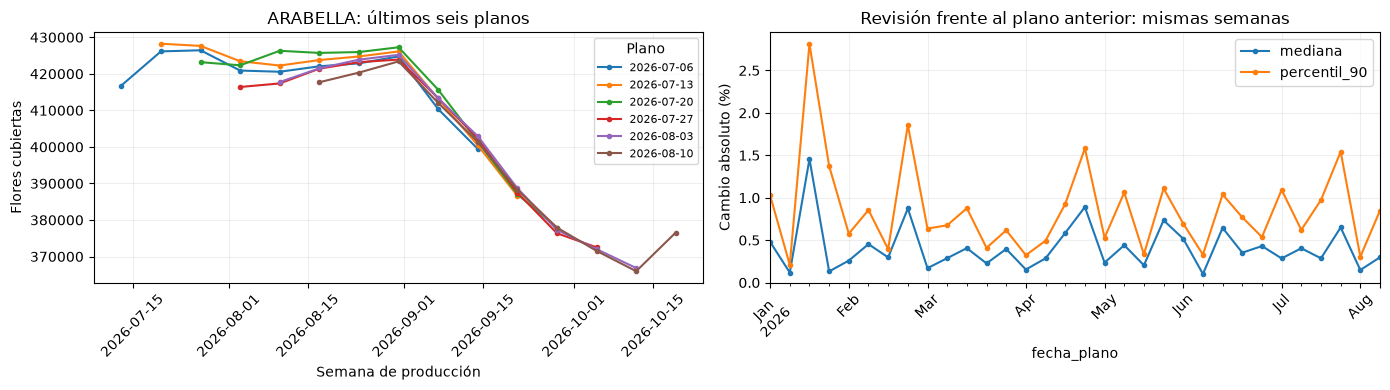

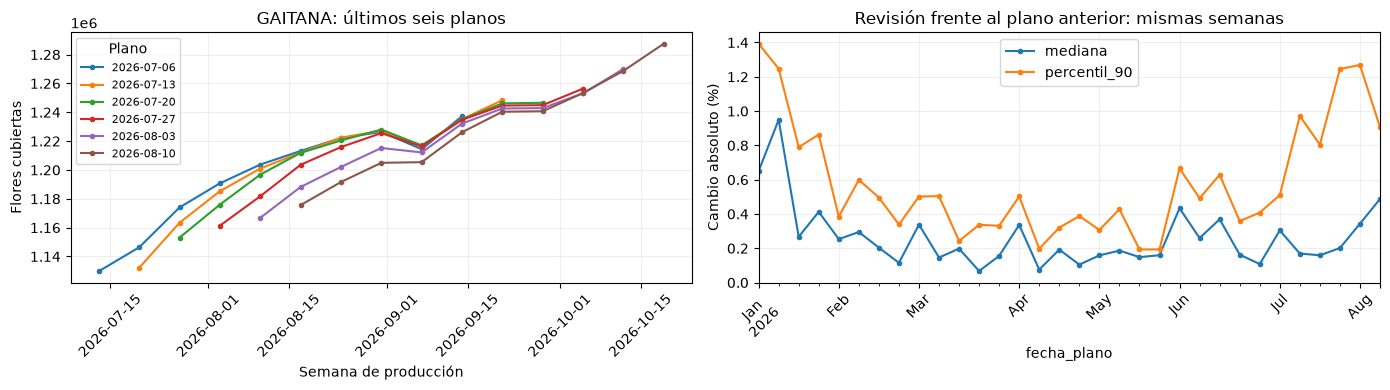

Variedades que más cambian en flores: revisar plantas, cobertura, edades y curva.


C:\Users\elian\AppData\Local\Temp\ipykernel_143884\1732572901.py:50: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  ['fecha_plano','fecha_objetivo','finca','variedad','cambio_flores','cambio_plantas','cambio_cobertura_pp']].round(2))


,fecha_plano,fecha_objetivo,finca,variedad,cambio_flores,cambio_plantas,cambio_cobertura_pp
5477,2026-01-19,2026-01-26,GAITANA,Nenufar,-9316.69,9780,-15.21
40009,2026-04-20,2026-04-27,GAITANA,Petit Faye,-7671.46,-19000,-6.38
3740,2026-01-12,2026-02-09,GAITANA,Dracula,-7459.54,0,-15.55
13875,2026-02-09,2026-03-02,ARABELLA,Jungle,7125.43,4764,11.36
6093,2026-01-19,2026-02-09,GAITANA,Dracula,6883.58,0,15.55
23343,2026-03-02,2026-04-20,GAITANA,Petit Faye,6798.93,1000,8.37
4619,2026-01-12,2026-03-02,GAITANA,Dracula,-6777.20,0,-11.49
6981,2026-01-19,2026-03-02,GAITANA,Dracula,6649.13,0,11.49
3447,2026-01-12,2026-02-02,GAITANA,Dracula,-6152.84,0,-8.17
2861,2026-01-12,2026-01-19,GAITANA,Dracula,-6105.95,0,-8.17


Filas producto/color/variedad-semana que aparecen o dejan de aparecer en semanas comparables:
Aparecen: 243 | Dejan de aparecer: 567


**Lectura de esta ejecución:** 576 comparaciones entre planos consecutivos para la misma semana de producción.

**ARABELLA:** revisión absoluta mediana **0.35%**, percentil 90 **1.04%** y máximo **3.03%**. La cobertura de plantas conocidas está entre **52.64% y 70.15%**.

**GAITANA:** revisión absoluta mediana **0.20%**, percentil 90 **0.69%** y máximo **1.60%**. La cobertura de plantas conocidas está entre **55.39% y 65.65%**.

Hay **0 revisiones superiores al 20%**. No se aplicó suavizado para acercar los planos. La estabilidad observada corresponde al subtotal con curva; la producción sin cobertura sigue desconocida.

Si los cambios son pequeños, no hace falta forzar estabilidad. Si aparece un salto, revisar cobertura, plantas, composición de edades y curvas. Para evaluar precisión hay que comparar después con corte real.


In [61]:
def mostrar_eda_proyecciones(semanal, variedades):
    # Copias locales, exclusivamente para mostrar las comparaciones.
    campos = ['fecha_plano','fecha_objetivo','finca','flores_cubiertas','cobertura_plantas']
    anterior = semanal[campos].copy()
    anterior['fecha_plano'] += pd.Timedelta(weeks=1)
    anterior = anterior.rename(columns={'flores_cubiertas':'flores_anteriores','cobertura_plantas':'cobertura_anterior'})
    cambios = semanal[campos].merge(anterior,on=campos[:3],how='inner',validate='one_to_one')
    cambios['cambio_pct'] = 100*(cambios.flores_cubiertas/cambios.flores_anteriores.where(cambios.flores_anteriores.gt(0))-1)
    cambios['cambio_cobertura_pp'] = 100*(cambios.cobertura_plantas-cambios.cobertura_anterior)
    cambios['magnitud'] = cambios.cambio_pct.abs()
    assert (cambios.fecha_objetivo-cambios.fecha_plano).dt.days.between(7,63).all()
    resumen = cambios.groupby('finca').magnitud.agg(comparaciones='count',mediana='median',
        percentil_90=lambda s:s.quantile(.9),maximo='max')
    print('Cambio absoluto porcentual: misma semana de producción, planos separados por siete días.')
    display(resumen.round(2))
    print('Casos con cero anterior y subtotal nuevo positivo:',int((cambios.flores_anteriores.eq(0)&cambios.flores_cubiertas.gt(0)).sum()))
    print('Mayores revisiones (el plano anterior es siete días antes de fecha_plano):')
    display(cambios.nlargest(12,'magnitud')[
        ['fecha_plano','fecha_objetivo','finca','cambio_pct','cambio_cobertura_pp']].round(2))

    for finca, datos in semanal.groupby('finca'):
        fig, axes = plt.subplots(1,2,figsize=(14,4))
        for fecha in sorted(datos.fecha_plano.unique())[-6:]:
            g = datos.loc[datos.fecha_plano.eq(fecha)].sort_values('fecha_objetivo')
            axes[0].plot(g.fecha_objetivo,g.flores_cubiertas,marker='.',label=str(pd.Timestamp(fecha).date()))
        axes[0].set_title(f'{finca}: últimos seis planos')
        axes[0].set_xlabel('Semana de producción'); axes[0].set_ylabel('Flores cubiertas')
        axes[0].legend(title='Plano',fontsize=8)
        g = cambios.loc[cambios.finca.eq(finca)].groupby('fecha_plano').magnitud.agg(
            mediana='median',percentil_90=lambda s:s.quantile(.9))
        g.plot(ax=axes[1],marker='.')
        axes[1].set_title('Revisión frente al plano anterior: mismas semanas')
        axes[1].set_ylabel('Cambio absoluto (%)'); axes[1].set_ylim(bottom=0)
        for ax in axes: ax.grid(alpha=.2); ax.tick_params(axis='x',rotation=45)
        plt.tight_layout(); plt.show()

    # Mantener producto y color en la llave para no mezclar grupos diferentes.
    llave = ['fecha_plano','fecha_objetivo','finca','producto','color','variedad']
    valores = ['plantas_conocidas','flores_cubiertas','cobertura_plantas']
    anterior = variedades[llave+valores].copy()
    anterior['fecha_plano'] += pd.Timedelta(weeks=1)
    cambios_variedad = variedades[llave+valores].merge(anterior,on=llave,how='inner',
        suffixes=('','_anterior'),validate='one_to_one')
    cambios_variedad['cambio_flores'] = cambios_variedad.flores_cubiertas-cambios_variedad.flores_cubiertas_anterior
    cambios_variedad['cambio_plantas'] = cambios_variedad.plantas_conocidas-cambios_variedad.plantas_conocidas_anterior
    cambios_variedad['cambio_cobertura_pp'] = 100*(cambios_variedad.cobertura_plantas-cambios_variedad.cobertura_plantas_anterior)
    cambios_variedad['magnitud'] = cambios_variedad.cambio_flores.abs()
    print('Variedades que más cambian en flores: revisar plantas, cobertura, edades y curva.')
    display(cambios_variedad.nlargest(15,'magnitud')[
        ['fecha_plano','fecha_objetivo','finca','variedad','cambio_flores','cambio_plantas','cambio_cobertura_pp']].round(2))
    presencia = variedades[llave].merge(anterior[llave],on=llave,how='outer',indicator=True,validate='one_to_one')
    presencia = presencia.merge(cambios[campos[:3]],on=campos[:3],how='inner',validate='many_to_one')
    print('Filas producto/color/variedad-semana que aparecen o dejan de aparecer en semanas comparables:')
    print('Aparecen:',int(presencia._merge.eq('left_only').sum()),'| Dejan de aparecer:',int(presencia._merge.eq('right_only').sum()))

    lectura = [f'**Lectura de esta ejecución:** {len(cambios):,} comparaciones entre planos consecutivos para la misma semana de producción.']
    for finca, fila in resumen.iterrows():
        c = 100*semanal.loc[semanal.finca.eq(finca),'cobertura_plantas']
        lectura.append(f'**{finca}:** revisión absoluta mediana **{fila.mediana:.2f}%**, percentil 90 **{fila.percentil_90:.2f}%** y máximo **{fila.maximo:.2f}%**. La cobertura de plantas conocidas está entre **{c.min():.2f}% y {c.max():.2f}%**.')
    grandes = int(cambios.magnitud.gt(20).sum())
    lectura.append(f'Hay **{grandes} revisiones superiores al 20%**. No se aplicó suavizado para acercar los planos. La estabilidad observada corresponde al subtotal con curva; la producción sin cobertura sigue desconocida.')
    lectura.append('Si los cambios son pequeños, no hace falta forzar estabilidad. Si aparece un salto, revisar cobertura, plantas, composición de edades y curvas. Para evaluar precisión hay que comparar después con corte real.')
    display(Markdown(chr(10).join([s+chr(10) for s in lectura])))

mostrar_eda_proyecciones(proyeccion_semanal,proyeccion_variedad)